In [1]:
import os, shutil

tex_bin = os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin")
if shutil.which("dvipng") is None:            # sólo si todavía no lo ve
    os.environ["PATH"] = tex_bin + os.pathsep + os.environ.get("PATH", "")

import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, sem, t, wilcoxon, pearsonr
from scipy import stats
from pathlib import Path
import nltk
from nltk.tokenize import word_tokenize
from typing import List, Tuple, Dict
from matplotlib.legend_handler import HandlerTuple
import scienceplots
plt.style.use(['science', 'grid'])

plt.rcParams.update({
    'pgf.texsystem': 'pdflatex',
    'mathtext.fontset': 'cm', #'stix',
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
    'font.family': 'serif',
    "font.serif": ["Computer Modern Roman"],
    'text.usetex': True,
    'pgf.rcfonts': False,
    'axes.formatter.use_mathtext':True,
    "grid.linewidth" : .5,
    "grid.alpha": .1
})

plt.rcParams['figure.dpi'] = 150
plt.rcParams["font.serif"] = "Times"
plt.rcParams["font.size"] = 8

BASE_PATH = "/content/drive/MyDrive/Prompting/Visual/Results/"
train_set_A_2_items_ans = ["a", "a", "b", "b", "a", "a", "b", "b", "a", "b"]
train_set_B_2_items_ans = ["a", "b", "b", "a", "b", "b", "b", "a", "a", "a"]

train_set_A_16_items_ans = ["b", "a", "b", "b", "a", "b", "a", "a", "b", "a"]
train_set_B_16_items_ans = ["b", "a", "a", "b", "a", "a", "b", "b", "a", "b"]

entropy_set_A = [0, 4, 1, 3, 2, 4, 3, 0, 1, 2]
entropy_set_B = [2, 0, 2, 3, 1, 0, 4, 4, 1, 3]

plot_save_path = "plots/"
data_path = "Data/"

exp_1_path = plot_save_path + "Exp_1/"
exp_2_path = plot_save_path + "Exp_2/"
exp_3_path = plot_save_path + "Exp_3/"
exp_4_path = plot_save_path + "Exp_4/"

In [2]:
exp_1_df = pd.read_csv(data_path+"data_exp_1_final.csv")
exp_2_df = pd.read_csv(data_path+"data_exp_2_final.csv")
exp_3_df = pd.read_csv(data_path+"data_exp_3_final.csv")
exp_4_df = pd.read_csv(data_path+"data_exp_4_final.csv")

exp_3_df.loc[987, "Relevance"] = '0'
#exp_3_df.loc[1089, "Relevance"] = 0


exp_3_df = exp_3_df.drop(exp_3_df.index[225:229].union(exp_3_df.index[249:256])).reset_index(drop=True)

In [3]:
# Function to format model names
def format_model_name(model_name):
    name = model_name.replace('_', ' ')
    name = re.sub(r'(\d) (\d)', r'\1.\2', name)
    return name

# Experiment 1

In [4]:
# Asumimos que tu dataframe se llama 'exp_1_df'
# Hacemos una copia para no alterar el original accidentalmente
df = exp_1_df.copy()

# --- LÓGICA PARA CREAR LAS INSTANCIAS ---
# Agrupamos por 'Model' y 'Set'. Esto aísla los datos de cada grupo.
# 'cumcount()' cuenta las filas: 0, 1, 2... 9, 10, 11... dentro de cada grupo.
# Al dividir por 10 (división entera //), obtenemos: 0, 0... 1, 1...
# Sumamos 1 para que las instancias empiecen en 1 y no en 0.

df['Instance_ID'] = df.groupby(['Model', 'Set']).cumcount() // 10 + 1

# VERIFICACIÓN (Opcional pero recomendada)
# Comprobamos que el modelo especial 'GPT_o4_mini' tenga sus instancias bien creadas
# y que un modelo normal también.
print("Verificación de instancias generadas:")
print(df[['Model', 'Set', 'Instance_ID']].head(130)) # Ver el inicio (Modelo normal)
print(df[df['Model'] == 'GPT_o4_mini'][['Model', 'Set', 'Instance_ID']].tail(30)) # Ver el especial

Verificación de instancias generadas:
                Model Set  Instance_ID
0    Gemini_2_5_flash   A            1
1    Gemini_2_5_flash   A            1
2    Gemini_2_5_flash   A            1
3    Gemini_2_5_flash   A            1
4    Gemini_2_5_flash   A            1
..                ...  ..          ...
125            GPT_o3   A            3
126            GPT_o3   A            3
127            GPT_o3   A            3
128            GPT_o3   A            3
129            GPT_o3   A            3

[130 rows x 3 columns]
            Model Set  Instance_ID
1370  GPT_o4_mini   B            8
1371  GPT_o4_mini   B            8
1372  GPT_o4_mini   B            8
1373  GPT_o4_mini   B            8
1374  GPT_o4_mini   B            8
1375  GPT_o4_mini   B            8
1376  GPT_o4_mini   B            8
1377  GPT_o4_mini   B            8
1378  GPT_o4_mini   B            8
1379  GPT_o4_mini   B            8
1380  GPT_o4_mini   B            9
1381  GPT_o4_mini   B            9
1382  GPT_o4_mi

               Modelo Promedio A Promedio B            IC 95% A            IC 95% B
               GPT_4o     88.00%     83.00%   [83.48% - 92.52%]   [74.05% - 91.95%]
               GPT_o3    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
          GPT_o4_mini     98.00%     95.00%  [94.98% - 100.00%]  [85.92% - 100.00%]
     GPT_o4_mini_high     97.00%     97.00%  [92.17% - 100.00%]  [93.54% - 100.00%]
     Gemini_2_0_flash     86.00%     84.00%   [73.75% - 98.25%]   [71.29% - 96.71%]
     Gemini_2_5_flash    100.00%     93.00% [100.00% - 100.00%]  [81.29% - 100.00%]
Gemini_2_5_flash_lite     90.00%     78.00%  [78.32% - 100.00%]   [67.44% - 88.56%]


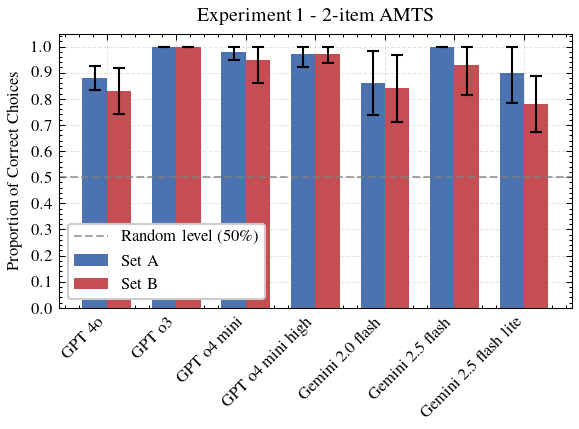

In [5]:
# ---------------------------------------------------------
# 1. PREPARACIÓN Y AGRUPACIÓN DE DATOS
# ---------------------------------------------------------
# 'df' es tu dataframe original de los experimentos 1 y 2
# Convertimos las columnas a string por seguridad al comparar

df['Result'] = (df['Answer'].astype(str) == df['Correct'].astype(str)).astype(int)

# Calculamos el promedio de aciertos por Instancia (10 notas por modelo y set)
df_agrupado = df.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()
df_agrupado.rename(columns={'Result': 'Score_Instancia'}, inplace=True)

resultados_mw = []

# Listas para guardar los datos para el gráfico
modelos = []
means_a = []
means_b = []
err_lower_a = []
err_upper_a = []
err_lower_b = []
err_upper_b = []

# Nivel de confianza para el intervalo (95%)
confidence = 0.95

# ---------------------------------------------------------
# 2. CÁLCULO ESTADÍSTICO POR MODELO
# ---------------------------------------------------------
for modelo in df_agrupado['Model'].unique():
    datos_modelo = df_agrupado[df_agrupado['Model'] == modelo]
    
    scores_a = datos_modelo[datos_modelo['Set'] == 'A']['Score_Instancia'].values
    scores_b = datos_modelo[datos_modelo['Set'] == 'B']['Score_Instancia'].values
    
    if len(scores_a) > 0 and len(scores_b) > 0:
        # Prueba de Mann-Whitney
        #stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
        
        # Promedios
        mean_a = scores_a.mean()
        mean_b = scores_b.mean()
        
        # Cálculo del Margen de Error (Intervalo de Confianza 95%)
        # Usamos la distribución t de Student porque n=10 es una muestra pequeña
        n_a, n_b = len(scores_a), len(scores_b)
        
        # Margen de error A
        std_err_a = sem(scores_a) if n_a > 1 else 0
        margin_a = std_err_a * t.ppf((1 + confidence) / 2., n_a - 1) if std_err_a > 0 else 0
        
        # Margen de error B
        std_err_b = sem(scores_b) if n_b > 1 else 0
        margin_b = std_err_b * t.ppf((1 + confidence) / 2., n_b - 1) if std_err_b > 0 else 0
        
        # Recortar (Clip) los intervalos para que no pasen de 1.0 (100%) ni bajen de 0.0 (0%)
        # Matplotlib requiere la *distancia* desde la media, no los valores absolutos
        lower_err_a = mean_a - max(0.0, mean_a - margin_a)
        upper_err_a = min(1.0, mean_a + margin_a) - mean_a
        
        lower_err_b = mean_b - max(0.0, mean_b - margin_b)
        upper_err_b = min(1.0, mean_b + margin_b) - mean_b
        
        # Guardar para el dataframe
        resultados_mw.append({
            'Modelo': modelo,
            'Promedio A': f"{mean_a:.2%}",
            'Promedio B': f"{mean_b:.2%}",
            'IC 95% A': f"[{mean_a-lower_err_a:.2%} - {mean_a+upper_err_a:.2%}]",
            'IC 95% B': f"[{mean_b-lower_err_b:.2%} - {mean_b+upper_err_b:.2%}]",
            #'Valor p (MW)': round(p_valor, 4),
            #'Significativo': 'SÍ' if p_valor < 0.05 else 'NO'
        })
        
        # Guardar para el gráfico
        modelos.append(format_model_name(modelo))
        means_a.append(mean_a)# * 100) # Convertimos a % para el gráfico
        means_b.append(mean_b)# * 100)
        err_lower_a.append(lower_err_a)# * 100)
        err_upper_a.append(upper_err_a)# * 100)
        err_lower_b.append(lower_err_b)# * 100)
        err_upper_b.append(upper_err_b)# * 100)

# Mostrar la tabla final
df_final = pd.DataFrame(resultados_mw)
print(df_final.to_string(index=False))


# ---------------------------------------------------------
# 3. GENERACIÓN DEL GRÁFICO DE BARRAS AGRUPADAS
# ---------------------------------------------------------
# Configuración del estilo general
plt.figure(figsize=(4, 3))
x = np.arange(len(modelos))  # Posiciones en el eje X
width = 0.35  # Ancho de las barras

# Crear los arrays de error asimétrico para matplotlib (forma: [errores_inferiores, errores_superiores])
yerr_a = [err_lower_a, err_upper_a]
yerr_b = [err_lower_b, err_upper_b]

# Dibujar las barras
bars1 = plt.bar(x - width/2, means_a, width, label='Set A', color='#4C72B0', 
                yerr=yerr_a, capsize=3)#, error_kw={'elinewidth':1.5, 'capthick':1.5})
bars2 = plt.bar(x + width/2, means_b, width, label='Set B', color='#C44E52', 
                yerr=yerr_b, capsize=3)#, error_kw={'elinewidth':1.5, 'capthick':1.5})

# Personalización del gráfico
plt.ylabel('Proportion of Correct Choices')#, fontsize=12)
plt.title('Experiment 1 - 2-item AMTS')#, fontsize=14, pad=15)
plt.xticks(x, modelos, rotation=45, ha='right') #fontsize=11)
plt.ylim(0, 1.05) # Límite en 105 para que la barra de error del 100% se vea bien
plt.yticks(np.arange(0, 1.01, .1))

# Línea horizontal tenue en el 50% (nivel de azar)
plt.axhline(y=.5, color='gray', linestyle='--', alpha=0.7, label=R'Random level (50\%)')

plt.legend()#loc='upper right')#, fontsize=11)
plt.tight_layout() # Ajusta los márgenes para que no se corten los nombres largos


# Guardar la imagen (ideal para el paper)
#plt.savefig('proportions_exp_1.pdf', dpi=300, bbox_inches='tight')
#print("\nGráfico guardado como 'grafico_desempeno_modelos.png'")

Boxplot guardado exitosamente como 'boxplot_precision_modelos.png'


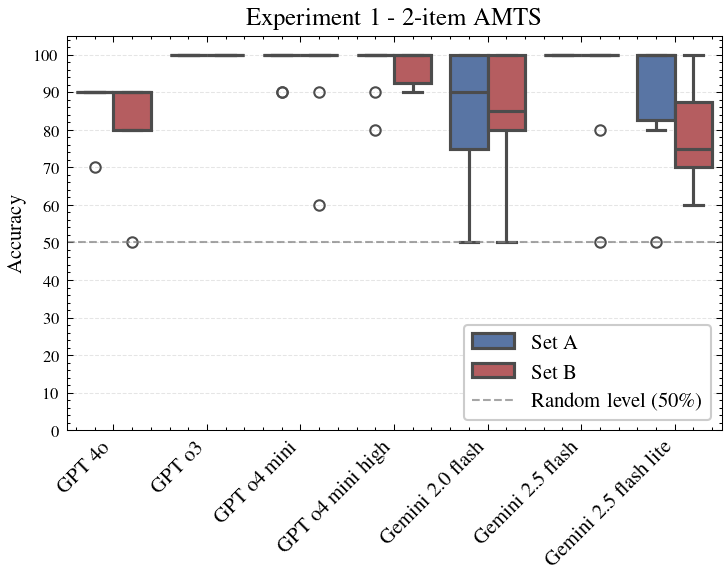

In [6]:
import seaborn as sns

# 1. Preparar los datos: Calcular si la respuesta fue correcta
# Convertimos a string por seguridad (para evitar problemas entre 'a' y 'A' o espacios)
df['Result'] = (df['Answer'].astype(str).str.strip().str.lower() == 
                df['Correct'].astype(str).str.strip().str.lower()).astype(int)

# 2. Calcular la precisión por cada instancia
# Agrupamos por Modelo, Set y la Instancia que creaste para sacar el promedio (0.0 a 1.0)
df_scores = df.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()

# Multiplicamos por 100 para que el gráfico muestre porcentajes legibles (0 a 100)
df_scores['Accuracy'] = df_scores['Result'] * 100

df_scores['Model'] = df_scores['Model'].apply(format_model_name)

# 2. Renombrar las categorías del Set para que la leyenda se genere sola correctamente
df_scores['Set'] = df_scores['Set'].replace({'A': 'Set A', 'B': 'Set B'})

# 3. Configurar la figura y el estilo
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid") # Fondo blanco con líneas guía tenues, ideal para papers

# 4. Crear el Boxplot
# x: Modelos, y: Precisión, hue: Set (para poner la caja de Set A junto a la de Set B)
ax = sns.boxplot(
    data=df_scores,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=['#4C72B0', '#C44E52'], # Azul y Rojo académico (mismos colores del barplot anterior)
    linewidth=1.5,
    fliersize=5 # Tamaño de los puntos atípicos (outliers)
)

# 5. Personalización del gráfico
#plt.title('Distribución de Precisión por Modelo e Instancia (Set A vs. Set B)', fontsize=16, pad=20, fontweight='bold')
#plt.xlabel('Modelo', fontsize=13, labelpad=10)
#plt.ylabel('Precisión por Instancia (%)', fontsize=13, labelpad=10)

# Limitar el eje Y estrictamente de 0 a 100 (con un pequeño margen visual)
plt.ylim(0, 105)
plt.yticks(range(0, 101, 10))

# Rotar nombres de modelos si son muy largos
plt.xticks(rotation=45, ha='right', fontsize=10)#, fontsize=11)

# Línea de referencia del nivel de azar (50%)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label=r'Random level (50\%)')

# Ajustar la leyenda
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', loc='lower right', fontsize=10)

plt.xlabel("")
plt.ylabel("Accuracy", fontsize=10)
plt.title('Experiment 1 - 2-item AMTS', fontsize=12)
plt.tight_layout()

# Guardar la imagen
#plt.savefig('boxplot_exp_1.pdf', dpi=300, bbox_inches='tight')
print("Boxplot guardado exitosamente como 'boxplot_precision_modelos.png'")

Barplot successfully saved as 'barplot_precision_modelos.png'


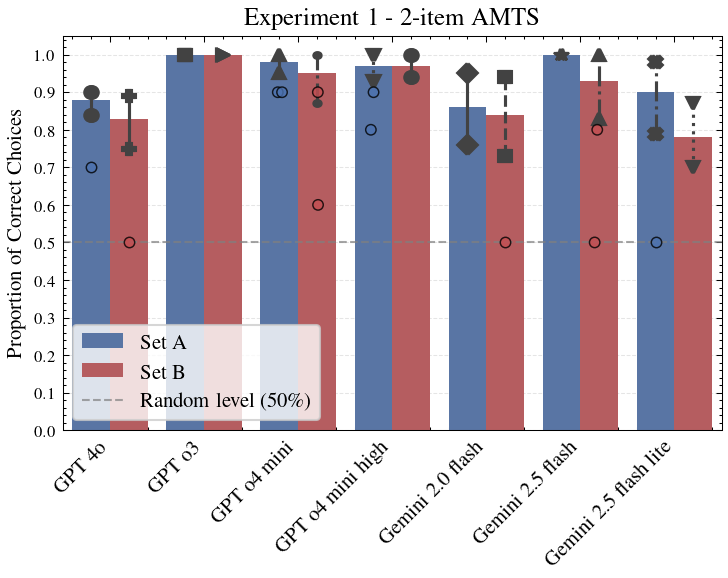

In [7]:
# 1. Prepare data: Calculate if the answer was correct
# Convert to string for safety (avoiding issues between 'a' and 'A' or spaces)
df['Result'] = (df['Answer'].astype(str).str.strip().str.lower() == 
                df['Correct'].astype(str).str.strip().str.lower()).astype(int)

# 2. Calculate accuracy per instance
# Group by Model, Set, and Instance_ID to get the mean (0.0 to 1.0)
df_scores = df.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()

# Multiply by 100 so the plot shows readable percentages (0 to 100)
df_scores['Accuracy'] = df_scores['Result'] #* 100

df_scores['Model'] = df_scores['Model'].apply(format_model_name)

# Rename Set categories so the legend generates correctly
df_scores['Set'] = df_scores['Set'].replace({'A': 'Set A', 'B': 'Set B'})

# --- CALCULATE OUTLIERS EXPLICITLY ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

# Flag the outliers grouping by Model and Set
df_scores['Is_Outlier'] = df_scores.groupby(['Model', 'Set'])['Accuracy'].transform(check_outliers)

# Create a separate dataframe containing ONLY the outliers
df_outliers = df_scores[df_scores['Is_Outlier']].copy()
# -------------------------------------

# --- STRICT ORDERING DEFINITIONS ---
# Extract the exact list of models and sets to force Seaborn to keep the layout consistent
model_order = df_scores['Model'].unique().tolist()
set_order = ['Set A', 'Set B']
# -----------------------------------

# 3. Configure figure and style
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid") # White background with faint gridlines, ideal for papers

palette = ['#4C72B0', '#C44E52'] # Academic Blue and Red

# 4. Create the Barplot
# x: Models, y: Accuracy, hue: Set
ax = sns.barplot(
    data=df_scores,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=palette,
    
    # *** CRITICAL FIX FOR COLOR/POSITION ALIGNMENT ***
    order=model_order,
    hue_order=set_order,
    # *************************************************
    
    errorbar=('ci', 95),    # Standard Error
    capsize=0.05,     # Horizontal caps on the error bars
    err_kws={'linewidth': 1.5},
    #alpha=0.9
)

# Overlay ONLY the colored outliers
sns.stripplot(
    data=df_outliers,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=palette,
    
    # *** FORCING ALIGNMENT WITH BARPLOT ***
    order=model_order,
    hue_order=set_order,
    # **************************************
    
    dodge=True,       
    jitter=True, 
    size=5, 
    linewidth=0.7,    
    edgecolor='black',
    alpha=0.8,
    ax=ax
)

# 5. Chart customization
# Limit Y axis strictly from 0 to 100 (with a small visual margin)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, .1))

# Rotate X labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Random level reference line (50%)
plt.axhline(y=.5, color='gray', linestyle='--', alpha=0.7, label=r'Random level (50\%)')

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
# The barplot adds 2 handles, the stripplot adds 2, and axhline adds 1 (Total: 5)
# We only want the first 2 (bars) and the last 1 (horizontal line)
final_handles = handles[:2] + [handles[-1]]
final_labels = labels[:2] + [labels[-1]]
plt.legend(handles=final_handles, labels=final_labels, title='', loc='lower left', fontsize=10, framealpha=.8)

plt.xlabel("")
plt.ylabel("Proportion of Correct Choices", fontsize=10)
plt.title('Experiment 1 - 2-item AMTS', fontsize=12)
plt.tight_layout()

# Save image
#plt.savefig('props_exp_1.pdf', dpi=300, bbox_inches='tight')
print("Barplot successfully saved as 'barplot_precision_modelos.png'")

In [8]:
df_exp1 = df.copy()

In [15]:
#df = exp_1_df.copy()

# 1. Preparación de variables (Igual que antes)
df['is_correct'] = (df['Answer'].astype(str) == df['Correct'].astype(str)).astype(int)
df['Cluster_ID'] = df['Model'] + "_" + df['Set'] + "_" + df['Instance_ID'].astype(str)
df['Set_Binario'] = df['Set'].apply(lambda x: 1 if x == 'B' else 0)

resultados_finales = []

print("Calculando estadística robusta por modelo...")

for modelo in df['Model'].unique():
    data_modelo = df[df['Model'] == modelo].copy()
    
    # Verificamos si hay varianza CERO en alguno de los dos sets
    # (Ej: Set A tiene todo 100% bueno)
    var_por_set = data_modelo.groupby('Set')['is_correct'].var()
    tiene_varianza_cero = (var_por_set == 0).any()
    
    # --- CAMINO A: SI HAY DATOS PERFECTOS (Usar Mann-Whitney) ---
    if tiene_varianza_cero:
        # Agrupamos por instancia para obtener las 10 notas por set
        instancias = data_modelo.groupby(['Set', 'Instance_ID'])['is_correct'].mean().reset_index()
        scores_a = instancias[instancias['Set'] == 'A']['is_correct'].values
        scores_b = instancias[instancias['Set'] == 'B']['is_correct'].values
        
        # Prueba U de Mann-Whitney (No paramétrica, ideal para este caso)
        # Nota: Si todos son idénticos (100% vs 100%), p-value será 1.0
        try:
            stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
        except ValueError:
            p_valor = 1.0 # Caso donde A y B son idénticos perfectos
            
        resultados_finales.append({
            'Modelo': modelo,
            'Metodo': 'Mann-Whitney (Por Instancia)',
            'P-Value': round(p_valor, 4),
            'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
            'Comentario': 'Usado por separación perfecta en datos'
        })

    # --- CAMINO B: SI HAY VARIANZA NORMAL (Usar GEE) ---
    else:
        try:
            gee_model = smf.gee("is_correct ~ Set_Binario", 
                                data=data_modelo, 
                                groups=data_modelo["Cluster_ID"],
                                family=sm.families.Binomial()).fit()
            
            p_valor = gee_model.pvalues['Set_Binario']
            
            resultados_finales.append({
                'Modelo': modelo,
                'Metodo': 'GEE (Modelo Mixto)',
                'P-Value': round(p_valor, 4),
                'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
                'Comentario': 'Análisis estándar'
            })
        except:
            # Fallback a Mann-Whitney si GEE falla por otra razón técnica
            instancias = data_modelo.groupby(['Set', 'Instance_ID'])['is_correct'].mean().reset_index()
            scores_a = instancias[instancias['Set'] == 'A']['is_correct'].values
            scores_b = instancias[instancias['Set'] == 'B']['is_correct'].values
            stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
            
            resultados_finales.append({
                'Modelo': modelo,
                'Metodo': 'Mann-Whitney (Fallback)',
                'P-Value': round(p_valor, 4),
                'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
                'Comentario': 'GEE falló convergencia'
            })

# Mostrar tabla final
df_final = pd.DataFrame(resultados_finales)
print(df_final[['Modelo', 'Metodo', 'P-Value', 'Significativo', 'Comentario']].to_string(index=False))

Calculando estadística robusta por modelo...
               Modelo                       Metodo  P-Value Significativo                             Comentario
     Gemini_2_5_flash Mann-Whitney (Por Instancia)   0.1681            NO Usado por separación perfecta en datos
               GPT_o3 Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
               GPT_4o           GEE (Modelo Mixto)   0.2052            NO                      Análisis estándar
Gemini_2_5_flash_lite           GEE (Modelo Mixto)   0.1220            NO                      Análisis estándar
     GPT_o4_mini_high           GEE (Modelo Mixto)   1.0000            NO                      Análisis estándar
     Gemini_2_0_flash           GEE (Modelo Mixto)   0.7875            NO                      Análisis estándar
          GPT_o4_mini           GEE (Modelo Mixto)   0.3573            NO                      Análisis estándar


# Experiment 2

In [9]:
# Asumimos que tu dataframe se llama 'exp_1_df'
# Hacemos una copia para no alterar el original accidentalmente
df = exp_2_df.copy()

# --- LÓGICA PARA CREAR LAS INSTANCIAS ---
# Agrupamos por 'Model' y 'Set'. Esto aísla los datos de cada grupo.
# 'cumcount()' cuenta las filas: 0, 1, 2... 9, 10, 11... dentro de cada grupo.
# Al dividir por 10 (división entera //), obtenemos: 0, 0... 1, 1...
# Sumamos 1 para que las instancias empiecen en 1 y no en 0.

df['Instance_ID'] = df.groupby(['Model', 'Set']).cumcount() // 10 + 1

# VERIFICACIÓN (Opcional pero recomendada)
# Comprobamos que el modelo especial 'GPT_o4_mini' tenga sus instancias bien creadas
# y que un modelo normal también.
print("Verificación de instancias generadas:")
print(df[['Model', 'Set', 'Instance_ID']].head(130)) # Ver el inicio (Modelo normal)
print(df[df['Model'] == 'GPT_o4_mini'][['Model', 'Set', 'Instance_ID']].tail(30)) # Ver el especial


Verificación de instancias generadas:
      Model Set  Instance_ID
0    GPT_4o   A            1
1    GPT_4o   A            1
2    GPT_4o   A            1
3    GPT_4o   A            1
4    GPT_4o   A            1
..      ...  ..          ...
125  GPT_o3   A            3
126  GPT_o3   A            3
127  GPT_o3   A            3
128  GPT_o3   A            3
129  GPT_o3   A            3

[130 rows x 3 columns]
            Model Set  Instance_ID
1370  GPT_o4_mini   B            8
1371  GPT_o4_mini   B            8
1372  GPT_o4_mini   B            8
1373  GPT_o4_mini   B            8
1374  GPT_o4_mini   B            8
1375  GPT_o4_mini   B            8
1376  GPT_o4_mini   B            8
1377  GPT_o4_mini   B            8
1378  GPT_o4_mini   B            8
1379  GPT_o4_mini   B            8
1380  GPT_o4_mini   B            9
1381  GPT_o4_mini   B            9
1382  GPT_o4_mini   B            9
1383  GPT_o4_mini   B            9
1384  GPT_o4_mini   B            9
1385  GPT_o4_mini   B         

               Modelo Promedio A Promedio B            IC 95% A            IC 95% B
               GPT_4o    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
               GPT_o3    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
          GPT_o4_mini     99.00%    100.00%  [96.74% - 100.00%] [100.00% - 100.00%]
     GPT_o4_mini_high    100.00%     99.00% [100.00% - 100.00%]  [96.74% - 100.00%]
     Gemini_2_0_flash    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
     Gemini_2_5_flash    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
Gemini_2_5_flash_lite     62.00%     16.00%   [48.18% - 75.82%]    [4.22% - 27.78%]


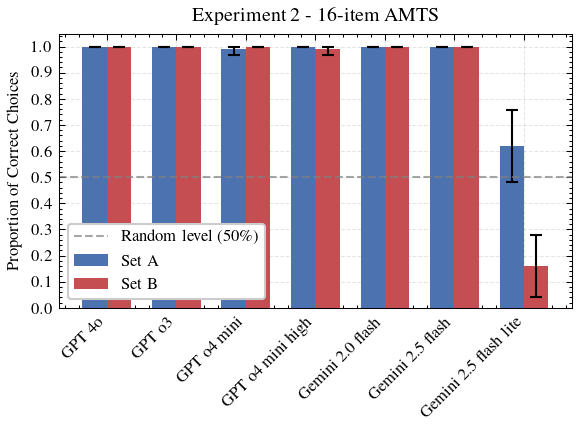

In [10]:
# Function to format model names
def format_model_name(model_name):
    name = model_name.replace('_', ' ')
    name = re.sub(r'(\d) (\d)', r'\1.\2', name)
    return name

# ---------------------------------------------------------
# 1. PREPARACIÓN Y AGRUPACIÓN DE DATOS
# ---------------------------------------------------------
# 'df' es tu dataframe original de los experimentos 1 y 2
# Convertimos las columnas a string por seguridad al comparar

df['Result'] = (df['Answer'].astype(str) == df['Correct'].astype(str)).astype(int)

# Calculamos el promedio de aciertos por Instancia (10 notas por modelo y set)
df_agrupado = df.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()
df_agrupado.rename(columns={'Result': 'Score_Instancia'}, inplace=True)

resultados_mw = []

# Listas para guardar los datos para el gráfico
modelos = []
means_a = []
means_b = []
err_lower_a = []
err_upper_a = []
err_lower_b = []
err_upper_b = []

# Nivel de confianza para el intervalo (95%)
confidence = 0.95

# ---------------------------------------------------------
# 2. CÁLCULO ESTADÍSTICO POR MODELO
# ---------------------------------------------------------
for modelo in df_agrupado['Model'].unique():
    datos_modelo = df_agrupado[df_agrupado['Model'] == modelo]
    
    scores_a = datos_modelo[datos_modelo['Set'] == 'A']['Score_Instancia'].values
    scores_b = datos_modelo[datos_modelo['Set'] == 'B']['Score_Instancia'].values
    
    if len(scores_a) > 0 and len(scores_b) > 0:
        # Prueba de Mann-Whitney
        #stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
        
        # Promedios
        mean_a = scores_a.mean()
        mean_b = scores_b.mean()
        
        # Cálculo del Margen de Error (Intervalo de Confianza 95%)
        # Usamos la distribución t de Student porque n=10 es una muestra pequeña
        n_a, n_b = len(scores_a), len(scores_b)
        
        # Margen de error A
        std_err_a = sem(scores_a) if n_a > 1 else 0
        margin_a = std_err_a * t.ppf((1 + confidence) / 2., n_a - 1) if std_err_a > 0 else 0
        
        # Margen de error B
        std_err_b = sem(scores_b) if n_b > 1 else 0
        margin_b = std_err_b * t.ppf((1 + confidence) / 2., n_b - 1) if std_err_b > 0 else 0
        
        # Recortar (Clip) los intervalos para que no pasen de 1.0 (100%) ni bajen de 0.0 (0%)
        # Matplotlib requiere la *distancia* desde la media, no los valores absolutos
        lower_err_a = mean_a - max(0.0, mean_a - margin_a)
        upper_err_a = min(1.0, mean_a + margin_a) - mean_a
        
        lower_err_b = mean_b - max(0.0, mean_b - margin_b)
        upper_err_b = min(1.0, mean_b + margin_b) - mean_b
        
        # Guardar para el dataframe
        resultados_mw.append({
            'Modelo': modelo,
            'Promedio A': f"{mean_a:.2%}",
            'Promedio B': f"{mean_b:.2%}",
            'IC 95% A': f"[{mean_a-lower_err_a:.2%} - {mean_a+upper_err_a:.2%}]",
            'IC 95% B': f"[{mean_b-lower_err_b:.2%} - {mean_b+upper_err_b:.2%}]",
            #'Valor p (MW)': round(p_valor, 4),
            #'Significativo': 'SÍ' if p_valor < 0.05 else 'NO'
        })
        
        # Guardar para el gráfico
        modelos.append(format_model_name(modelo))
        means_a.append(mean_a)# * 100) # Convertimos a % para el gráfico
        means_b.append(mean_b)# * 100)
        err_lower_a.append(lower_err_a)# * 100)
        err_upper_a.append(upper_err_a)# * 100)
        err_lower_b.append(lower_err_b)# * 100)
        err_upper_b.append(upper_err_b)# * 100)

# Mostrar la tabla final
df_final = pd.DataFrame(resultados_mw)
print(df_final.to_string(index=False))


# ---------------------------------------------------------
# 3. GENERACIÓN DEL GRÁFICO DE BARRAS AGRUPADAS
# ---------------------------------------------------------
# Configuración del estilo general
plt.figure(figsize=(4, 3))
x = np.arange(len(modelos))  # Posiciones en el eje X
width = 0.35  # Ancho de las barras

# Crear los arrays de error asimétrico para matplotlib (forma: [errores_inferiores, errores_superiores])
yerr_a = [err_lower_a, err_upper_a]
yerr_b = [err_lower_b, err_upper_b]

# Dibujar las barras
bars1 = plt.bar(x - width/2, means_a, width, label='Set A', color='#4C72B0', 
                yerr=yerr_a, capsize=3)#, error_kw={'elinewidth':1.5, 'capthick':1.5})
bars2 = plt.bar(x + width/2, means_b, width, label='Set B', color='#C44E52', 
                yerr=yerr_b, capsize=3)#, error_kw={'elinewidth':1.5, 'capthick':1.5})

# Personalización del gráfico
plt.ylabel('Proportion of Correct Choices')#, fontsize=12)
plt.title('Experiment 2 - 16-item AMTS')#, fontsize=14, pad=15)
plt.xticks(x, modelos, rotation=45, ha='right') #fontsize=11)
plt.ylim(0, 1.05) # Límite en 105 para que la barra de error del 100% se vea bien
plt.yticks(np.arange(0, 1.01, .1))

# Línea horizontal tenue en el 50% (nivel de azar)
plt.axhline(y=.5, color='gray', linestyle='--', alpha=0.7, label=R'Random level (50\%)')

plt.legend()#loc='upper right')#, fontsize=11)
plt.tight_layout() # Ajusta los márgenes para que no se corten los nombres largos


# Guardar la imagen (ideal para el paper)
#plt.savefig('proportions_exp_2.pdf', dpi=300, bbox_inches='tight')
#print("\nGráfico guardado como 'grafico_desempeno_modelos.png'")

Boxplot guardado exitosamente como 'boxplot_precision_modelos.png'


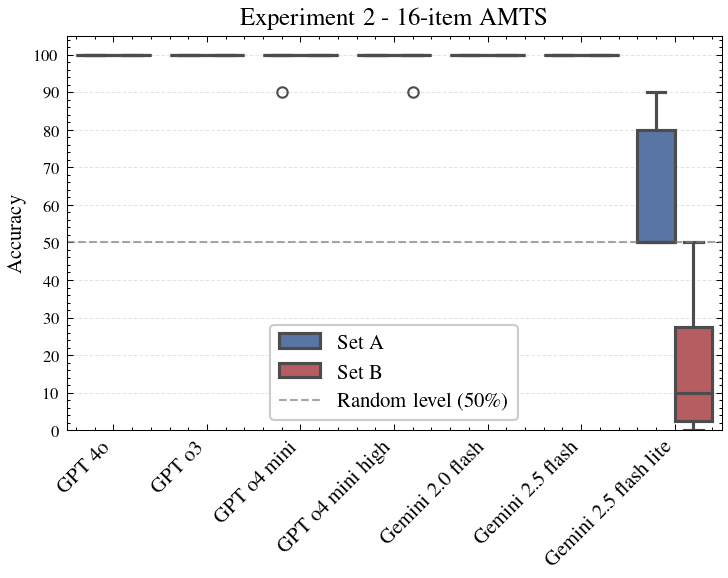

In [11]:
import seaborn as sns

# 1. Preparar los datos: Calcular si la respuesta fue correcta
# Convertimos a string por seguridad (para evitar problemas entre 'a' y 'A' o espacios)
df['Result'] = (df['Answer'].astype(str).str.strip().str.lower() == 
                df['Correct'].astype(str).str.strip().str.lower()).astype(int)

# 2. Calcular la precisión por cada instancia
# Agrupamos por Modelo, Set y la Instancia que creaste para sacar el promedio (0.0 a 1.0)
df_scores = df.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()

# Multiplicamos por 100 para que el gráfico muestre porcentajes legibles (0 a 100)
df_scores['Accuracy'] = df_scores['Result'] * 100

df_scores['Model'] = df_scores['Model'].apply(format_model_name)

# 2. Renombrar las categorías del Set para que la leyenda se genere sola correctamente
df_scores['Set'] = df_scores['Set'].replace({'A': 'Set A', 'B': 'Set B'})

# 3. Configurar la figura y el estilo
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid") # Fondo blanco con líneas guía tenues, ideal para papers

# 4. Crear el Boxplot
# x: Modelos, y: Precisión, hue: Set (para poner la caja de Set A junto a la de Set B)
ax = sns.boxplot(
    data=df_scores,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=['#4C72B0', '#C44E52'], # Azul y Rojo académico (mismos colores del barplot anterior)
    linewidth=1.5,
    fliersize=5 # Tamaño de los puntos atípicos (outliers)
)

# 5. Personalización del gráfico
#plt.title('Distribución de Precisión por Modelo e Instancia (Set A vs. Set B)', fontsize=16, pad=20, fontweight='bold')
#plt.xlabel('Modelo', fontsize=13, labelpad=10)
#plt.ylabel('Precisión por Instancia (%)', fontsize=13, labelpad=10)

# Limitar el eje Y estrictamente de 0 a 100 (con un pequeño margen visual)
plt.ylim(0, 105)
plt.yticks(range(0, 101, 10))

# Rotar nombres de modelos si son muy largos
plt.xticks(rotation=45, ha='right', fontsize=10)

# Línea de referencia del nivel de azar (50%)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label=r'Random level (50\%)')

# Ajustar la leyenda
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', loc='lower center', fontsize=10)
plt.title('Experiment 2 - 16-item AMTS', fontsize=12)
plt.xlabel("")
plt.ylabel("Accuracy", fontsize=10)
plt.tight_layout()

# Guardar la imagen
#plt.savefig('boxplot_exp_2.pdf', dpi=300, bbox_inches='tight')
print("Boxplot guardado exitosamente como 'boxplot_precision_modelos.png'")

Barplot successfully saved as 'barplot_precision_modelos.png'


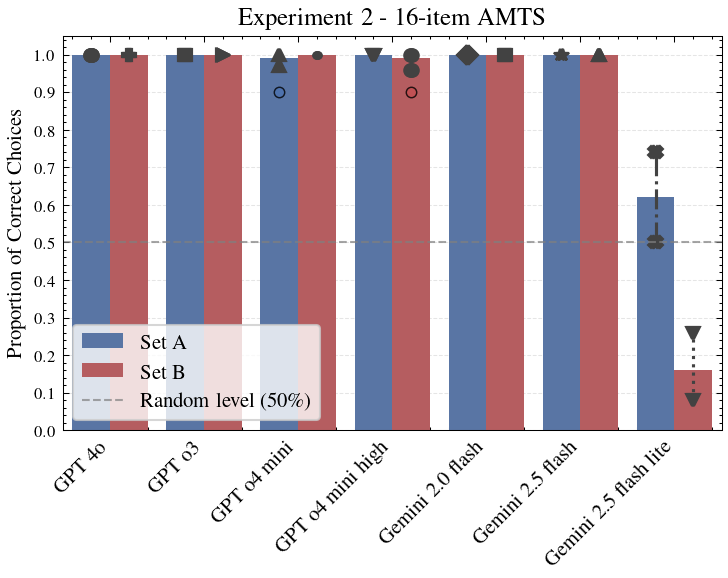

In [12]:
# 1. Prepare data: Calculate if the answer was correct
# Convert to string for safety (avoiding issues between 'a' and 'A' or spaces)
df['Result'] = (df['Answer'].astype(str).str.strip().str.lower() == 
                df['Correct'].astype(str).str.strip().str.lower()).astype(int)

# 2. Calculate accuracy per instance
# Group by Model, Set, and Instance_ID to get the mean (0.0 to 1.0)
df_scores = df.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()

# Multiply by 100 so the plot shows readable percentages (0 to 100)
df_scores['Accuracy'] = df_scores['Result'] #* 100

df_scores['Model'] = df_scores['Model'].apply(format_model_name)

# Rename Set categories so the legend generates correctly
df_scores['Set'] = df_scores['Set'].replace({'A': 'Set A', 'B': 'Set B'})

# --- CALCULATE OUTLIERS EXPLICITLY ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

# Flag the outliers grouping by Model and Set
df_scores['Is_Outlier'] = df_scores.groupby(['Model', 'Set'])['Accuracy'].transform(check_outliers)

# Create a separate dataframe containing ONLY the outliers
df_outliers = df_scores[df_scores['Is_Outlier']].copy()
# -------------------------------------

# --- STRICT ORDERING DEFINITIONS ---
# Extract the exact list of models and sets to force Seaborn to keep the layout consistent
model_order = df_scores['Model'].unique().tolist()
set_order = ['Set A', 'Set B']
# -----------------------------------

# 3. Configure figure and style
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid") # White background with faint gridlines, ideal for papers

palette = ['#4C72B0', '#C44E52'] # Academic Blue and Red

# 4. Create the Barplot
# x: Models, y: Accuracy, hue: Set
ax = sns.barplot(
    data=df_scores,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=palette,
    
    # *** CRITICAL FIX FOR COLOR/POSITION ALIGNMENT ***
    order=model_order,
    hue_order=set_order,
    # *************************************************
    
    errorbar=('ci', 95),    # Standard Error
    capsize=0.05,     # Horizontal caps on the error bars
    err_kws={'linewidth': 1.5},
    #alpha=0.9
)

# Overlay ONLY the colored outliers
sns.stripplot(
    data=df_outliers,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=palette,
    
    # *** FORCING ALIGNMENT WITH BARPLOT ***
    order=model_order,
    hue_order=set_order,
    # **************************************
    
    dodge=True,       
    jitter=True, 
    size=5, 
    linewidth=0.7,    
    edgecolor='black',
    alpha=0.8,
    ax=ax
)

# 5. Chart customization
# Limit Y axis strictly from 0 to 100 (with a small visual margin)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, .1))

# Rotate X labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Random level reference line (50%)
plt.axhline(y=.5, color='gray', linestyle='--', alpha=0.7, label=r'Random level (50\%)')

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
# The barplot adds 2 handles, the stripplot adds 2, and axhline adds 1 (Total: 5)
# We only want the first 2 (bars) and the last 1 (horizontal line)
final_handles = handles[:2] + [handles[-1]]
final_labels = labels[:2] + [labels[-1]]
plt.legend(handles=final_handles, labels=final_labels, title='', loc='lower left', fontsize=10, framealpha=.8)

plt.xlabel("")
plt.ylabel("Proportion of Correct Choices", fontsize=10)
plt.title('Experiment 2 - 16-item AMTS', fontsize=12)
plt.tight_layout()

# Save image
#plt.savefig('props_exp_2.pdf', dpi=300, bbox_inches='tight')
print("Barplot successfully saved as 'barplot_precision_modelos.png'")

In [13]:
df_exp2 = df.copy()

In [20]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import mannwhitneyu


# 1. Preparación de variables (Igual que antes)
df['is_correct'] = (df['Answer'].astype(str) == df['Correct'].astype(str)).astype(int)
df['Cluster_ID'] = df['Model'] + "_" + df['Set'] + "_" + df['Instance_ID'].astype(str)
df['Set_Binario'] = df['Set'].apply(lambda x: 1 if x == 'B' else 0)

resultados_finales = []

print("Calculando estadística robusta por modelo...")

for modelo in df['Model'].unique():
    data_modelo = df[df['Model'] == modelo].copy()
    
    # Verificamos si hay varianza CERO en alguno de los dos sets
    # (Ej: Set A tiene todo 100% bueno)
    var_por_set = data_modelo.groupby('Set')['is_correct'].var()
    tiene_varianza_cero = (var_por_set == 0).any()
    
    # --- CAMINO A: SI HAY DATOS PERFECTOS (Usar Mann-Whitney) ---
    if tiene_varianza_cero:
        # Agrupamos por instancia para obtener las 10 notas por set
        instancias = data_modelo.groupby(['Set', 'Instance_ID'])['is_correct'].mean().reset_index()
        scores_a = instancias[instancias['Set'] == 'A']['is_correct'].values
        scores_b = instancias[instancias['Set'] == 'B']['is_correct'].values
        
        # Prueba U de Mann-Whitney (No paramétrica, ideal para este caso)
        # Nota: Si todos son idénticos (100% vs 100%), p-value será 1.0
        try:
            stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
        except ValueError:
            p_valor = 1.0 # Caso donde A y B son idénticos perfectos
            
        resultados_finales.append({
            'Modelo': modelo,
            'Metodo': 'Mann-Whitney (Por Instancia)',
            'P-Value': round(p_valor, 4),
            'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
            'Comentario': 'Usado por separación perfecta en datos'
        })

    # --- CAMINO B: SI HAY VARIANZA NORMAL (Usar GEE) ---
    else:
        try:
            gee_model = smf.gee("is_correct ~ Set_Binario", 
                                data=data_modelo, 
                                groups=data_modelo["Cluster_ID"],
                                family=sm.families.Binomial()).fit()
            
            p_valor = gee_model.pvalues['Set_Binario']
            
            resultados_finales.append({
                'Modelo': modelo,
                'Metodo': 'GEE (Modelo Mixto)',
                'P-Value': round(p_valor, 4),
                'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
                'Comentario': 'Análisis estándar'
            })
        except:
            # Fallback a Mann-Whitney si GEE falla por otra razón técnica
            instancias = data_modelo.groupby(['Set', 'Instance_ID'])['is_correct'].mean().reset_index()
            scores_a = instancias[instancias['Set'] == 'A']['is_correct'].values
            scores_b = instancias[instancias['Set'] == 'B']['is_correct'].values
            stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
            
            resultados_finales.append({
                'Modelo': modelo,
                'Metodo': 'Mann-Whitney (Fallback)',
                'P-Value': "{:.2e}".format(p_valor),
                'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
                'Comentario': 'GEE falló convergencia'
            })

# Mostrar tabla final
df_final = pd.DataFrame(resultados_finales)
print(df_final[['Modelo', 'Metodo', 'P-Value', 'Significativo', 'Comentario']].to_string(index=False))

Calculando estadística robusta por modelo...
               Modelo                       Metodo  P-Value Significativo                             Comentario
               GPT_4o Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
               GPT_o3 Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
     GPT_o4_mini_high Mann-Whitney (Por Instancia)   0.3681            NO Usado por separación perfecta en datos
     Gemini_2_5_flash Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
     Gemini_2_0_flash Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
Gemini_2_5_flash_lite           GEE (Modelo Mixto)   0.0000            SÍ                      Análisis estándar
          GPT_o4_mini Mann-Whitney (Por Instancia)   0.3681            NO Usado por separación perfecta en datos


In [21]:
# Reemplaza con el nombre exacto del modelo problemático
modelo_problematico = 'Gemini_2_5_flash_lite' 

datos_malo = df[df['Model'] == modelo_problematico]

print(f"--- Diagnóstico para {modelo_problematico} ---")
print(pd.crosstab(datos_malo['Set'], datos_malo['is_correct']))
print("\nPorcentajes de acierto:")
print(datos_malo.groupby('Set')['is_correct'].mean())

--- Diagnóstico para Gemini_2_5_flash_lite ---
is_correct   0   1
Set               
A           38  62
B           84  16

Porcentajes de acierto:
Set
A    0.62
B    0.16
Name: is_correct, dtype: float64


In [22]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# (Asumiendo que ya cargaste los datos de ese modelo en 'datos_malo')
gee_model = smf.gee("is_correct ~ Set_Binario", 
                    data=datos_malo, 
                    groups=datos_malo["Cluster_ID"],
                    family=sm.families.Binomial()).fit()

p_valor_real = gee_model.pvalues['Set_Binario']

print(f"El valor p exacto es: {p_valor_real}")
print(f"En notación científica: {p_valor_real:.5e}")

El valor p exacto es: 1.1969981040646183e-06
En notación científica: 1.19700e-06


In [23]:
# Asumimos que tu dataframe se llama 'exp_df' y tiene 'Model', 'Set', 'Instance_ID', 'Answer', 'Correct'
df_anchoring = df_exp2.copy()

# 1. Limpieza y variables binarias
df_anchoring['Answer_clean'] = df_anchoring['Answer'].astype(str).str.strip().str.lower()
df_anchoring['Correct_clean'] = df_anchoring['Correct'].astype(str).str.strip().str.lower()

df_anchoring['Chose_A'] = (df_anchoring['Answer_clean'] == 'a').astype(int)
df_anchoring['Error'] = (df_anchoring['Answer_clean'] != df_anchoring['Correct_clean']).astype(int)

# 2. FILTRAR SOLO LOS ERRORES
df_errores = df_anchoring[df_anchoring['Error'] == 1]

# 3. CALCULAR ANCHORING POR INSTANCIA
# Por cada instancia, vemos qué porcentaje de sus errores fueron la opción 'a'
anchoring_instancias = df_errores.groupby(['Model', 'Set', 'Instance_ID'])['Chose_A'].mean().reset_index()
anchoring_instancias.rename(columns={'Chose_A': 'Prop_A_en_Errores'}, inplace=True)

# 4. RESUMIR POR MODELO (Promedio de las instancias)
resultados = []

for modelo in df_anchoring['Model'].unique():
    # Datos de este modelo
    df_modelo_instancias = anchoring_instancias[anchoring_instancias['Model'] == modelo]
    
    # ¿En cuántas instancias se equivocó al menos una vez?
    instancias_con_error = len(df_modelo_instancias)
    
    if instancias_con_error > 0:
        # Promedio de anchoring a través de las instancias que tuvieron errores
        media_anchoring = df_modelo_instancias['Prop_A_en_Errores'].mean()
        # Desviación estándar (para ver si es consistente)
        std_anchoring = df_modelo_instancias['Prop_A_en_Errores'].std()
    else:
        media_anchoring = np.nan
        std_anchoring = np.nan
        
    resultados.append({
        'Modelo': modelo,
        'Instancias c/ Errores': f"{instancias_con_error} de 20",
        'Anchoring Medio ("a")': media_anchoring,
        'Desviación Estándar': std_anchoring
    })

# 5. Formatear y mostrar la tabla
df_sesgo_instancias = pd.DataFrame(resultados)

# Ordenar por los que tienen mayor Anchoring Medio
df_sesgo_instancias = df_sesgo_instancias.sort_values(by='Anchoring Medio ("a")', ascending=False)

# Dar formato visual a los porcentajes
df_sesgo_instancias['Anchoring Medio ("a")'] = df_sesgo_instancias['Anchoring Medio ("a")'].apply(
    lambda x: f"{x:.2%}" if not pd.isna(x) else "Sin errores"
)
df_sesgo_instancias['Desviación Estándar'] = df_sesgo_instancias['Desviación Estándar'].apply(
    lambda x: f"± {x:.2%}" if not pd.isna(x) else "-"
)

print("--- SESGO DE ANCHORING EN ERRORES (CALCULADO POR INSTANCIA) ---")
print(df_sesgo_instancias.to_string(index=False))

--- SESGO DE ANCHORING EN ERRORES (CALCULADO POR INSTANCIA) ---
               Modelo Instancias c/ Errores Anchoring Medio ("a") Desviación Estándar
Gemini_2_5_flash_lite              20 de 20                75.24%            ± 28.44%
     GPT_o4_mini_high               1 de 20                 0.00%                   -
          GPT_o4_mini               1 de 20                 0.00%                   -
               GPT_4o               0 de 20           Sin errores                   -
               GPT_o3               0 de 20           Sin errores                   -
     Gemini_2_5_flash               0 de 20           Sin errores                   -
     Gemini_2_0_flash               0 de 20           Sin errores                   -


In [24]:
# Supongamos que 'anchoring_instancias' es el dataframe que generamos en el paso 3 del código anterior
datos_gemini_lite = anchoring_instancias[anchoring_instancias['Model'] == 'Gemini_2_5_flash_lite']['Prop_A_en_Errores'].dropna()

# Comparamos sus valores contra el nivel de azar (0.5)
# alternative='greater' prueba si el anchoring es significativamente MAYOR a 50%
stat, p_valor = wilcoxon(datos_gemini_lite - 0.5, alternative='greater')

print(f"Media real: {datos_gemini_lite.mean():.2%}")
print(f"P-value vs 50% azar: {p_valor:.4f}")

Media real: 75.24%
P-value vs 50% azar: 0.0022


# Experiment 3

## Patterns

In [38]:
exp_3_df = exp_3_df.drop(exp_3_df[exp_3_df["Model"] == "Gemini_2_5_pro"].index)

n_respuestas_por_realizacion = 10

exp_3_df["Realization"] = (
    exp_3_df.groupby(["Model", "Set"])
      .cumcount()
      .floordiv(n_respuestas_por_realizacion)
      .add(1)
      .astype(int)
)

In [39]:
# 1. Cargar tu DataFrame (Asumiendo que ya lo tienes cargado como 'df')
# df = pd.read_csv('tu_archivo.csv') # Descomenta si necesitas cargar
df_proc = exp_3_df.copy()

# ---------------------------------------------------------
# PASO 1: DEFINIR LOS MAPAS DE ORDEN (Trial Index -> Entropía)
# ---------------------------------------------------------

# Traducimos tus listas a números de "Items Diferentes" (Entropía)
# 0=AllSame, 4=12Same, 8=8Same, 12=4Same, 16=AllDiff

# Orden Set A: [AllSame, AllDiff, 12same, 4same, 8same, AllDiff, 4same, AllSame, 12same, 8same]
secuencia_A = [0, 16, 4, 12, 8, 16, 12, 0, 4, 8]

# Orden Set B: [8same, AllSame, 8same, 4same, 12same, AllSame, AllDiff, AllDiff, 12same, 4same]
secuencia_B = [8, 0, 8, 12, 4, 0, 16, 16, 4, 12]

# ---------------------------------------------------------
# PASO 2: ASIGNAR EL TRIAL ID Y LA ENTROPÍA
# ---------------------------------------------------------

# Creamos un índice del 0 al 9 para cada fila dentro de su Instancia (Realization)
# Esto respeta el orden físico en el que aparecen las filas agrupadas.
df_proc['Trial_ID'] = df_proc.groupby(['Model', 'Set', 'Realization']).cumcount()

# Función para asignar la entropía según el Set y el Trial_ID
def get_entropy(row):
    idx = row['Trial_ID']
    # Protección por si hay índices > 9 (no debería pasar si son bloques de 10)
    if idx > 9: return None 
    
    if row['Set'] == 'A':
        return secuencia_A[idx]
    elif row['Set'] == 'B':
        return secuencia_B[idx]
    return None

df_proc['Entropy'] = df_proc.apply(get_entropy, axis=1)

# ---------------------------------------------------------
# PASO 3: INTERPRETAR LA RESPUESTA (¿Eligió "All Different"?)
# ---------------------------------------------------------

def eligio_diferente(row):
    # Normalizamos a minúsculas y quitamos espacios por si acaso
    ans = str(row['Answer']).strip().lower()
    
    if row['Set'] == 'A':
        # En Set A: a = All Different, b = All Same
        return 1 if ans == 'a' else 0
        
    elif row['Set'] == 'B':
        # En Set B: a = All Same, b = All Different
        return 1 if ans == 'b' else 0
    
    return None

df_proc['Chose_Different'] = df_proc.apply(eligio_diferente, axis=1)

# ---------------------------------------------------------
# PASO 4: CALCULAR PROPORCIONES POR INSTANCIA
# ---------------------------------------------------------

# Agrupamos por Modelo, Set, Realización y Nivel de Entropía
# Calculamos el promedio (que será la proporción 0.0, 0.5 o 1.0)
# (0.5 ocurre porque hay 2 cartas de cada tipo en los 10 intentos)
df_proporciones = df_proc.groupby(
    ['Model', 'Set', 'Realization', 'Entropy']
)['Chose_Different'].mean().reset_index()

# ---------------------------------------------------------
# PASO 5: FORMATO FINAL (PIVOT TABLE)
# ---------------------------------------------------------
# Lo convertimos en una tabla ancha donde las columnas son los niveles de entropía (0, 4, 8, 12, 16)
# Esto es lo que necesitas para comparar con los patrones ideales después.

tabla_final = df_proporciones.pivot_table(
    index=['Model', 'Set', 'Realization'], 
    columns='Entropy', 
    values='Chose_Different'
).reset_index()

# Renombrar columnas para claridad
tabla_final.columns.name = None # Quitar nombre del índice de columnas
tabla_final.rename(columns={
    0: 'Prop_Entropia_0',
    4: 'Prop_Entropia_4',
    8: 'Prop_Entropia_8',
    12: 'Prop_Entropia_12',
    16: 'Prop_Entropia_16'
}, inplace=True)

# Mostrar las primeras filas para verificar
print(tabla_final.loc[60:69].to_string())

               Model Set  Realization  Prop_Entropia_0  Prop_Entropia_4  Prop_Entropia_8  Prop_Entropia_12  Prop_Entropia_16
60  GPT_o4_mini_high   A            1              0.0              0.5              1.0               1.0               1.0
61  GPT_o4_mini_high   A            2              0.0              1.0              1.0               1.0               0.5
62  GPT_o4_mini_high   A            3              0.0              1.0              1.0               1.0               1.0
63  GPT_o4_mini_high   A            4              0.0              0.5              1.0               1.0               1.0
64  GPT_o4_mini_high   A            5              0.0              1.0              1.0               1.0               1.0
65  GPT_o4_mini_high   A            6              0.0              0.0              0.0               0.0               1.0
66  GPT_o4_mini_high   A            7              0.0              0.0              0.0               0.5               1.0


In [40]:
df_exp3 = df_proc

In [91]:
# Supongamos que tu dataframe se llama 'tabla_final' (el output del paso anterior)
# Columnas esperadas: ['Prop_Entropia_0', 'Prop_Entropia_4', ..., 'Prop_Entropia_16']

def clasificar_instancia_completa(row, umbral_corr=0.8):
    # 1. Extraer los datos reales de la fila
    # Ordenamos por nivel de entropía: 0, 4, 8, 12, 16
    datos = np.array([
        row['Prop_Entropia_0'], 
        row['Prop_Entropia_4'], 
        row['Prop_Entropia_8'], 
        row['Prop_Entropia_12'], 
        row['Prop_Entropia_16']
    ])
    
    # 2. DEFINIR LOS ARQUETIPOS (PATRONES IDEALES)
    
    # A. Categórico (Relacional): Salta de 0 a 1 inmediatamente
    patron_cat = np.array([0, 1, 1, 1, 1])
    
    # B. Categórico Inverso: Salta de 1 a 0 (Dice "Igual" a todo lo que sea diferente)
    patron_cat_inv = np.array([0, 0, 0, 0, 1])
    
    # C. Continuo / Similitud (Aproximación a Fig 2d en humanos): Curva Sigmoide
    # En 4 dif, se parece más a "All Same" (ej. 0.15)
    # En 8 dif, hay máxima duda en la similitud (0.5)
    # En 12 dif, se parece fuertemente a "All Diff" (ej. 0.85)
    patron_continuo = np.array([0, 0.15, 0.5, 0.85, 1])
    
    # D. Continuo Inverso: Sigmoide invertida
    patron_continuo_inv = np.array([1, 0.85, 0.5, 0.15, 0])

    # 3. CHEQUEO DE CASOS PLANOS (VARIANZA CERO)
    # Si el modelo respondió siempre lo mismo (todo 0 o todo 1), la correlación falla.
    # Es importante separarlos de "Otros" porque indican un sesgo fuerte.
    if np.std(datos) == 0:
        if np.mean(datos) < 0.2: return "Sesgo: Todo Igual (All Same)"
        if np.mean(datos) > 0.8: return "Sesgo: Todo Diferente (All Diff)"
        return "Otro (Plano intermedio)" # Raro, pero posible (ej: todo 0.5)

    # 4. COMPETENCIA DE MODELOS (CALCULAR CORRELACIONES)
    correlaciones = {
        "Categórico": pearsonr(datos, patron_cat)[0],
        "Categórico Inverso": pearsonr(datos, patron_cat_inv)[0],
        "Continuo": pearsonr(datos, patron_continuo)[0],
        "Continuo Inverso": pearsonr(datos, patron_continuo_inv)[0]
    }
    
    # 5. ELEGIR AL GANADOR
    # Buscamos quién tiene la correlación más alta
    mejor_patron = max(correlaciones, key=correlaciones.get)
    mejor_valor = correlaciones[mejor_patron]
    
    # 6. FILTRO FINAL
    # Solo asignamos la etiqueta si supera el umbral de similitud
    if mejor_valor > umbral_corr:
        return mejor_patron
    else:
        return "Otro (Sin patrón claro)"

# APLICAR A TU DATAFRAME
# Creamos la columna de clasificación
tabla_final['Patron_Detectado'] = tabla_final.apply(clasificar_instancia_completa, axis=1)

# VER RESUMEN
# Esto te dará la tabla para tu paper: Cuántas instancias cayeron en cada categoría por modelo
resumen_patrones = tabla_final.groupby(['Model', 'Patron_Detectado']).size().unstack(fill_value=0)

# Calcular porcentajes para facilitar la lectura
resumen_porcentajes = resumen_patrones.div(resumen_patrones.sum(axis=1), axis=0) * 100

print("--- Conteo de Patrones por Modelo ---")
print(resumen_patrones)
print("\n--- Porcentaje de Patrones por Modelo ---")
print(resumen_porcentajes.round(1))

--- Conteo de Patrones por Modelo ---
Patron_Detectado       Categórico  Categórico Inverso  Continuo  \
Model                                                             
GPT_4o                         19                   0         1   
GPT_o3                         19                   1         0   
GPT_o4_mini                    15                   4         1   
GPT_o4_mini_high               16                   4         0   
Gemini_2_0_flash               18                   0         1   
Gemini_2_5_flash               19                   0         1   
Gemini_2_5_flash_lite           5                   8         3   

Patron_Detectado       Otro (Sin patrón claro)  \
Model                                            
GPT_4o                                       0   
GPT_o3                                       0   
GPT_o4_mini                                  0   
GPT_o4_mini_high                             0   
Gemini_2_0_flash                             1   
Gemini_2

Generando gráficos de patrones...


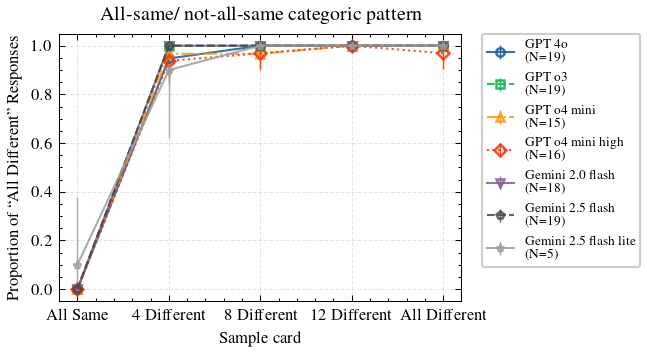

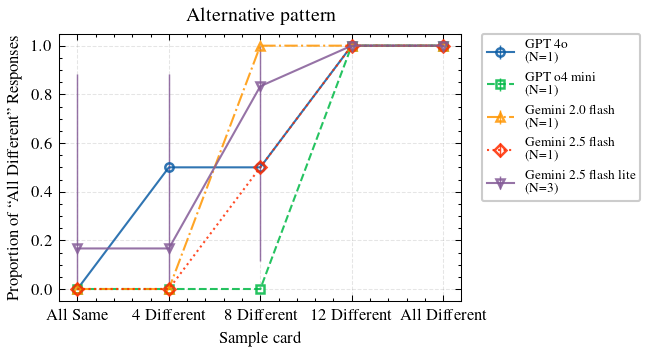

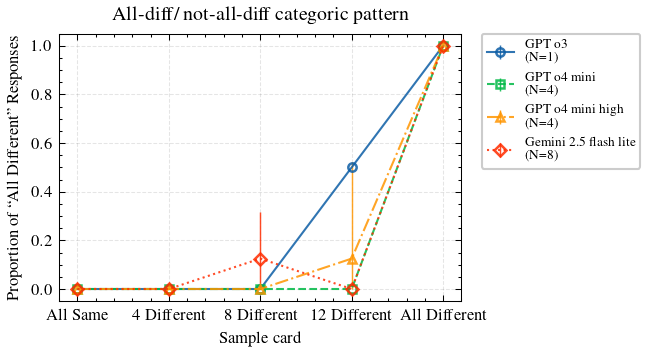

  -> Se omitió 'Continuo inverso': Ningún modelo presentó este patrón.


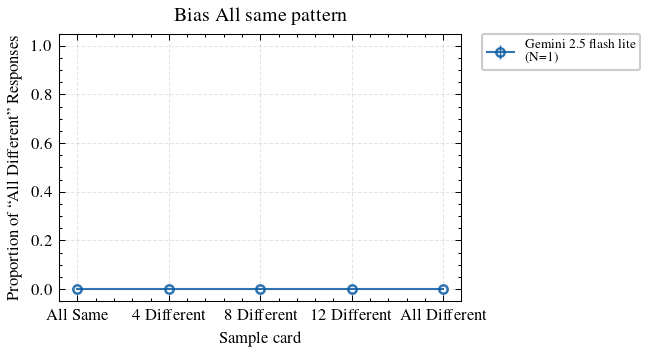

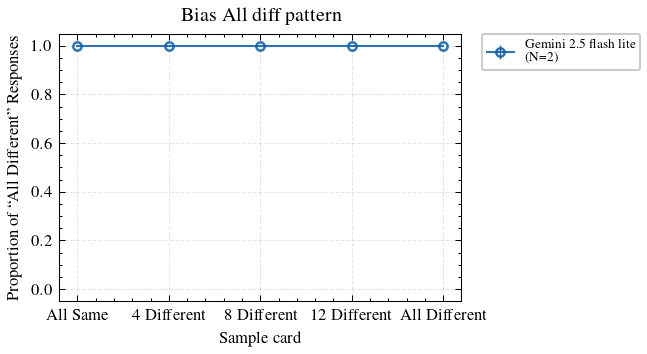

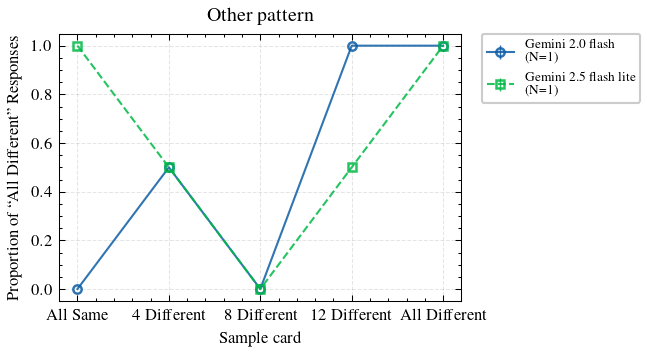


¡Todos los gráficos han sido generados exitosamente!


In [92]:

# 1. Definir los patrones que queremos graficar según lo solicitado
patrones_a_graficar = [
    "Categórico", 
    "Continuo", 
    "Categórico Inverso",
    "Continuo inverso",
    "Sesgo: Todo Igual (All Same)",
    "Sesgo: Todo Diferente (All Diff)",
    "Otro (Sin patrón claro)"
]

patterns = [
    "All-same/ not-all-same categoric",
    "Alternative",
    "All-diff/ not-all-diff categoric",
    "Inverse Continuous",
    "Bias All same",
    "Bias All diff",
    "Other"
]

# 2. Definir las columnas de datos (eje Y) y las etiquetas (eje X)
cols_entropia = ['Prop_Entropia_0', 'Prop_Entropia_4', 'Prop_Entropia_8', 'Prop_Entropia_12', 'Prop_Entropia_16']
etiquetas_x = ["All Same", "4 Different", "8 Different", "12 Different", "All Different"]

# 3. Agrupar y promediar: Calculamos la curva promedio para cada modelo DENTRO de cada patrón
# Si un modelo no presentó un patrón, simplemente no existirá en este dataframe filtrado
df_curvas = tabla_final.groupby(['Model', 'Patron_Detectado'])[cols_entropia].mean().reset_index()

# 4. Configurar listas amplias de marcadores y estilos de línea para que sean distinguibles en B/N
marcadores = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'h', '<', '>']
estilos_linea = ['-', '--', '-.', ':', '-', '--']

print("Generando gráficos de patrones...")

# 5. Iterar sobre cada patrón para crear un gráfico independiente
for j in range(len(patrones_a_graficar)):

    patron = patrones_a_graficar[j]
    # Filtramos los datos solo para el patrón que estamos graficando ahora
    df_patron = df_curvas[df_curvas['Patron_Detectado'] == patron].copy()
    nombre_patron = patterns[j]
    
    # Si ningún modelo tuvo este patrón, saltamos el gráfico
    if df_patron.empty:
        print(f"  -> Se omitió '{patron}': Ningún modelo presentó este patrón.")
        continue
        
    # Crear la figura
    plt.figure(figsize=(4.5, 2.5))
    
    # Obtenemos los modelos únicos que presentaron este patrón
    modelos_en_patron = tabla_final[tabla_final['Patron_Detectado'] == patron]['Model'].unique()
    
    for idx, modelo in enumerate(modelos_en_patron):
        # Filtramos las instancias originales (sin promediar) de este modelo y patrón
        df_modelo = tabla_final[(tabla_final['Model'] == modelo) & (tabla_final['Patron_Detectado'] == patron)]
        n_instancias = len(df_modelo)
        
        # Etiqueta con el N
        etiqueta_modelo = f"{format_model_name(modelo)} \n(N={n_instancias})"
        
        # Medias por nivel de entropía
        valores_y = df_modelo[cols_entropia].mean().values
        
        # Calcular los márgenes de error asimétricos para cada uno de los 5 puntos
        yerr_lower = []
        yerr_upper = []
        
        for col, media in zip(cols_entropia, valores_y):
            if n_instancias > 1:
                std_err = sem(df_modelo[col])
                margin = std_err * t.ppf((1 + 0.95) / 2., n_instancias - 1) if std_err > 0 else 0
            else:
                margin = 0
            
            # Recortamos (clip) los errores igual que en las barras: de 0.0 a 1.0
            yerr_lower.append(media - max(0.0, media - margin))
            yerr_upper.append(min(1.0, media + margin) - media)
            
        yerr = [yerr_lower, yerr_upper]
        
        # Asignar estilo
        marcador_actual = marcadores[idx % len(marcadores)]
        linea_actual = estilos_linea[idx % len(estilos_linea)] #estilos_linea[(idx // len(marcadores)) % len(estilos_linea)]
        
        # Trazar la curva con barras de error usando plt.errorbar en vez de plt.plot
        plt.errorbar(etiquetas_x, valores_y, 
                     yerr=yerr,
                     marker=marcador_actual, 
                     linestyle=linea_actual,
                     #linewidth=2.5, 
                     markersize=4,
                     #capsize=3,           # Agrega las "tapitas" a las barras de error
                     #capthick=.1,
                     elinewidth=.7,
                     alpha=0.85, 
                     markerfacecolor='none',
                     markeredgewidth=1.2,
                     label=etiqueta_modelo)
                 
    # Personalización visual del gráfico
    plt.title(f'{nombre_patron} pattern')#, fontsize=15, pad=15, fontweight='bold')

    plt.xlabel('Sample card', fontweight='bold')
    plt.ylabel(r'Proportion of ``All Different" Responses', fontweight='bold')
    
    # Forzar el eje Y a ir estrictamente de 0 a 1 (añadimos pequeño margen visual)
    plt.ylim(-0.05, 1.05)
    plt.yticks(np.arange(0, 1.1, 0.2))
    
    # Cuadrícula para facilitar la lectura
    plt.grid(True, linestyle='--', alpha=0.1)
    
    # Poner la leyenda fuera del gráfico para que no tape las curvas
    #plt.legend(fontsize=5)#title='Modelos')#, bbox_to_anchor=(1.02, 1), loc='upper left')#, fontsize=10, title_fontsize=11)
    plt.legend(fontsize=6.5, bbox_to_anchor=(1.05, 1),
               loc='upper left', borderaxespad=0,
               ncol=1, fancybox=True)

    plt.tight_layout()
    
    # Limpiar el nombre del archivo (quitar espacios y paréntesis)
    nombre_seguro = patron.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    nombre_archivo = f'grafico_patron_{nombre_seguro}.pdf'
    
    # Guardar
    #plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    #print(f"  -> Guardado: {nombre_archivo}")
    
    # Cerramos la figura para no sobrecargar la memoria
    plt.show()
    plt.close()

print("\n¡Todos los gráficos han sido generados exitosamente!")

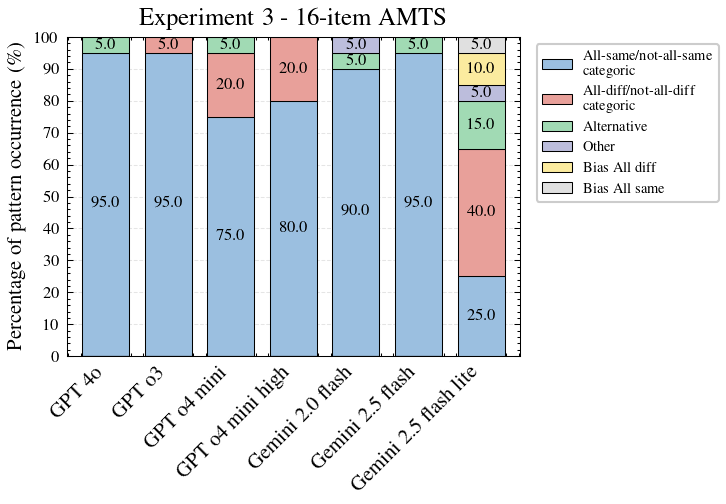

In [93]:
# 1. Configurar la figura
fig, ax = plt.subplots(figsize=(5, 3.5))

patterns = [
    "All-same/not-all-same \n categoric",
    "All-diff/not-all-diff \n categoric",
    "Alternative",
    "Other",
    "Bias All diff",
    "Bias All same"
]

colors = [
    '#9BBFE0', # Azul suave (versión pálida de tu #4C72B0)
    '#E8A09A', # Rojo ladrillo/Salmón apagado (versión pálida de tu #C44E52)
    '#A1DAB4', # Verde menta desaturado
    '#BCBDDC', # Lavanda/Púrpura grisáceo
    '#FBEB9F', # Amarillo mostaza muy pálido
    #'#9EBCDA', # Azul acero/Cian apagado
    '#E0E0E0'  # Gris claro pálido (para la categoría "Other")
]
# 2. Generar el gráfico de barras apiladas
# Usamos un mapa de colores distinguible para las diferentes categorías
# resumen_porcentajes ya tiene los modelos como índice (eje X) y los patrones como columnas
resumen_porcentajes.index = resumen_porcentajes.index.map(format_model_name)

resumen_porcentajes.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    width=0.75,
    #colormap='Set2', # Set2 es un mapa de colores muy amigable a la vista y académico
    edgecolor='black', # Bordes negros para separar bien las secciones
    linewidth=0.5,
    color=colors
)


# 3. Personalizar textos y ejes
ax.set_title('Experiment 3 - 16-item AMTS', fontsize=12)#, fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('')#, fontsize=13, labelpad=15)
ax.set_ylabel(r'Percentage of pattern occurrence (\%)', fontsize=10)#, fontsize=13, labelpad=10)

# El eje Y debe ir exactamente de 0 a 100
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))

# Rotar los nombres de los modelos para que no se superpongan
plt.xticks(rotation=45, ha='right', fontsize=10)#, fontsize=11)

# 4. Configurar la leyenda (fuera del gráfico para que no tape los datos)
plt.legend(
    labels=patterns,
    #title='Patrón Detectado', 
    bbox_to_anchor=(1.02, 1), 
    #loc='upper left', 
    fontsize=7, 
    #title_fontsize=12
)

# 5. (Opcional pero muy recomendado para el paper) Agregar los porcentajes dentro de las barras
for c in ax.containers:
    # Solo mostramos el texto si el porcentaje es mayor a 3% para que no se amontonen visualmente
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')#, fontsize=9, fontweight='bold', color='#333333')

# Ajustar márgenes y guardar
plt.tight_layout()
#plt.savefig('grafico_patrones_apilados.pdf', dpi=300, bbox_inches='tight')
#print("Gráfico de barras apiladas guardado como 'grafico_patrones_apilados.png'")

# Cerrar la figura para liberar memoria
plt.show()
plt.close()

In [94]:
# Asumimos que 'tabla_final' ya existe y tiene las columnas:
# Model, Set, Realization, Prop_Entropia_0 ... Prop_Entropia_16

def analizar_instancia_detallado(row):
    # 1. Extraer datos observados
    datos = np.array([
        row['Prop_Entropia_0'], row['Prop_Entropia_4'], 
        row['Prop_Entropia_8'], row['Prop_Entropia_12'], 
        row['Prop_Entropia_16']
    ])
    
    # 2. Definir Patrones Teóricos
    patrones = {
        "Categórico":        np.array([0, 1, 1, 1, 1]),
        "Categórico Inv":    np.array([1, 0, 0, 0, 0]),
        "Continuo":         np.array([0, 0.15, 0.5, 0.85, 1]),
        "Continuo Inv":     np.array([1, 0.85, 0.5, 0.15, 0])
    }
    
    # 3. Detectar Sesgos Planos (Varianza Cero)
    # Si la desviación estándar es 0, Pearson falla (división por cero).
    if np.std(datos) == 0:
        mean_val = np.mean(datos)
        tipo = "Sesgo: Todo Igual" if mean_val < 0.2 else "Sesgo: Todo Diferente" if mean_val > 0.8 else "Plano (Otro)"
        # Devolvemos valores dummy para R y P, ya que no aplican aquí
        return pd.Series([tipo, 1.0, 0.0], index=['Clasificacion', 'Pearson_R', 'P_Value'])

    # 4. Competencia de Modelos
    mejor_patron = "Sin Patrón (No Sig.)"
    mejor_r = -1.0
    mejor_p = 1.0
    
    for nombre, vector_ideal in patrones.items():
        # Calcular correlación
        r, p = pearsonr(datos, vector_ideal)
        
        # CONDICIONES PARA GANAR:
        # A. Significancia: p < 0.05
        # B. Correlación Positiva: r > 0 (si es negativa, se parece al inverso)
        # C. Mejor ajuste: r mayor al encontrado hasta ahora
        if p < 0.05 and r > 0 and r > mejor_r:
            mejor_r = r
            mejor_p = p
            mejor_patron = nombre
            
    return pd.Series([mejor_patron, mejor_r, mejor_p], index=['Clasificacion', 'Pearson_R', 'P_Value'])

# --- EJECUCIÓN ---

# Aplicamos la función fila por fila
# Esto crea 3 nuevas columnas en tu dataframe original
cols_resultado = tabla_final.apply(analizar_instancia_detallado, axis=1)
df_clasificado = pd.concat([tabla_final, cols_resultado], axis=1)

# Supongamos que 'df_clasificado' es tu dataframe con los resultados individuales
# Filtramos solo las instancias que SÍ fueron clasificadas (quitamos "Sin Patrón")
df_calidad = df_clasificado[df_clasificado['Clasificacion'] != 'Sin Patrón (No Sig.)'].copy()

# 1. Función para formatear el P-Value visualmente
def format_p_value(val):
    if pd.isna(val): return "-"      # Si no hay datos, guion
    if val == 0: return "< 0.001"    # Si es 0 absoluto, es menor a 0.001
    if val < 0.001: return "< 0.001" # Si es muy pequeño, notación estándar
    return f"{val:.4f}"              # Si es normal, 4 decimales

# 2. Crear la tabla pivote con el promedio de P-Value
pivot_p = df_calidad.pivot_table(index='Model', columns='Clasificacion', values='P_Value', aggfunc='mean')

# 3. Aplicar el formato
pivot_clean = pivot_p.map(format_p_value)

# 4. (Opcional) Agregar conteo de cuántas instancias hubo
# Esto es muy útil para saber si el promedio viene de 10 casos o solo de 1
pivot_count = df_calidad.pivot_table(index='Model', columns='Clasificacion', values='P_Value', aggfunc='count').fillna(0).astype(int)

print("--- Calidad del Ajuste (P-Value Promedio) ---")
print(pivot_clean)

print("\n--- Cantidad de Instancias por Patrón ---")
print(pivot_count)

--- Calidad del Ajuste (P-Value Promedio) ---
Clasificacion         Categórico Continuo Sesgo: Todo Diferente  \
Model                                                             
GPT_4o                   < 0.001   0.0198                     -   
GPT_o3                   < 0.001        -                     -   
GPT_o4_mini              < 0.001   0.0380                     -   
GPT_o4_mini_high         < 0.001        -                     -   
Gemini_2_0_flash         < 0.001   0.0380                     -   
Gemini_2_5_flash         < 0.001   0.0022                     -   
Gemini_2_5_flash_lite    < 0.001   0.0261               < 0.001   

Clasificacion         Sesgo: Todo Igual  
Model                                    
GPT_4o                                -  
GPT_o3                                -  
GPT_o4_mini                           -  
GPT_o4_mini_high                      -  
Gemini_2_0_flash                      -  
Gemini_2_5_flash                      -  
Gemini_2_5_fla

In [95]:
# Asumimos que 'tabla_final' ya existe del paso anterior
df_anchoring = tabla_final.copy()

# 1. Función para convertir "Proporción de Diferente" a "Proporción de Elegir A"
# Recordatorio:
# - Set A: 'a' es Diferente. (Si Prop_Diff es 1, eligió A).
# - Set B: 'a' es Igual.     (Si Prop_Diff es 0, eligió A).

def calcular_eleccion_a(row, col_name):
    prop_diff = row[col_name]
    if row['Set'] == 'A':
        return prop_diff       # % de veces que eligió Diferente (que es A)
    else:
        return 1.0 - prop_diff # % de veces que eligió Igual (que es A)

# 2. Aplicar esto a todas las columnas de entropía
niveles = [0, 4, 8, 12, 16]
cols_diff = [f'Prop_Entropia_{n}' for n in niveles]
cols_A    = [f'Prob_Elegir_A_{n}' for n in niveles]

for c_diff, c_A in zip(cols_diff, cols_A):
    df_anchoring[c_A] = df_anchoring.apply(lambda row: calcular_eleccion_a(row, c_diff), axis=1)

# 3. Agrupar por Modelo para ver el patrón promedio
# Promediamos las instancias y los sets para ver la tendencia pura del modelo
perfil_anchoring = df_anchoring.groupby('Model')[cols_A].mean()

# 4. Calcular métricas resumen para probar tu hipótesis
perfil_anchoring['Promedio_Extremos'] = perfil_anchoring[['Prob_Elegir_A_0', 'Prob_Elegir_A_16']].mean(axis=1)
perfil_anchoring['Promedio_Intermedios'] = perfil_anchoring[['Prob_Elegir_A_4', 'Prob_Elegir_A_8', 'Prob_Elegir_A_12']].mean(axis=1)

# Calculamos el "Delta de Confusión": Cuánto sube el Anchoring en la zona intermedia
perfil_anchoring['Efecto_Confusion'] = perfil_anchoring['Promedio_Intermedios'] - perfil_anchoring['Promedio_Extremos']

print("--- Probabilidad de Elegir Sample 'a' por Nivel de Entropía ---")
print("(Valor 0.5 = Ideal/Neutro | Valor 1.0 = Anchoring Total | Valor 0.0 = Recency Total)")
print(perfil_anchoring.round(2))

print("\n--- Modelos con 'Anchoring por Confusión' (Hipótesis del usuario) ---")
# Filtramos los que tienen alto anchoring intermedio pero bajo/normal en extremos
sospechosos = perfil_anchoring[
    (perfil_anchoring['Promedio_Intermedios'] > 0.6) & 
    (perfil_anchoring['Efecto_Confusion'] > 0.1)
]

if not sospechosos.empty:
    print(sospechosos[['Promedio_Extremos', 'Promedio_Intermedios', 'Efecto_Confusion']].round(2))
else:
    print("Ningún modelo muestra una diferencia drástica entre extremos e intermedios.")

--- Probabilidad de Elegir Sample 'a' por Nivel de Entropía ---
(Valor 0.5 = Ideal/Neutro | Valor 1.0 = Anchoring Total | Valor 0.0 = Recency Total)
                       Prob_Elegir_A_0  Prob_Elegir_A_4  Prob_Elegir_A_8  \
Model                                                                      
GPT_4o                             0.5             0.52             0.48   
GPT_o3                             0.5             0.45             0.45   
GPT_o4_mini                        0.5             0.22             0.28   
GPT_o4_mini_high                   0.5             0.35             0.42   
Gemini_2_0_flash                   0.5             0.52             0.45   
Gemini_2_5_flash                   0.5             0.55             0.52   
Gemini_2_5_flash_lite              0.6             0.82             0.92   

                       Prob_Elegir_A_12  Prob_Elegir_A_16  Promedio_Extremos  \
Model                                                                          
GPT_4o

In [96]:
# Asumimos que 'tabla_final' ya existe (con las columnas Prop_Entropia_X)
df_anchoring = tabla_final.copy()

# 1. Función original para convertir Proporción Diferente a Proporción Elegir A
def calcular_eleccion_a(row, col_name):
    prop_diff = row[col_name]
    if row['Set'] == 'A':
        return prop_diff       # 'a' es Diferente
    else:
        return 1.0 - prop_diff # 'a' es Igual

niveles = [0, 4, 8, 12, 16]
cols_diff = [f'Prop_Entropia_{n}' for n in niveles]
cols_A    = [f'Prob_Elegir_A_{n}' for n in niveles]

for c_diff, c_A in zip(cols_diff, cols_A):
    df_anchoring[c_A] = df_anchoring.apply(lambda row: calcular_eleccion_a(row, c_diff), axis=1)

# 2. Calcular el Promedio en Niveles Intermedios (Incertidumbre) POR INSTANCIA
# Esto genera una nota de 0.0 a 1.0 para cada una de las ~20 instancias del modelo
df_anchoring['Promedio_Intermedios'] = df_anchoring[['Prob_Elegir_A_4', 'Prob_Elegir_A_8', 'Prob_Elegir_A_12']].mean(axis=1)

resultados_stats = []

# 3. Iterar modelo por modelo para hacer la prueba estadística
for modelo in df_anchoring['Model'].unique():
    # Extraemos el array de probabilidades de las instancias de ESTE modelo
    datos_modelo = df_anchoring[df_anchoring['Model'] == modelo]['Promedio_Intermedios'].dropna()
    
    n_instancias = len(datos_modelo)
    
    if n_instancias > 0:
        media_intermedios = datos_modelo.mean()
        
        # Para hacer el Wilcoxon de 1 muestra contra 0.5, le restamos 0.5 a los datos
        diferencias = datos_modelo - 0.5
        
        # Prevención de error: Si el modelo siempre respondió EXACTAMENTE 0.5 (sin varianza)
        if np.all(diferencias == 0):
            p_valor = 1.0 
        else:
            # alternative='two-sided' testea si es significativamente distinto de 0.5 en CUALQUIER dirección
            stat, p_valor = wilcoxon(diferencias, alternative='two-sided')
            
        # Clasificamos el tipo de sesgo descriptivamente para la tabla
        if media_intermedios > 0.55:
            sesgo = "Anchoring (Prefiere 'a')"
        elif media_intermedios < 0.45:
            sesgo = "Recency (Prefiere 'b')"
        else:
            sesgo = "Neutral"
            
        resultados_stats.append({
            'Modelo': modelo,
            'Prob. Media "a" (Niveles Medios)': media_intermedios,
            'Sesgo Descriptivo': sesgo,
            'P-value': p_valor,
            'Significativo': 'SÍ' if p_valor < 0.05 else 'NO'
        })

# 4. Mostrar los resultados formateados
df_resultados = pd.DataFrame(resultados_stats)

# Formatear la tabla
df_resultados['Prob. Media "a" (Niveles Medios)'] = df_resultados['Prob. Media "a" (Niveles Medios)'].apply(lambda x: f"{x:.2%}")
df_resultados['P-value'] = df_resultados['P-value'].apply(lambda x: f"{x:.4f}")

# Ordenar para que los más significativos queden arriba
df_resultados = df_resultados.sort_values(by='Prob. Media "a" (Niveles Medios)', ascending=False)

print("--- ANÁLISIS ESTADÍSTICO DE SESGO POSICIONAL (NIVELES DE INCERTIDUMBRE) ---")
print("Se evaluó si la probabilidad media de elegir 'a' en entropías 4, 8 y 12")
print("es estadísticamente distinta del 50% (azar) mediante la prueba de Wilcoxon.\n")

print(df_resultados.to_string(index=False))

--- ANÁLISIS ESTADÍSTICO DE SESGO POSICIONAL (NIVELES DE INCERTIDUMBRE) ---
Se evaluó si la probabilidad media de elegir 'a' en entropías 4, 8 y 12
es estadísticamente distinta del 50% (azar) mediante la prueba de Wilcoxon.

               Modelo Prob. Media "a" (Niveles Medios)        Sesgo Descriptivo P-value Significativo
Gemini_2_5_flash_lite                           90.83% Anchoring (Prefiere 'a')  0.0001            SÍ
     Gemini_2_5_flash                           52.50%                  Neutral  0.8185            NO
               GPT_4o                           50.00%                  Neutral  0.8719            NO
     Gemini_2_0_flash                           49.17%                  Neutral  0.9821            NO
               GPT_o3                           45.83%                  Neutral  0.8024            NO
     GPT_o4_mini_high                           40.00%   Recency (Prefiere 'b')  0.3197            NO
          GPT_o4_mini                           26.67%   Rece

## Reasoning time

--- MEAN REASONING TIME BY ENTROPY ---
           Model Entropy_Label  Mean Time (s)  Standard Error (s)
          GPT o3      All Same           2.61                0.33
          GPT o3   4 Different           7.27                0.65
          GPT o3   8 Different           7.15                1.61
          GPT o3  12 Different           5.72                0.82
          GPT o3 All Different           3.61                0.69
     GPT o4 mini      All Same           2.68                0.25
     GPT o4 mini   4 Different           7.16                0.89
     GPT o4 mini   8 Different           6.96                0.88
     GPT o4 mini  12 Different           6.36                0.86
     GPT o4 mini All Different           3.80                0.28
GPT o4 mini high      All Same           3.12                0.38
GPT o4 mini high   4 Different          10.92                1.38
GPT o4 mini high   8 Different           8.90                1.16
GPT o4 mini high  12 Different       

/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/166612036.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_inst = df_time.groupby(['Model', 'Set', 'Realization', 'Entropy_Label'])['Reasoning_Time_sec'].mean().reset_index()
/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/166612036.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_time = df_inst.groupby(['Model', 'Entropy_Label'])['Reasoning_Time_sec'].agg(['mean', sem]).reset_index()


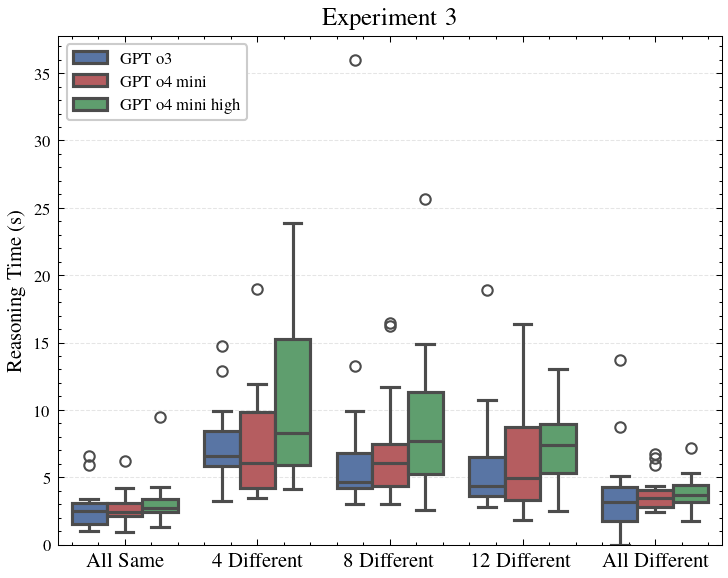

In [34]:
# Assuming df_exp3 is already loaded in your environment

# 1. Filter only the reasoning models
reasoning_models = ['GPT_o3', 'GPT_o4_mini', 'GPT_o4_mini_high']
df_time = df_exp3[df_exp3['Model'].isin(reasoning_models)].copy()

# 2. Convert reasoning time from milliseconds to seconds
df_time['Reasoning_Time_sec'] = df_time['Razon time'] / 1000

# 3. Map numerical entropy to descriptive labels for the X-axis
entropy_map = {
    0: 'All Same',
    4: '4 Different',
    8: '8 Different',
    12: '12 Different',
    16: 'All Different'
}
df_time['Entropy_Label'] = df_time['Entropy'].map(entropy_map)

# Convert to a Categorical type to enforce the logical order on the X-axis
df_time['Entropy_Label'] = pd.Categorical(
    df_time['Entropy_Label'], 
    categories=['All Same', '4 Different', '8 Different', '12 Different', 'All Different'], 
    ordered=True
)

# 4. Calculate mean reasoning time per instance (Realization) and Entropy Level
# Note: Based on your screenshot, instances are under the 'Realization' column here
df_inst = df_time.groupby(['Model', 'Set', 'Realization', 'Entropy_Label'])['Reasoning_Time_sec'].mean().reset_index()

# Apply your custom formatting function to the model names
# (Assuming format_model_name is already defined in your environment)
df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- NUMERICAL SUMMARY ---
summary_time = df_inst.groupby(['Model', 'Entropy_Label'])['Reasoning_Time_sec'].agg(['mean', sem]).reset_index()
summary_time.rename(columns={'mean': 'Mean Time (s)', 'sem': 'Standard Error (s)'}, inplace=True)

print("--- MEAN REASONING TIME BY ENTROPY ---")
print(summary_time.round(2).to_string(index=False))
print("\n")

# --- PLOTTING ---

# 5. Configure the figure and style (strictly using your 5x4 format)
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid")

# 6. Create the Boxplot
# x: Entropy Levels, y: Reasoning Time, hue: Models
ax = sns.boxplot(
    data=df_inst,
    x='Entropy_Label',
    y='Reasoning_Time_sec',
    hue='Model',
    palette=['#4C72B0', '#C44E52', '#55A868'], # Added a 3rd color (Green) for the 3rd model
    linewidth=1.5,
    fliersize=5 
)

# 7. Chart Customization
# Force the Y-axis to start at 0
plt.ylim(bottom=0)

# Rotate X labels slightly so they don't overlap (since there are 5 categories now)
plt.xticks(fontsize=10)#rotation=45, ha='right')

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', loc='upper left')

# Clear the X label and set the custom titles
plt.xlabel("")
plt.ylabel("Reasoning Time (s)", fontsize=10)
plt.title('Experiment 3', fontsize=12)

plt.tight_layout()
#plt.savefig('reasoning_time_exp_3.pdf', bbox_inches='tight')
plt.show()

## Counting

In [95]:
# Download the required tokenizer if not already downloaded
try:
    word_tokenize("test")
except LookupError:
    try:
        nltk.download('punkt')
        nltk.download('punkt_tab') # Explicitly download punkt_tab
    except LookupError:
        print("Could not download NLTK punkt resources. Please try running nltk.download('punkt') and nltk.download('punkt_tab') manually.")

# Define keywords related to "same" and "different"
same_keywords = ['same', 'identical', 'similar', 'uniform', 'repeat', 'repeated', 'all same']
different_keywords = ['different', 'distinct', 'varied', 'diverse', 'mix', 'mixture', 'variety', 'all different']
# Add negation keywords
negation_keywords = ['not', 'no', 'n\'t', ]
card_comparison_keywords = ['similar to card', 'like card', 'similar to the pattern in card']


def count_keywords(text: str, positive_keywords: List[str], negative_keywords: List[str], negation_keywords: List[str]) -> Tuple[int, int]:
    """
    Checks for the presence of specified keywords in a text string,
    considering negation words and counting negated keywords for the opposite category,
    returning a binary indicator (1 if present, 0 if not).

    Args:
        text: The input text string.
        positive_keywords: A list of keywords for the positive category.
        negative_keywords: A list of keywords for the negative category.
        negation_keywords: A list of words that negate the keywords.

    Returns:
        A tuple containing a binary indicator for positive keywords and a binary indicator for negative keywords.
    """
    if not isinstance(text, str):
        return 0, 0
    text = text.lower()
    tokens = word_tokenize(text)
    has_positive_keyword = 0
    has_negative_keyword = 0
    i = 0
    while i < len(tokens):
        is_negated = i > 0 and tokens[i-1] in negation_keywords

        if tokens[i] in positive_keywords:
            if is_negated:
                has_negative_keyword = 1
            else:
                has_positive_keyword = 1
        elif tokens[i] in negative_keywords:
             if is_negated:
                has_positive_keyword = 1
             else:
                has_negative_keyword = 1
        i += 1
        # If we found a keyword for both categories, we can stop early
        if has_positive_keyword and has_negative_keyword:
            break
    return has_positive_keyword, has_negative_keyword


# Apply the function to the 'Explanation' column with negation handling and count for both categories
keyword_presence = exp_3_df['Explanation'].apply(lambda x: count_keywords(x, same_keywords, different_keywords, negation_keywords))

# Assign the binary indicators to new columns
exp_3_df['same_keyword_present'] = keyword_presence.apply(lambda x: x[0])
exp_3_df['different_keyword_present'] = keyword_presence.apply(lambda x: x[1])

# Drop the old keyword count columns if they exist to avoid confusion
if 'same_keyword_count' in exp_3_df.columns:
    exp_3_df = exp_3_df.drop(columns=['same_keyword_count'])
if 'different_keyword_count' in exp_3_df.columns:
    exp_3_df = exp_3_df.drop(columns=['different_keyword_count'])


print("DataFrame with keyword presence indicators:")
display(exp_3_df.head())

DataFrame with keyword presence indicators:


,Exp,Set,Split,File,Model,Answer,Explanation,Razon time,Entropy,Decision,Relevance,same_keyword_present,different_keyword_present
0,3,A,test,01.png,Gemini_2_5_flash,b,"It contains multiple identical icons, similar to card ""b"".",0.0,0,All same,1,1,0
1,3,A,test,02.png,Gemini_2_5_flash,a,"It contains a variety of different icons, similar to card ""a"".",0.0,4,All different,1,1,1
2,3,A,test,03.png,Gemini_2_5_flash,a,"It contains a mix of different icons, similar to card ""a"".",0.0,1,All different,1,1,1
3,3,A,test,04.png,Gemini_2_5_flash,a,"It contains a variety of different icons, similar to card ""a"".",0.0,3,All different,1,1,1
4,3,A,test,05.png,Gemini_2_5_flash,a,"It contains a mix of different icons, similar to card ""a"".",0.0,2,All different,1,1,1


In [96]:
# Group by Model and Answer and calculate the average keyword counts
keyword_frequency_by_model_answer = exp_3_df.groupby(['Model', 'Decision'])[['same_keyword_present', 'different_keyword_present']].mean()

print("Average Keyword Frequency by Model and Decision:")
display(keyword_frequency_by_model_answer)

Average Keyword Frequency by Model and Decision:


same_keyword_present  \
Model                 Decision                              
GPT_4o                All different              0.544872   
                      All same                   0.931818   
GPT_o3                All different              0.832258   
                      All same                   0.844444   
GPT_o4_mini           All different              0.623077   
                      All same                   0.914286   
GPT_o4_mini_high      All different              0.736842   
                      All same                   0.803279   
Gemini_2_0_flash      All different              0.374194   
                      All same                   1.000000   
Gemini_2_5_flash      All different              0.821656   
                      All same                   1.000000   
Gemini_2_5_flash_lite All different              0.788991   
                      All same                   0.911765   

                                     different_keyword_present  
Model                 Decision                                  
GPT_4o                All different                   0.903846  
                      All same                        0.000000  
GPT_o3                All different                   0.980645  
                      All same                        0.044444  
GPT_o4_mini           All different                   0.915385  
                      All same                        0.000000  
GPT_o4_mini_high      All different                   0.977444  
                      All same                        0.032787  
Gemini_2_0_flash      All different                   0.929032  
                      All same                        0.066667  
Gemini_2_5_flash      All different                   0.993631  
                      All same                        0.000000  
Gemini_2_5_flash_lite All different                   0.678899  
                      All same                        0.039216

<Figure size 525x393.75 with 0 Axes>

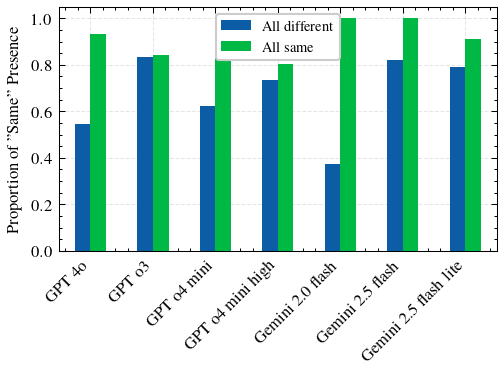

<Figure size 525x393.75 with 0 Axes>

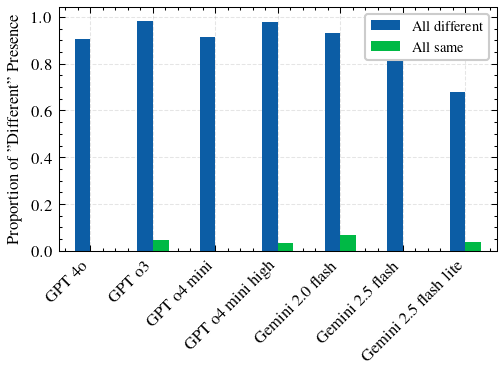

In [97]:
# Rename columns for better legend labels
keyword_frequency_by_model_answer_renamed = keyword_frequency_by_model_answer.rename(columns={
    'same_keyword_present': 'Same keyword present',
    'different_keyword_present': 'Different keyword present'
})

# Prepare data for plotting: Unstack the 'Decision' level to have columns for each decision's keyword presence
# This results in a DataFrame with 'Model' as index and 'Decision' as columns for each keyword type
keyword_frequency_unstacked = keyword_frequency_by_model_answer_renamed.unstack(level='Decision')

# Filter out 'neither' and blank columns
# Check if 'neither' and blank are levels in the columns before dropping
columns_to_drop = []
if 'neither' in keyword_frequency_unstacked.columns.get_level_values('Decision'):
    columns_to_drop.append('neither')
if '' in keyword_frequency_unstacked.columns.get_level_values('Decision'):
    columns_to_drop.append('')

if columns_to_drop:
    keyword_frequency_unstacked = keyword_frequency_unstacked.drop(columns=columns_to_drop, level='Decision')


# --- Plotting for Same keyword present ---
plt.figure()
ax_same = keyword_frequency_unstacked['Same keyword present'].plot(kind='bar')
#plt.title('Proportion of "Same" Keyword Presence by Model and Decision Type (Excluding "Neither" Answers)')
plt.xlabel('') # X-axis represents the model
plt.ylabel('Proportion of "Same" Presence')

# Format x-axis tick labels (model names)
model_labels = keyword_frequency_unstacked.index.tolist()
formatted_model_labels = [re.sub(r'(\d) (\d)', r'\1.\2', label.replace('_', ' ')) for label in model_labels]
ax_same.set_xticklabels(formatted_model_labels, rotation=45, ha='right')

# Set legend title
ax_same.legend(fontsize=7)#title='Answer')


plt.tight_layout()
#plt.grid(axis='y')
plt.savefig(exp_3_path+"same_presence_model.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Plotting for Different keyword present ---
plt.figure()
ax_different = keyword_frequency_unstacked['Different keyword present'].plot(kind='bar')
#plt.title('Proportion of "Different" Keyword Presence by Model and Decision Type (Excluding "Neither" Answers)')
plt.xlabel('') # X-axis represents the model
plt.ylabel('Proportion of "Different" Presence')

# Format x-axis tick labels (model names)
model_labels = keyword_frequency_unstacked.index.tolist()
formatted_model_labels = [re.sub(r'(\d) (\d)', r'\1.\2', label.replace('_', ' ')) for label in model_labels]
ax_different.set_xticklabels(formatted_model_labels, rotation=45, ha='right')

# Set legend title
ax_different.legend(fontsize=7)#title='Answer')

plt.tight_layout()
#plt.grid(axis='y')
plt.savefig(exp_3_path+"diff_presence_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [98]:
# Group by Entropy and calculate the average keyword counts
keyword_frequency_by_entropy = exp_3_df.groupby('Entropy')[['same_keyword_present', 'different_keyword_present']].mean()

print("Average Keyword Frequency by Entropy Level:")
display(keyword_frequency_by_entropy)

Average Keyword Frequency by Entropy Level:


,same_keyword_present,different_keyword_present
Entropy,,
0,0.960993,0.039007
1,0.698582,0.712766
2,0.772242,0.790036
3,0.692580,0.830389
4,0.579505,0.918728


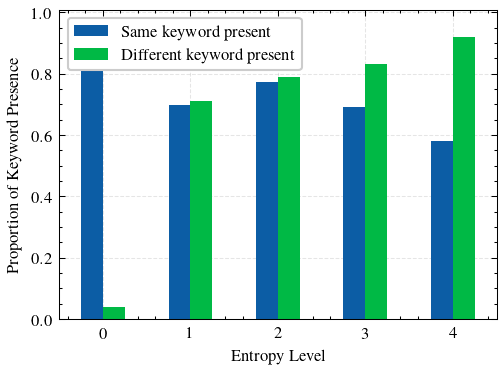

In [99]:
# Plotting average keyword frequency by Entropy Level
# Rename columns for better legend labels
keyword_frequency_by_entropy_renamed = keyword_frequency_by_entropy.rename(columns={
    'same_keyword_present': 'Same keyword present',
    'different_keyword_present': 'Different keyword present'
})

keyword_frequency_by_entropy_renamed.plot(kind='bar')
#plt.title('Proportion of Keyword Presence by Entropy Level')
plt.xlabel('Entropy Level')
plt.ylabel('Proportion of Keyword Presence')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.grid(axis='y')

plt.savefig(exp_3_path+"presence_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

Average 'Same' Keyword Presence by Model and Entropy Level:


Model,GPT_4o,GPT_o3,GPT_o4_mini,GPT_o4_mini_high,Gemini_2_0_flash,Gemini_2_5_flash,Gemini_2_5_flash_lite
Entropy,,,,,,,
0,0.950,0.875,1.000,1.000,1.000,1.000,0.904762
1,0.600,0.750,0.650,0.750,0.400,0.825,0.904762
2,0.575,0.925,0.875,0.825,0.475,0.825,0.902439
3,0.525,0.875,0.650,0.700,0.350,0.850,0.883721
4,0.500,0.750,0.450,0.550,0.350,0.800,0.651163


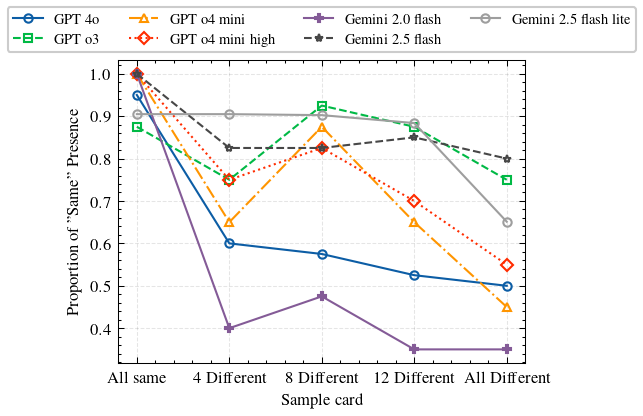

In [100]:
# Calculate the average frequency of 'same' keywords for each model at each entropy level
same_keyword_frequency_by_model_entropy = exp_3_df.groupby(['Model', 'Entropy'])['same_keyword_present'].mean().unstack(level='Model')

print("Average 'Same' Keyword Presence by Model and Entropy Level:")
display(same_keyword_frequency_by_model_entropy)

# Plotting average 'same' keyword frequency by Model and Entropy Level
plt.figure()
markers = ['o', 's', '^', 'D', 'P', '*']
lines = ['-', '--', '-.', ':', '-', '--']
marker_size = 4
entropy_plot_labels = ["All same", "4 Different", "8 Different", "12 Different", "All Different"]

marker_index = 0
line_index = 0

# Iterate through each model's data and plot a line
for column in same_keyword_frequency_by_model_entropy.columns:
    model_name = column
    display_label = model_name.replace('_', ' ')
    display_label = re.sub(r'(\d) (\d)', r'\1.\2', display_label)
    plt.plot(entropy_plot_labels, same_keyword_frequency_by_model_entropy[column], marker=markers[marker_index % len(markers)], linestyle=lines[line_index % len(lines)], 
             markersize=marker_size, label=display_label, markerfacecolor='none', markeredgewidth=1) # Added marker and linestyle
    marker_index += 1
    line_index += 1

plt.xlabel('Sample card', fontweight='bold')
plt.ylabel('Proportion of "Same" Presence', fontweight='bold')
#plt.title('Proportion of "Same" Keyword Presence by Model and Entropy Level')
plt.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.2),
          ncol=4, fancybox=True)
plt.grid(True)
plt.savefig(exp_3_path+"same_presence_model_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

Average 'Different' Keyword Presence by Model and Entropy Level:


Model,GPT_4o,GPT_o3,GPT_o4_mini,GPT_o4_mini_high,Gemini_2_0_flash,Gemini_2_5_flash,Gemini_2_5_flash_lite
Entropy,,,,,,,
0,0.000,0.050,0.000,0.050,0.000,0.000,0.166667
1,0.850,0.875,0.550,0.725,0.850,0.925,0.238095
2,0.875,0.950,0.675,0.775,0.950,0.975,0.341463
3,0.900,0.975,0.800,0.850,0.925,1.000,0.395349
4,0.900,1.000,0.950,0.950,0.950,1.000,0.697674


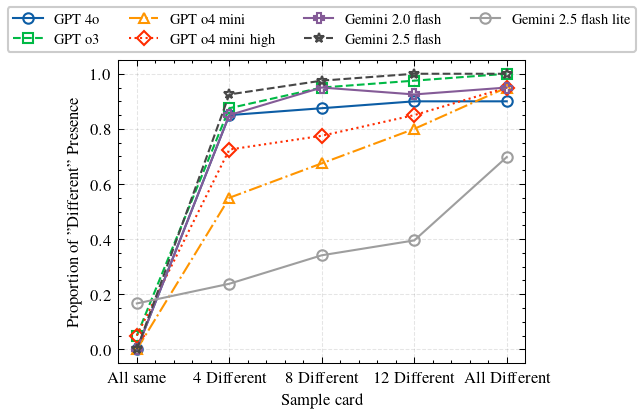

In [101]:
# Calculate the average frequency of 'different' keywords for each model at each entropy level
different_keyword_frequency_by_model_entropy = exp_3_df.groupby(['Model', 'Entropy'])['different_keyword_present'].mean().unstack(level='Model')

print("Average 'Different' Keyword Presence by Model and Entropy Level:")
display(different_keyword_frequency_by_model_entropy)

# Plotting average 'different' keyword frequency by Model and Entropy Level
plt.figure()
markers = ['o', 's', '^', 'D', 'P', '*']
lines = ['-', '--', '-.', ':', '-', '--']
marker_size = 5
entropy_plot_labels = ["All same", "4 Different", "8 Different", "12 Different", "All Different"]

marker_index = 0
line_index = 0

# Iterate through each model's data and plot a line
for column in different_keyword_frequency_by_model_entropy.columns:
    model_name = column
    display_label = model_name.replace('_', ' ')
    display_label = re.sub(r'(\d) (\d)', r'\1.\2', display_label)
    plt.plot(entropy_plot_labels, different_keyword_frequency_by_model_entropy[column], marker=markers[marker_index % len(markers)], 
             linestyle=lines[line_index % len(lines)], markersize=marker_size, label=display_label, markerfacecolor='none', markeredgewidth=1) # Added marker and linestyle

    marker_index += 1
    line_index += 1


plt.xlabel('Sample card', fontweight='bold')
plt.ylabel('Proportion of "Different" Presence', fontweight='bold')
#plt.title('Proportion of "Different" Keyword Presence by Model and Entropy Level')
plt.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.2),
          ncol=4, fancybox=True)
plt.grid(True)

plt.savefig(exp_3_path+"diff_presence_model_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

# Experiment 4

## Patterns

In [14]:
# 1. Cargar tu DataFrame (Asumiendo que ya lo tienes cargado como 'df')
# df = pd.read_csv('tu_archivo.csv') # Descomenta si necesitas cargar
df_proc = exp_4_df.copy()

# ---------------------------------------------------------
# PASO 1: DEFINIR LOS MAPAS DE ORDEN (Trial Index -> Entropía)
# ---------------------------------------------------------

# Traducimos tus listas a números de "Items Diferentes" (Entropía)
# 0=AllSame, 4=12Same, 8=8Same, 12=4Same, 16=AllDiff

# Orden Set A: [AllSame, AllDiff, 12same, 4same, 8same, AllDiff, 4same, AllSame, 12same, 8same]
secuencia_A = [0, 16, 4, 12, 8, 16, 12, 0, 4, 8]

# Orden Set B: [8same, AllSame, 8same, 4same, 12same, AllSame, AllDiff, AllDiff, 12same, 4same]
secuencia_B = [8, 0, 8, 12, 4, 0, 16, 16, 4, 12]

# ---------------------------------------------------------
# PASO 2: ASIGNAR EL TRIAL ID Y LA ENTROPÍA
# ---------------------------------------------------------

# Creamos un índice del 0 al 9 para cada fila dentro de su Instancia (Realization)
# Esto respeta el orden físico en el que aparecen las filas agrupadas.
df_proc['Trial_ID'] = df_proc.groupby(['Model', 'Set', 'Instance', 'Split']).cumcount()

# Función para asignar la entropía según el Set y el Trial_ID
def get_entropy(row):
    idx = row['Trial_ID']
    # Protección por si hay índices > 9 (no debería pasar si son bloques de 10)
    if idx > 9: return None 
    
    if row['Set'] == 'A':
        return secuencia_A[idx]
    elif row['Set'] == 'B':
        return secuencia_B[idx]
    return None

df_proc['Entropy'] = df_proc.apply(get_entropy, axis=1)

# ---------------------------------------------------------
# PASO 3: INTERPRETAR LA RESPUESTA (¿Eligió "All Different"?)
# ---------------------------------------------------------

def eligio_diferente(row):
    # Normalizamos a minúsculas y quitamos espacios por si acaso
    ans = str(row['Answer']).strip().lower()
    
    if row['Set'] == 'A':
        # En Set A: a = All Different, b = All Same
        return 1 if ans == 'a' else 0
        
    elif row['Set'] == 'B':
        # En Set B: a = All Same, b = All Different
        return 1 if ans == 'b' else 0
    
    return None

df_proc['Chose_Different'] = df_proc.apply(eligio_diferente, axis=1)

# ---------------------------------------------------------
# PASO 4: CALCULAR PROPORCIONES POR INSTANCIA
# ---------------------------------------------------------

# Agrupamos por Modelo, Set, Realización y Nivel de Entropía
# Calculamos el promedio (que será la proporción 0.0, 0.5 o 1.0)
# (0.5 ocurre porque hay 2 cartas de cada tipo en los 10 intentos)
df_proporciones = df_proc[df_proc['Split'] == 'test'].groupby(
    ['Model', 'Set', 'Instance', 'Entropy']
)['Chose_Different'].mean().reset_index()

# ---------------------------------------------------------
# PASO 5: FORMATO FINAL (PIVOT TABLE)
# ---------------------------------------------------------
# Lo convertimos en una tabla ancha donde las columnas son los niveles de entropía (0, 4, 8, 12, 16)
# Esto es lo que necesitas para comparar con los patrones ideales después.

tabla_final = df_proporciones.pivot_table(
    index=['Model', 'Set', 'Instance'], 
    columns='Entropy', 
    values='Chose_Different'
).reset_index()

# Renombrar columnas para claridad
tabla_final.columns.name = None # Quitar nombre del índice de columnas
tabla_final.rename(columns={
    0: 'Prop_Entropia_0',
    4: 'Prop_Entropia_4',
    8: 'Prop_Entropia_8',
    12: 'Prop_Entropia_12',
    16: 'Prop_Entropia_16'
}, inplace=True)

# Mostrar las primeras filas para verificar
print(tabla_final.loc[60:69].to_string())

               Model Set  Instance  Prop_Entropia_0  Prop_Entropia_4  Prop_Entropia_8  Prop_Entropia_12  Prop_Entropia_16
60  GPT_o4_mini_high   A         1              0.0              1.0              1.0               1.0               1.0
61  GPT_o4_mini_high   A         2              0.0              1.0              1.0               1.0               1.0
62  GPT_o4_mini_high   A         3              0.0              0.0              0.0               0.0               1.0
63  GPT_o4_mini_high   A         4              0.0              0.0              0.0               1.0               1.0
64  GPT_o4_mini_high   A         5              0.0              1.0              1.0               1.0               1.0
65  GPT_o4_mini_high   A         6              0.0              0.0              0.5               1.0               1.0
66  GPT_o4_mini_high   A         7              0.0              1.0              1.0               1.0               1.0
67  GPT_o4_mini_high   A

In [15]:
df_exp4 = df_proc

In [37]:
# Supongamos que tu dataframe se llama 'tabla_final' (el output del paso anterior)
# Columnas esperadas: ['Prop_Entropia_0', 'Prop_Entropia_4', ..., 'Prop_Entropia_16']

def clasificar_instancia_completa(row, umbral_corr=0.8):
    # 1. Extraer los datos reales de la fila
    # Ordenamos por nivel de entropía: 0, 4, 8, 12, 16
    datos = np.array([
        row['Prop_Entropia_0'], 
        row['Prop_Entropia_4'], 
        row['Prop_Entropia_8'], 
        row['Prop_Entropia_12'], 
        row['Prop_Entropia_16']
    ])
    
    # 2. DEFINIR LOS ARQUETIPOS (PATRONES IDEALES)
    
    # A. Categórico (Relacional): Salta de 0 a 1 inmediatamente
    patron_cat = np.array([0, 1, 1, 1, 1])
    
    # B. Categórico Inverso: Salta de 1 a 0 (Dice "Igual" a todo lo que sea diferente)
    patron_cat_inv = np.array([0, 0, 0, 0, 1])
    
    # C. Continuo / Similitud (Aproximación a Fig 2d en humanos): Curva Sigmoide
    # En 4 dif, se parece más a "All Same" (ej. 0.15)
    # En 8 dif, hay máxima duda en la similitud (0.5)
    # En 12 dif, se parece fuertemente a "All Diff" (ej. 0.85)
    patron_continuo = np.array([0, 0.15, 0.5, 0.85, 1])
    
    # D. Continuo Inverso: Sigmoide invertida
    patron_continuo_inv = np.array([1, 0.85, 0.5, 0.15, 0])

    # 3. CHEQUEO DE CASOS PLANOS (VARIANZA CERO)
    # Si el modelo respondió siempre lo mismo (todo 0 o todo 1), la correlación falla.
    # Es importante separarlos de "Otros" porque indican un sesgo fuerte.
    if np.std(datos) == 0:
        if np.mean(datos) < 0.2: return "Sesgo: Todo Igual (All Same)"
        if np.mean(datos) > 0.8: return "Sesgo: Todo Diferente (All Diff)"
        return "Otro (Plano intermedio)" # Raro, pero posible (ej: todo 0.5)

    # 4. COMPETENCIA DE MODELOS (CALCULAR CORRELACIONES)
    correlaciones = {
        "Categórico": pearsonr(datos, patron_cat)[0],
        "Categórico Inverso": pearsonr(datos, patron_cat_inv)[0],
        "Continuo": pearsonr(datos, patron_continuo)[0],
        "Continuo Inverso": pearsonr(datos, patron_continuo_inv)[0]
    }
    
    # 5. ELEGIR AL GANADOR
    # Buscamos quién tiene la correlación más alta
    mejor_patron = max(correlaciones, key=correlaciones.get)
    mejor_valor = correlaciones[mejor_patron]
    
    # 6. FILTRO FINAL
    # Solo asignamos la etiqueta si supera el umbral de similitud
    if mejor_valor > umbral_corr:
        return mejor_patron
    else:
        return "Otro (Sin patrón claro)"

# APLICAR A TU DATAFRAME
# Creamos la columna de clasificación
tabla_final['Patron_Detectado'] = tabla_final.apply(clasificar_instancia_completa, axis=1)

# VER RESUMEN
# Esto te dará la tabla para tu paper: Cuántas instancias cayeron en cada categoría por modelo
resumen_patrones = tabla_final.groupby(['Model', 'Patron_Detectado']).size().unstack(fill_value=0)

# Calcular porcentajes para facilitar la lectura
resumen_porcentajes = resumen_patrones.div(resumen_patrones.sum(axis=1), axis=0) * 100

print("--- Conteo de Patrones por Modelo ---")
print(resumen_patrones)
print("\n--- Porcentaje de Patrones por Modelo ---")
print(resumen_porcentajes.round(1))

--- Conteo de Patrones por Modelo ---
Patron_Detectado       Categórico  Categórico Inverso  Continuo  \
Model                                                             
GPT_4o                         20                   0         0   
GPT_o3                         20                   0         0   
GPT_o4_mini                    18                   1         1   
GPT_o4_mini_high               14                   3         2   
Gemini_2_0_flash               17                   0         3   
Gemini_2_5_flash               20                   0         0   
Gemini_2_5_flash_lite           3                   9         4   

Patron_Detectado       Otro (Sin patrón claro)  \
Model                                            
GPT_4o                                       0   
GPT_o3                                       0   
GPT_o4_mini                                  0   
GPT_o4_mini_high                             1   
Gemini_2_0_flash                             0   
Gemini_2

Generando gráficos de patrones...


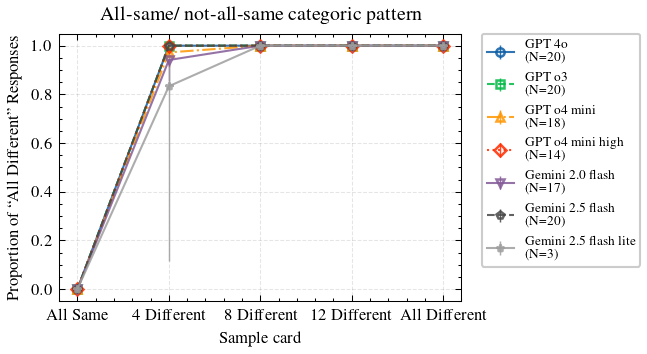

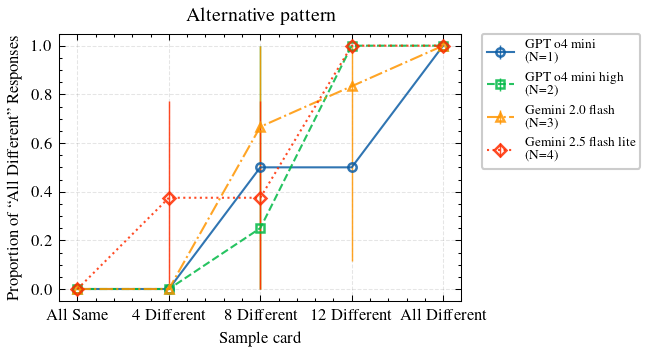

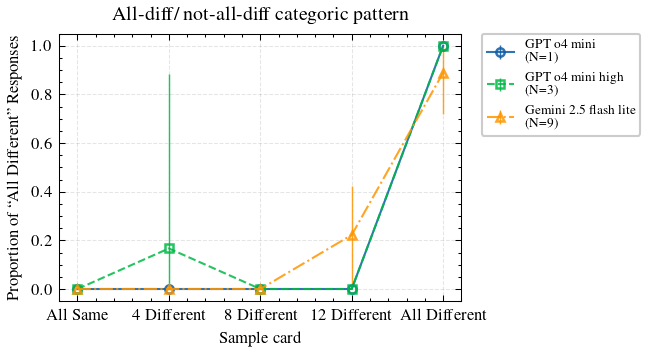

  -> Se omitió 'Continuo inverso': Ningún modelo presentó este patrón.


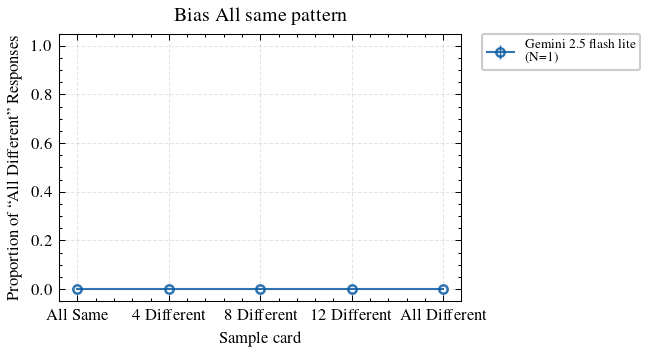

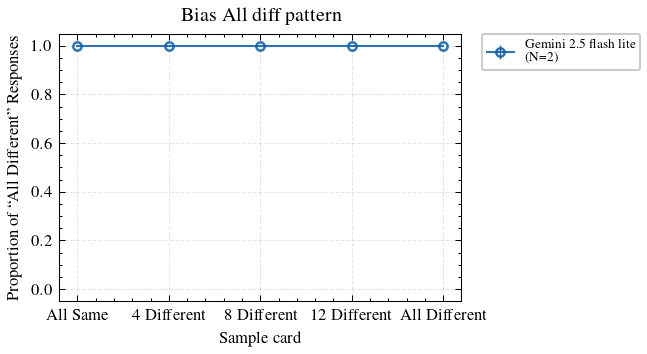

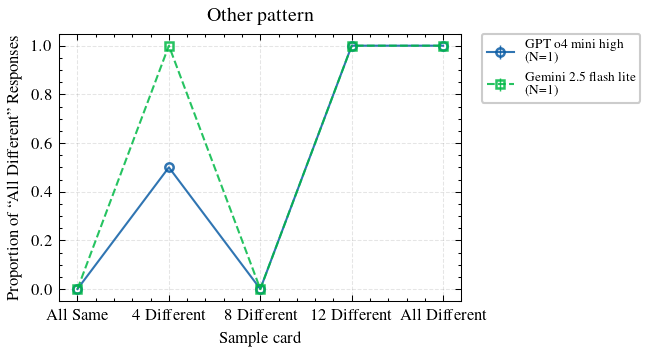


¡Todos los gráficos han sido generados exitosamente!


In [38]:

# 1. Definir los patrones que queremos graficar según lo solicitado
patrones_a_graficar = [
    "Categórico", 
    "Continuo", 
    "Categórico Inverso",
    "Continuo inverso",
    "Sesgo: Todo Igual (All Same)",
    "Sesgo: Todo Diferente (All Diff)",
    "Otro (Sin patrón claro)"
]

patterns = [
    "All-same/ not-all-same categoric",
    "Alternative",
    "All-diff/ not-all-diff categoric",
    "Inverse Continuous",
    "Bias All same",
    "Bias All diff",
    "Other"
]

# 2. Definir las columnas de datos (eje Y) y las etiquetas (eje X)
cols_entropia = ['Prop_Entropia_0', 'Prop_Entropia_4', 'Prop_Entropia_8', 'Prop_Entropia_12', 'Prop_Entropia_16']
etiquetas_x = ["All Same", "4 Different", "8 Different", "12 Different", "All Different"]

# 3. Agrupar y promediar: Calculamos la curva promedio para cada modelo DENTRO de cada patrón
# Si un modelo no presentó un patrón, simplemente no existirá en este dataframe filtrado
df_curvas = tabla_final.groupby(['Model', 'Patron_Detectado'])[cols_entropia].mean().reset_index()

# 4. Configurar listas amplias de marcadores y estilos de línea para que sean distinguibles en B/N
marcadores = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'h', '<', '>']
estilos_linea = ['-', '--', '-.', ':', '-', '--']

print("Generando gráficos de patrones...")

# 5. Iterar sobre cada patrón para crear un gráfico independiente
for j in range(len(patrones_a_graficar)):

    patron = patrones_a_graficar[j]
    # Filtramos los datos solo para el patrón que estamos graficando ahora
    df_patron = df_curvas[df_curvas['Patron_Detectado'] == patron].copy()
    nombre_patron = patterns[j]
    
    # Si ningún modelo tuvo este patrón, saltamos el gráfico
    if df_patron.empty:
        print(f"  -> Se omitió '{patron}': Ningún modelo presentó este patrón.")
        continue
        
    # Crear la figura
    plt.figure(figsize=(4.5, 2.5))
    
    # Obtenemos los modelos únicos que presentaron este patrón
    modelos_en_patron = tabla_final[tabla_final['Patron_Detectado'] == patron]['Model'].unique()
    
    for idx, modelo in enumerate(modelos_en_patron):
        # Filtramos las instancias originales (sin promediar) de este modelo y patrón
        df_modelo = tabla_final[(tabla_final['Model'] == modelo) & (tabla_final['Patron_Detectado'] == patron)]
        n_instancias = len(df_modelo)
        
        # Etiqueta con el N
        etiqueta_modelo = f"{format_model_name(modelo)} \n(N={n_instancias})"
        
        # Medias por nivel de entropía
        valores_y = df_modelo[cols_entropia].mean().values
        
        # Calcular los márgenes de error asimétricos para cada uno de los 5 puntos
        yerr_lower = []
        yerr_upper = []
        
        for col, media in zip(cols_entropia, valores_y):
            if n_instancias > 1:
                std_err = sem(df_modelo[col])
                margin = std_err * t.ppf((1 + 0.95) / 2., n_instancias - 1) if std_err > 0 else 0
            else:
                margin = 0
            
            # Recortamos (clip) los errores igual que en las barras: de 0.0 a 1.0
            yerr_lower.append(media - max(0.0, media - margin))
            yerr_upper.append(min(1.0, media + margin) - media)
            
        yerr = [yerr_lower, yerr_upper]
        
        # Asignar estilo
        marcador_actual = marcadores[idx % len(marcadores)]
        linea_actual = estilos_linea[idx % len(estilos_linea)] #estilos_linea[(idx // len(marcadores)) % len(estilos_linea)]
        
        # Trazar la curva con barras de error usando plt.errorbar en vez de plt.plot
        plt.errorbar(etiquetas_x, valores_y, 
                     yerr=yerr,
                     marker=marcador_actual, 
                     linestyle=linea_actual,
                     #linewidth=2.5, 
                     markersize=4,
                     #capsize=3,           # Agrega las "tapitas" a las barras de error
                     #capthick=.1,
                     elinewidth=.7,
                     alpha=0.85, 
                     markerfacecolor='none',
                     markeredgewidth=1.2,
                     label=etiqueta_modelo)
                 
    # Personalización visual del gráfico
    plt.title(f'{nombre_patron} pattern')#, fontsize=15, pad=15, fontweight='bold')

    plt.xlabel('Sample card', fontweight='bold')
    plt.ylabel(r'Proportion of ``All Different" Responses', fontweight='bold')
    
    # Forzar el eje Y a ir estrictamente de 0 a 1 (añadimos pequeño margen visual)
    plt.ylim(-0.05, 1.05)
    plt.yticks(np.arange(0, 1.1, 0.2))
    
    # Cuadrícula para facilitar la lectura
    plt.grid(True, linestyle='--', alpha=0.1)
    
    # Poner la leyenda fuera del gráfico para que no tape las curvas
    #plt.legend(fontsize=5)#title='Modelos')#, bbox_to_anchor=(1.02, 1), loc='upper left')#, fontsize=10, title_fontsize=11)
    plt.legend(fontsize=6.5, bbox_to_anchor=(1.05, 1),
               loc='upper left', borderaxespad=0,
               ncol=1, fancybox=True)

    plt.tight_layout()
    
    # Limpiar el nombre del archivo (quitar espacios y paréntesis)
    nombre_seguro = patron.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    nombre_archivo = f'grafico_patron_{nombre_seguro}.pdf'
    
    # Guardar
    #plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    #print(f"  -> Guardado: {nombre_archivo}")
    
    # Cerramos la figura para no sobrecargar la memoria
    plt.show()
    plt.close()

print("\n¡Todos los gráficos han sido generados exitosamente!")

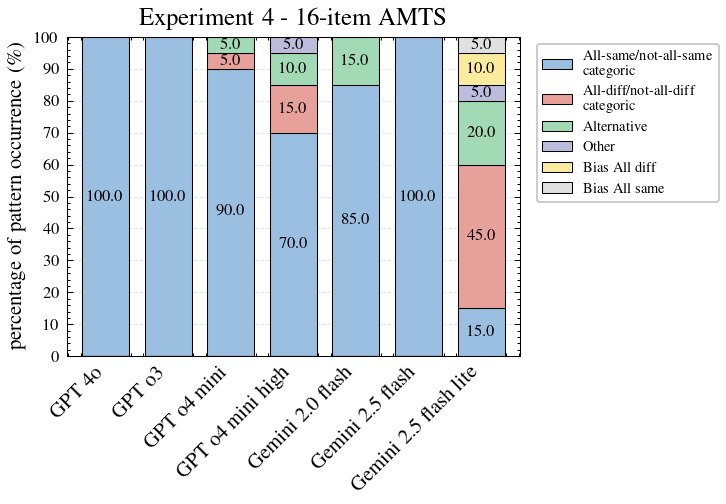

In [39]:
# 1. Configurar la figura
fig, ax = plt.subplots(figsize=(5, 3.5))

patterns = [
    "All-same/not-all-same \n categoric",
    "All-diff/not-all-diff \n categoric",
    "Alternative",
    "Other",
    "Bias All diff",
    "Bias All same"
]

colors = [
    '#9BBFE0', # Azul suave (versión pálida de tu #4C72B0)
    '#E8A09A', # Rojo ladrillo/Salmón apagado (versión pálida de tu #C44E52)
    '#A1DAB4', # Verde menta desaturado
    '#BCBDDC', # Lavanda/Púrpura grisáceo
    '#FBEB9F', # Amarillo mostaza muy pálido
    #'#9EBCDA', # Azul acero/Cian apagado
    '#E0E0E0'  # Gris claro pálido (para la categoría "Other")
]
# 2. Generar el gráfico de barras apiladas
# Usamos un mapa de colores distinguible para las diferentes categorías
# resumen_porcentajes ya tiene los modelos como índice (eje X) y los patrones como columnas
resumen_porcentajes.index = resumen_porcentajes.index.map(format_model_name)

resumen_porcentajes.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    width=0.75,
    #colormap='Set2', # Set2 es un mapa de colores muy amigable a la vista y académico
    edgecolor='black', # Bordes negros para separar bien las secciones
    linewidth=0.5,
    color=colors
)


# 3. Personalizar textos y ejes
ax.set_title('Experiment 4 - 16-item AMTS', fontsize=12)#, fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('')#, fontsize=13, labelpad=15)
ax.set_ylabel(r'percentage of pattern occurrence (\%)', fontsize=10)#, fontsize=13, labelpad=10)

# El eje Y debe ir exactamente de 0 a 100
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))

# Rotar los nombres de los modelos para que no se superpongan
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Configurar la leyenda (fuera del gráfico para que no tape los datos)
plt.legend(
    labels=patterns,
    #title='Patrón Detectado', 
    bbox_to_anchor=(1.02, 1), 
    #loc='upper left', 
    fontsize=7, 
    #title_fontsize=12
)

# 5. (Opcional pero muy recomendado para el paper) Agregar los porcentajes dentro de las barras
for c in ax.containers:
    # Solo mostramos el texto si el porcentaje es mayor a 3% para que no se amontonen visualmente
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')#, fontsize=9, fontweight='bold', color='#333333')

# Ajustar márgenes y guardar
plt.tight_layout()
plt.savefig('grafico_patrones_apilados.pdf', dpi=300, bbox_inches='tight')
#print("Gráfico de barras apiladas guardado como 'grafico_patrones_apilados.png'")

# Cerrar la figura para liberar memoria
plt.show()
plt.close()

In [40]:
# Asumimos que 'tabla_final' ya existe y tiene las columnas:
# Model, Set, Realization, Prop_Entropia_0 ... Prop_Entropia_16

def analizar_instancia_detallado(row):
    # 1. Extraer datos observados
    datos = np.array([
        row['Prop_Entropia_0'], row['Prop_Entropia_4'], 
        row['Prop_Entropia_8'], row['Prop_Entropia_12'], 
        row['Prop_Entropia_16']
    ])
    
    # 2. Definir Patrones Teóricos
    patrones = {
        "Categórico":        np.array([0, 1, 1, 1, 1]),
        "Categórico Inv":    np.array([1, 0, 0, 0, 0]),
        "Continuo":         np.array([0, 0.15, 0.5, 0.85, 1]),
        "Continuo Inv":     np.array([1, 0.85, 0.5, 0.15, 0])
    }
    
    # 3. Detectar Sesgos Planos (Varianza Cero)
    # Si la desviación estándar es 0, Pearson falla (división por cero).
    if np.std(datos) == 0:
        mean_val = np.mean(datos)
        tipo = "Sesgo: Todo Igual" if mean_val < 0.2 else "Sesgo: Todo Diferente" if mean_val > 0.8 else "Plano (Otro)"
        # Devolvemos valores dummy para R y P, ya que no aplican aquí
        return pd.Series([tipo, 1.0, 0.0], index=['Clasificacion', 'Pearson_R', 'P_Value'])

    # 4. Competencia de Modelos
    mejor_patron = "Sin Patrón (No Sig.)"
    mejor_r = -1.0
    mejor_p = 1.0
    
    for nombre, vector_ideal in patrones.items():
        # Calcular correlación
        r, p = pearsonr(datos, vector_ideal)
        
        # CONDICIONES PARA GANAR:
        # A. Significancia: p < 0.05
        # B. Correlación Positiva: r > 0 (si es negativa, se parece al inverso)
        # C. Mejor ajuste: r mayor al encontrado hasta ahora
        if p < 0.05 and r > 0 and r > mejor_r:
            mejor_r = r
            mejor_p = p
            mejor_patron = nombre
            
    return pd.Series([mejor_patron, mejor_r, mejor_p], index=['Clasificacion', 'Pearson_R', 'P_Value'])

# --- EJECUCIÓN ---

# Aplicamos la función fila por fila
# Esto crea 3 nuevas columnas en tu dataframe original
cols_resultado = tabla_final.apply(analizar_instancia_detallado, axis=1)
df_clasificado = pd.concat([tabla_final, cols_resultado], axis=1)

# Supongamos que 'df_clasificado' es tu dataframe con los resultados individuales
# Filtramos solo las instancias que SÍ fueron clasificadas (quitamos "Sin Patrón")
df_calidad = df_clasificado[df_clasificado['Clasificacion'] != 'Sin Patrón (No Sig.)'].copy()

# 1. Función para formatear el P-Value visualmente
def format_p_value(val):
    if pd.isna(val): return "-"      # Si no hay datos, guion
    if val == 0: return "< 0.001"    # Si es 0 absoluto, es menor a 0.001
    if val < 0.001: return "< 0.001" # Si es muy pequeño, notación estándar
    return f"{val:.4f}"              # Si es normal, 4 decimales

# 2. Crear la tabla pivote con el promedio de P-Value
pivot_p = df_calidad.pivot_table(index='Model', columns='Clasificacion', values='P_Value', aggfunc='mean')

# 3. Aplicar el formato
pivot_clean = pivot_p.map(format_p_value)

# 4. (Opcional) Agregar conteo de cuántas instancias hubo
# Esto es muy útil para saber si el promedio viene de 10 casos o solo de 1
pivot_count = df_calidad.pivot_table(index='Model', columns='Clasificacion', values='P_Value', aggfunc='count').fillna(0).astype(int)

print("--- Calidad del Ajuste (P-Value Promedio) ---")
print(pivot_clean)

print("\n--- Cantidad de Instancias por Patrón ---")
print(pivot_count)

--- Calidad del Ajuste (P-Value Promedio) ---
Clasificacion         Categórico Continuo Sesgo: Todo Diferente  \
Model                                                             
GPT_4o                   < 0.001        -                     -   
GPT_o3                   < 0.001        -                     -   
GPT_o4_mini              < 0.001   0.0198                     -   
GPT_o4_mini_high         < 0.001   0.0201                     -   
Gemini_2_0_flash         < 0.001   0.0200                     -   
Gemini_2_5_flash         < 0.001        -                     -   
Gemini_2_5_flash_lite    < 0.001   0.0244               < 0.001   

Clasificacion         Sesgo: Todo Igual  
Model                                    
GPT_4o                                -  
GPT_o3                                -  
GPT_o4_mini                           -  
GPT_o4_mini_high                      -  
Gemini_2_0_flash                      -  
Gemini_2_5_flash                      -  
Gemini_2_5_fla

In [41]:
# Asumimos que 'tabla_final' ya existe del paso anterior
df_anchoring = tabla_final.copy()

# 1. Función para convertir "Proporción de Diferente" a "Proporción de Elegir A"
# Recordatorio:
# - Set A: 'a' es Diferente. (Si Prop_Diff es 1, eligió A).
# - Set B: 'a' es Igual.     (Si Prop_Diff es 0, eligió A).

def calcular_eleccion_a(row, col_name):
    prop_diff = row[col_name]
    if row['Set'] == 'A':
        return prop_diff       # % de veces que eligió Diferente (que es A)
    else:
        return 1.0 - prop_diff # % de veces que eligió Igual (que es A)

# 2. Aplicar esto a todas las columnas de entropía
niveles = [0, 4, 8, 12, 16]
cols_diff = [f'Prop_Entropia_{n}' for n in niveles]
cols_A    = [f'Prob_Elegir_A_{n}' for n in niveles]

for c_diff, c_A in zip(cols_diff, cols_A):
    df_anchoring[c_A] = df_anchoring.apply(lambda row: calcular_eleccion_a(row, c_diff), axis=1)

# 3. Agrupar por Modelo para ver el patrón promedio
# Promediamos las instancias y los sets para ver la tendencia pura del modelo
perfil_anchoring = df_anchoring.groupby('Model')[cols_A].mean()

# 4. Calcular métricas resumen para probar tu hipótesis
perfil_anchoring['Promedio_Extremos'] = perfil_anchoring[['Prob_Elegir_A_0', 'Prob_Elegir_A_16']].mean(axis=1)
perfil_anchoring['Promedio_Intermedios'] = perfil_anchoring[['Prob_Elegir_A_4', 'Prob_Elegir_A_8', 'Prob_Elegir_A_12']].mean(axis=1)

# Calculamos el "Delta de Confusión": Cuánto sube el Anchoring en la zona intermedia
perfil_anchoring['Efecto_Confusion'] = perfil_anchoring['Promedio_Intermedios'] - perfil_anchoring['Promedio_Extremos']

print("--- Probabilidad de Elegir Sample 'a' por Nivel de Entropía ---")
print("(Valor 0.5 = Ideal/Neutro | Valor 1.0 = Anchoring Total | Valor 0.0 = Recency Total)")
print(perfil_anchoring.round(2))

print("\n--- Modelos con 'Anchoring por Confusión' (Hipótesis del usuario) ---")
# Filtramos los que tienen alto anchoring intermedio pero bajo/normal en extremos
sospechosos = perfil_anchoring[
    (perfil_anchoring['Promedio_Intermedios'] > 0.6) & 
    (perfil_anchoring['Efecto_Confusion'] > 0.1)
]

if not sospechosos.empty:
    print(sospechosos[['Promedio_Extremos', 'Promedio_Intermedios', 'Efecto_Confusion']].round(2))
else:
    print("Ningún modelo muestra una diferencia drástica entre extremos e intermedios.")

--- Probabilidad de Elegir Sample 'a' por Nivel de Entropía ---
(Valor 0.5 = Ideal/Neutro | Valor 1.0 = Anchoring Total | Valor 0.0 = Recency Total)
                       Prob_Elegir_A_0  Prob_Elegir_A_4  Prob_Elegir_A_8  \
Model                                                                      
GPT_4o                             0.5             0.50             0.50   
GPT_o3                             0.5             0.50             0.50   
GPT_o4_mini                        0.5             0.57             0.57   
GPT_o4_mini_high                   0.5             0.40             0.42   
Gemini_2_0_flash                   0.5             0.70             0.55   
Gemini_2_5_flash                   0.5             0.50             0.50   
Gemini_2_5_flash_lite              0.6             0.80             0.78   

                       Prob_Elegir_A_12  Prob_Elegir_A_16  Promedio_Extremos  \
Model                                                                          
GPT_4o

In [42]:
# Asumimos que 'tabla_final' ya existe (con las columnas Prop_Entropia_X)
df_anchoring = tabla_final.copy()

# 1. Función original para convertir Proporción Diferente a Proporción Elegir A
def calcular_eleccion_a(row, col_name):
    prop_diff = row[col_name]
    if row['Set'] == 'A':
        return prop_diff       # 'a' es Diferente
    else:
        return 1.0 - prop_diff # 'a' es Igual

niveles = [0, 4, 8, 12, 16]
cols_diff = [f'Prop_Entropia_{n}' for n in niveles]
cols_A    = [f'Prob_Elegir_A_{n}' for n in niveles]

for c_diff, c_A in zip(cols_diff, cols_A):
    df_anchoring[c_A] = df_anchoring.apply(lambda row: calcular_eleccion_a(row, c_diff), axis=1)

# 2. Calcular el Promedio en Niveles Intermedios (Incertidumbre) POR INSTANCIA
# Esto genera una nota de 0.0 a 1.0 para cada una de las ~20 instancias del modelo
df_anchoring['Promedio_Intermedios'] = df_anchoring[['Prob_Elegir_A_4', 'Prob_Elegir_A_8', 'Prob_Elegir_A_12']].mean(axis=1)

resultados_stats = []

# 3. Iterar modelo por modelo para hacer la prueba estadística
for modelo in df_anchoring['Model'].unique():
    # Extraemos el array de probabilidades de las instancias de ESTE modelo
    datos_modelo = df_anchoring[df_anchoring['Model'] == modelo]['Promedio_Intermedios'].dropna()
    
    n_instancias = len(datos_modelo)
    
    if n_instancias > 0:
        media_intermedios = datos_modelo.mean()
        
        # Para hacer el Wilcoxon de 1 muestra contra 0.5, le restamos 0.5 a los datos
        diferencias = datos_modelo - 0.5
        
        # Prevención de error: Si el modelo siempre respondió EXACTAMENTE 0.5 (sin varianza)
        if np.all(diferencias == 0):
            p_valor = 1.0 
        else:
            # alternative='two-sided' testea si es significativamente distinto de 0.5 en CUALQUIER dirección
            stat, p_valor = wilcoxon(diferencias, alternative='two-sided')
            
        # Clasificamos el tipo de sesgo descriptivamente para la tabla
        if media_intermedios > 0.55:
            sesgo = "Anchoring (Prefiere 'a')"
        elif media_intermedios < 0.45:
            sesgo = "Recency (Prefiere 'b')"
        else:
            sesgo = "Neutral"
            
        resultados_stats.append({
            'Modelo': modelo,
            'Prob. Media "a" (Niveles Medios)': media_intermedios,
            'Sesgo Descriptivo': sesgo,
            'P-value': p_valor,
            'Significativo': 'SÍ' if p_valor < 0.05 else 'NO'
        })

# 4. Mostrar los resultados formateados
df_resultados = pd.DataFrame(resultados_stats)

# Formatear la tabla
df_resultados['Prob. Media "a" (Niveles Medios)'] = df_resultados['Prob. Media "a" (Niveles Medios)'].apply(lambda x: f"{x:.2%}")
df_resultados['P-value'] = df_resultados['P-value'].apply(lambda x: f"{x:.4f}")

# Ordenar para que los más significativos queden arriba
df_resultados = df_resultados.sort_values(by='Prob. Media "a" (Niveles Medios)', ascending=False)

print("--- ANÁLISIS ESTADÍSTICO DE SESGO POSICIONAL (NIVELES DE INCERTIDUMBRE) ---")
print("Se evaluó si la probabilidad media de elegir 'a' en entropías 4, 8 y 12")
print("es estadísticamente distinta del 50% (azar) mediante la prueba de Wilcoxon.\n")

print(df_resultados.to_string(index=False))

--- ANÁLISIS ESTADÍSTICO DE SESGO POSICIONAL (NIVELES DE INCERTIDUMBRE) ---
Se evaluó si la probabilidad media de elegir 'a' en entropías 4, 8 y 12
es estadísticamente distinta del 50% (azar) mediante la prueba de Wilcoxon.

               Modelo Prob. Media "a" (Niveles Medios)        Sesgo Descriptivo P-value Significativo
Gemini_2_5_flash_lite                           79.17% Anchoring (Prefiere 'a')  0.0022            SÍ
     Gemini_2_0_flash                           59.17% Anchoring (Prefiere 'a')  0.2664            NO
          GPT_o4_mini                           57.50% Anchoring (Prefiere 'a')  0.5945            NO
               GPT_4o                           50.00%                  Neutral  1.0000            NO
               GPT_o3                           50.00%                  Neutral  1.0000            NO
     Gemini_2_5_flash                           50.00%                  Neutral  1.0000            NO
     GPT_o4_mini_high                           45.83%       

## Reasoning time

/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/3950965683.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_inst = df_time.groupby(['Model', 'Set', 'Instance', 'Entropy_Label'])['Reasoning_Time_sec'].mean().reset_index()
/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/3950965683.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_time = df_inst.groupby(['Model', 'Entropy_Label'])['Reasoning_Time_sec'].agg(['mean', sem]).reset_index()


--- MEAN REASONING TIME BY ENTROPY ---
           Model Entropy_Label  Mean Time (s)  Standard Error (s)
          GPT o3      All Same           1.63                0.19
          GPT o3   4 Different           8.54                0.54
          GPT o3   8 Different           8.03                0.67
          GPT o3  12 Different           5.51                0.46
          GPT o3 All Different           3.70                0.32
     GPT o4 mini      All Same           2.24                0.19
     GPT o4 mini   4 Different           6.66                0.73
     GPT o4 mini   8 Different           5.40                0.45
     GPT o4 mini  12 Different           6.12                0.60
     GPT o4 mini All Different           3.30                0.20
GPT o4 mini high      All Same           2.58                0.22
GPT o4 mini high   4 Different           9.42                1.66
GPT o4 mini high   8 Different           8.33                1.16
GPT o4 mini high  12 Different       

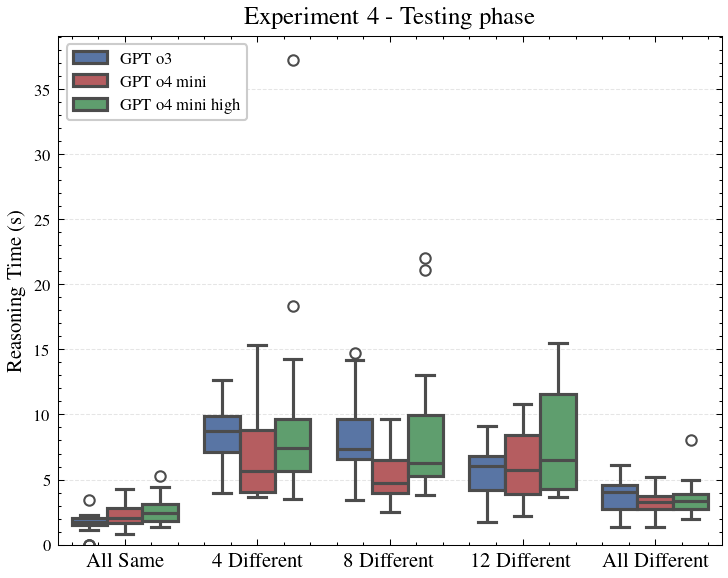

In [192]:
# Assuming df_exp3 is already loaded in your environment

df_test = df_exp4[df_exp4['Split'] == 'test']

# 1. Filter only the reasoning models
reasoning_models = ['GPT_o3', 'GPT_o4_mini', 'GPT_o4_mini_high']
df_time = df_test[df_test['Model'].isin(reasoning_models)].copy()

# 2. Convert reasoning time from milliseconds to seconds
df_time['Reasoning_Time_sec'] = df_time['Razon time'] / 1000

# 3. Map numerical entropy to descriptive labels for the X-axis
entropy_map = {
    0: 'All Same',
    4: '4 Different',
    8: '8 Different',
    12: '12 Different',
    16: 'All Different'
}
df_time['Entropy_Label'] = df_time['Entropy'].map(entropy_map)

# Convert to a Categorical type to enforce the logical order on the X-axis
df_time['Entropy_Label'] = pd.Categorical(
    df_time['Entropy_Label'], 
    categories=['All Same', '4 Different', '8 Different', '12 Different', 'All Different'], 
    ordered=True
)

# 4. Calculate mean reasoning time per instance (Realization) and Entropy Level
# Note: Based on your screenshot, instances are under the 'Realization' column here
df_inst = df_time.groupby(['Model', 'Set', 'Instance', 'Entropy_Label'])['Reasoning_Time_sec'].mean().reset_index()

# Apply your custom formatting function to the model names
# (Assuming format_model_name is already defined in your environment)
df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- NUMERICAL SUMMARY ---
summary_time = df_inst.groupby(['Model', 'Entropy_Label'])['Reasoning_Time_sec'].agg(['mean', sem]).reset_index()
summary_time.rename(columns={'mean': 'Mean Time (s)', 'sem': 'Standard Error (s)'}, inplace=True)

print("--- MEAN REASONING TIME BY ENTROPY ---")
print(summary_time.round(2).to_string(index=False))
print("\n")

# --- PLOTTING ---

# 5. Configure the figure and style (strictly using your 5x4 format)
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid")

# 6. Create the Boxplot
# x: Entropy Levels, y: Reasoning Time, hue: Models
ax = sns.boxplot(
    data=df_inst,
    x='Entropy_Label',
    y='Reasoning_Time_sec',
    hue='Model',
    palette=['#4C72B0', '#C44E52', '#55A868'], # Added a 3rd color (Green) for the 3rd model
    linewidth=1.5,
    fliersize=5 
)

# 7. Chart Customization
# Force the Y-axis to start at 0
plt.ylim(bottom=0)

# Rotate X labels slightly so they don't overlap (since there are 5 categories now)
plt.xticks(fontsize=10)#rotation=45, ha='right')

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', loc='upper left')

# Clear the X label and set the custom titles
plt.xlabel("")
plt.ylabel("Reasoning Time (s)", fontsize=10)
plt.title('Experiment 4 - Testing phase', fontsize=12)

plt.tight_layout()
plt.savefig('reasoning_time_exp_4.pdf', bbox_inches='tight')
plt.show()

## Learning

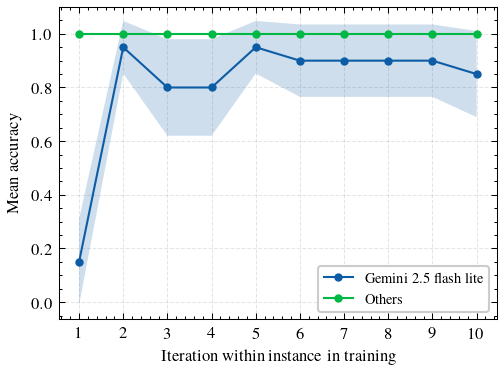

In [43]:
# Si deseas filtrar modelos, define: TARGET_MODELS = ["GPT_o3_mini", "Gemini_2_5_flash_lite"]
TARGET_MODELS = ["Gemini_2_5_flash_lite"] #"None  # o lista de modelos

df = exp_4_df #pd.read_csv(CSV_PATH)

# Columnas mínimas
req = ["Model","Split","Instance","Answer","Correct","File"]
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas: {missing}")

# Filtra train
dt = df[df["Split"].str.lower()=="train"].copy()

# (Opcional) filtra modelos
#if TARGET_MODELS:
#    dt = dt[dt["Model"].isin(TARGET_MODELS)].copy()

# Extrae la iteración dentro de la instancia desde 'File' (número del nombre: "01t.png" -> 1)
def extract_iter(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan

dt["Iter"] = dt["File"].apply(extract_iter).astype("Int64")
dt = dt.dropna(subset=["Iter"]).copy()
dt["Iter"] = dt["Iter"].astype(int)

# Correctitud
dt["IsCorrect"] = (
    dt["Answer"].astype(str).str.lower()
    == dt["Correct"].astype(str).str.lower()
).astype(int)

# Agrupa modelos: TARGET_MODELS conservan su nombre; el resto -> "Others"
dt["ModelGroup"] = np.where(dt["Model"].isin(TARGET_MODELS), dt["Model"], "Others")

# Agrega por (Model, Iter) promediando a través de todas las instancias (sujetos)
agg = (
    dt.groupby(["ModelGroup","Iter"])
      .agg(mean_acc=("IsCorrect","mean"),
           sd=("IsCorrect","std"),
           n=("IsCorrect","count"))
      .reset_index()
)
agg["se"] = agg["sd"] / np.sqrt(agg["n"]).replace(0, np.nan)
agg["lo"] = agg["mean_acc"] - 1.96*agg["se"]
agg["hi"] = agg["mean_acc"] + 1.96*agg["se"]

# Orden de trazado: GPT_o3_mini, Gemini_2_5_flash_lite, Others (si existen)
order = [m for m in TARGET_MODELS if m in agg["ModelGroup"].unique()] + \
        (["Others"] if "Others" in agg["ModelGroup"].unique() else [])

# Gráfico: evolución por iteración (1–10) promedio entre sujetos
plt.figure()
for model in order:
    g = agg[agg["ModelGroup"] == model].sort_values("Iter")
    if g.empty: 
        continue
    model = format_model_name(model)
    plt.plot(g["Iter"], g["mean_acc"], ".-", label=str(model))
    plt.fill_between(g["Iter"], g["lo"], g["hi"], alpha=0.2)

plt.xlabel("Iteration within instance in training")#"Iteración dentro de la instancia (1–10, train)")
plt.ylabel("Mean accuracy")
plt.xticks(g["Iter"])
#plt.title("Curva de aprendizaje por iteración (promedio entre sujetos)")
plt.legend(fontsize=7)#title="Model")
plt.tight_layout()
#plt.savefig(exp_4_path + "learning_curve_by_iteration_train.png", dpi=150)
#print("Guardado: learning_curve_by_iteration_train.png")


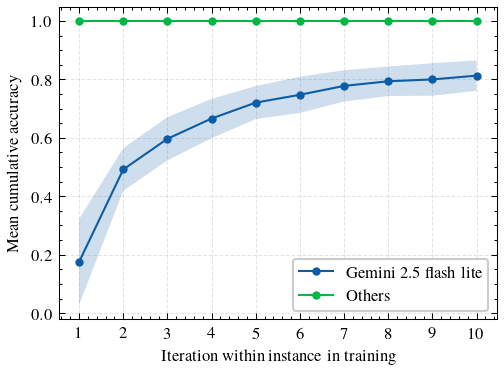

In [44]:
# Cumulative learning curve by iteration, grouping all non-target models under a single label "Others"
# Requirements: pandas, numpy, matplotlib

TARGET_MODELS = ["Gemini_2_5_flash_lite"]

df = exp_4_df

# Columnas mínimas
req = ["Model","Split","Instance","Answer","Correct","File"]
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Solo train
dt = df[df["Split"].str.lower()=="train"].copy()

# Iteración dentro de la instancia desde 'File' (e.g., "01t.png" -> 1)
def extract_iter(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan

dt["Iter"] = dt["File"].apply(extract_iter).astype("Int64")
dt = dt.dropna(subset=["Iter"]).copy()
dt["Iter"] = dt["Iter"].astype(int)

# Correctitud binaria
dt["IsCorrect"] = (
    dt["Answer"].astype(str).str.lower()
    == dt["Correct"].astype(str).str.lower()
).astype(int)

# Cálculo acumulado dentro de cada instancia (sujeto)
dt = dt.sort_values(["Model","Instance","Iter"])
dt["t"] = dt.groupby(["Model","Instance"]).cumcount() + 1
dt["cum_correct"] = dt.groupby(["Model","Instance"])["IsCorrect"].cumsum()
dt["cum_acc"] = dt["cum_correct"] / dt["t"]

# Agrupa modelos: TARGET_MODELS conservan su nombre; el resto -> "Others"
dt["ModelGroup"] = np.where(dt["Model"].isin(TARGET_MODELS), dt["Model"], "Others")

# Promedio entre instancias por iteración dentro de cada grupo
agg = (
    dt.groupby(["ModelGroup","Iter"])
      .agg(mean_cum_acc=("cum_acc","mean"),
           sd=("cum_acc","std"),
           n=("cum_acc","count"))
      .reset_index()
)
agg["se"] = agg["sd"] / np.sqrt(agg["n"]).replace(0, np.nan)
agg["lo"] = agg["mean_cum_acc"] - 1.96*agg["se"]
agg["hi"] = agg["mean_cum_acc"] + 1.96*agg["se"]

# Orden de trazado: GPT_o3_mini, Gemini_2_5_flash_lite, Others (si existen)
order = [m for m in TARGET_MODELS if m in agg["ModelGroup"].unique()] + \
        (["Others"] if "Others" in agg["ModelGroup"].unique() else [])

# Gráfico
plt.figure()
for model in order:
    g = agg[agg["ModelGroup"] == model].sort_values("Iter")
    if g.empty: 
        continue
    model = format_model_name(model)
    plt.plot(g["Iter"], g["mean_cum_acc"], ".-", label=str(model))
    plt.fill_between(g["Iter"], g["lo"], g["hi"], alpha=0.2)
plt.xlabel("Iteration within instance in training")
plt.xticks(g["Iter"])
plt.ylabel("Mean cumulative accuracy")
#plt.title("Cumulative learning curve by iteration (average across subjects)")
plt.legend()#title="Model")
plt.tight_layout()
#plt.savefig(exp_4_path+"cumulative_learning_curve_by_iteration_grouped.png", dpi=150)

# (Opcional) exporta tabla
#agg.to_csv("cumulative_learning_curve_by_iteration_grouped.csv", index=False)
#print("Saved: cumulative_learning_curve_by_iteration_grouped.png and .csv")


In [115]:
def create_accuracy_df(df):
    # Calculate accuracy for each model across both sets
    accuracy_by_model = df.groupby('Model')['Answer'].apply(lambda x: (x == df.loc[x.index, 'Correct']).mean()).reset_index(name='Accuracy')
    
    # Calculate the count of data points for each model
    data_counts_by_model = df.groupby('Model').size().reset_index(name='Count')
    
    # Merge accuracy and counts
    accuracy_stats_by_model = pd.merge(accuracy_by_model, data_counts_by_model, on='Model')
    
    # Calculate standard deviation using the formula 1.96 * sqrt(p * (1-p) / n)
    # Confianza al 95%
    accuracy_stats_by_model['IC'] = 1.96*np.sqrt(accuracy_stats_by_model['Accuracy'] * (1 - accuracy_stats_by_model['Accuracy']) / accuracy_stats_by_model['Count'])
    
    print("Accuracy and Standard Deviation by Model (Sets A and B combined):")
    display(accuracy_stats_by_model)

    return accuracy_stats_by_model

In [116]:
exp_4_df_train = exp_4_df[~exp_4_df["Split"].fillna("").str.lower().eq("test")]
accuracy_exp_4 = create_accuracy_df(exp_4_df_train)

Accuracy and Standard Deviation by Model (Sets A and B combined):


,Model,Accuracy,Count,IC
0,GPT_4o,1.00,200,0.00000
1,GPT_o3,1.00,200,0.00000
2,GPT_o4_mini,1.00,200,0.00000
3,GPT_o4_mini_high,1.00,200,0.00000
4,Gemini_2_0_flash,1.00,200,0.00000
5,Gemini_2_5_flash,1.00,200,0.00000
6,Gemini_2_5_flash_lite,0.81,200,0.05437


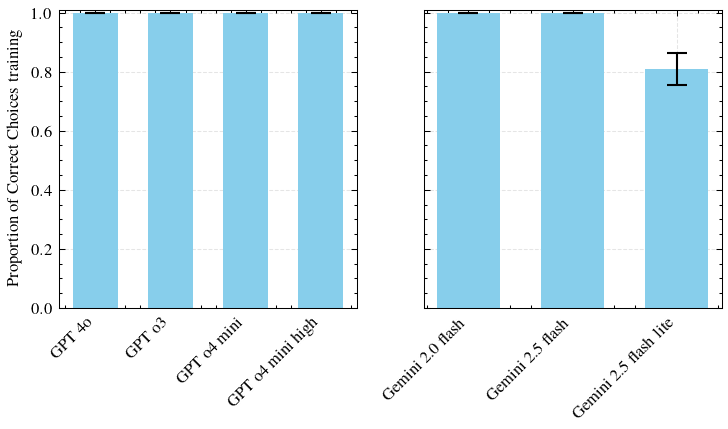

In [117]:
###################### Accuracy plots ################################

# Filter data for GPT models
gpt_accuracy_stats_exp_4 = accuracy_exp_4[accuracy_exp_4['Model'].str.contains('GPT')].copy()

# Filter data for Gemini models
gemini_accuracy_stats_exp_4 = accuracy_exp_4[accuracy_exp_4['Model'].str.contains('Gemini')].copy()


# Apply formatting to model names
gpt_accuracy_stats_exp_4['Model'] = gpt_accuracy_stats_exp_4['Model'].apply(format_model_name)
gemini_accuracy_stats_exp_4['Model'] = gemini_accuracy_stats_exp_4['Model'].apply(format_model_name)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(5, 3))#, figsize=(16, 6)) # Share y-axis

# Set a single title for the entire figure and adjust its vertical position
#fig.suptitle('Experiments 1 and 2', y=0.95) # Adjusted y value again

# Create a bar plot for GPT models on the left subplot
bar_width = 0.6
gpt_models = gpt_accuracy_stats_exp_4['Model'].unique()
x = np.arange(len(gpt_models))

# Create a bar plot for GPT models on the left subplot
axes[0].bar(x, gpt_accuracy_stats_exp_4['Accuracy'], bar_width, yerr=gpt_accuracy_stats_exp_4['IC'], capsize=5, color='skyblue')

#axes[0].set_xlabel('GPT')
axes[0].set_ylabel('Proportion of Correct Choices training')
# Removed individual subplot title: axes[0].set_title('Experiment 1 - GPT Models\n2-item AMTS')
axes[0].set_ylim(0, 1) # Accuracy is between 0 and 1
axes[0].set_xticks(x)
axes[0].set_xticklabels(gpt_models, rotation=45, ha='right')
#axes[0].legend()

gemini_models = gemini_accuracy_stats_exp_4['Model'].unique()
x = np.arange(len(gemini_models))

# Create a bar plot for Gemini models on the right subplot
axes[1].bar(x, gemini_accuracy_stats_exp_4['Accuracy'], bar_width, yerr=gemini_accuracy_stats_exp_4['IC'], capsize=5, color='skyblue')
#axes[1].set_xlabel('Gemini')
# axes[1].set_ylabel('Proportion of Correct Choices') # Removed duplicate y-label
# Removed individual subplot title: axes[1].set_title('Experiment 1 - Gemini Models\n2-item AMTS')
axes[1].set_ylim(0, 1.01) # Removed duplicate y-limit
axes[1].set_xticks(x)
axes[1].set_xticklabels(gemini_models, rotation=45, ha='right')
#axes[1].legend()

# Posible explicacion a flash lite: Eventos dependientes del mismo sujeto
plt.tight_layout()#rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap

#plt.savefig(exp_4_path+"Prop_correct_choices_training.png")
plt.show()

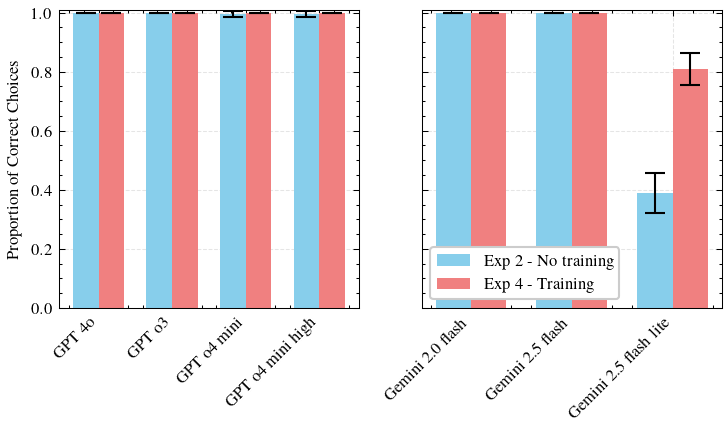

In [118]:
###################### Accuracy plots ################################

# Filter data for GPT models
gpt_accuracy_stats_exp_1 = accuracy_exp_1[accuracy_exp_1['Model'].str.contains('GPT')].copy()
gpt_accuracy_stats_exp_2 = accuracy_exp_2[accuracy_exp_2['Model'].str.contains('GPT')].copy()
gpt_accuracy_stats_exp_4 = accuracy_exp_4[accuracy_exp_4['Model'].str.contains('GPT')].copy()

# Filter data for Gemini models
gemini_accuracy_stats_exp_1 = accuracy_exp_1[accuracy_exp_1['Model'].str.contains('Gemini')].copy()
gemini_accuracy_stats_exp_2 = accuracy_exp_2[accuracy_exp_2['Model'].str.contains('Gemini')].copy()
gemini_accuracy_stats_exp_4 = accuracy_exp_4[accuracy_exp_4['Model'].str.contains('Gemini')].copy()

# Apply formatting to model names
gpt_accuracy_stats_exp_1['Model'] = gpt_accuracy_stats_exp_1['Model'].apply(format_model_name)
gemini_accuracy_stats_exp_1['Model'] = gemini_accuracy_stats_exp_1['Model'].apply(format_model_name)

gpt_accuracy_stats_exp_2['Model'] = gpt_accuracy_stats_exp_2['Model'].apply(format_model_name)
gemini_accuracy_stats_exp_2['Model'] = gemini_accuracy_stats_exp_2['Model'].apply(format_model_name)

gpt_accuracy_stats_exp_4['Model'] = gpt_accuracy_stats_exp_4['Model'].apply(format_model_name)
gemini_accuracy_stats_exp_4['Model'] = gemini_accuracy_stats_exp_4['Model'].apply(format_model_name)


# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(5, 3))#, figsize=(16, 6)) # Share y-axis

# Set a single title for the entire figure and adjust its vertical position
#fig.suptitle('Experiments 1 and 2', y=0.95) # Adjusted y value again

# Create a bar plot for GPT models on the left subplot
bar_width = 0.35
gpt_models = gpt_accuracy_stats_exp_4['Model'].unique()
x = np.arange(len(gpt_models))

# Create a bar plot for GPT models on the left subplot
axes[0].bar(x - bar_width/2, gpt_accuracy_stats_exp_2['Accuracy'], bar_width, label="Exp 2 - No training", yerr=gpt_accuracy_stats_exp_2['IC'], capsize=5, color='skyblue')
axes[0].bar(x + bar_width/2, gpt_accuracy_stats_exp_4['Accuracy'], bar_width, label="Exp 4 - Training", yerr=gpt_accuracy_stats_exp_4['IC'], capsize=5, color='lightcoral')

#axes[0].set_xlabel('GPT')
axes[0].set_ylabel('Proportion of Correct Choices')
# Removed individual subplot title: axes[0].set_title('Experiment 1 - GPT Models\n2-item AMTS')
axes[0].set_ylim(0, 1) # Accuracy is between 0 and 1
axes[0].set_xticks(x)
axes[0].set_xticklabels(gpt_models, rotation=45, ha='right')
#axes[0].legend()

gemini_models = gemini_accuracy_stats_exp_4['Model'].unique()
x = np.arange(len(gemini_models))

# Create a bar plot for Gemini models on the right subplot
axes[1].bar(x - bar_width/2, gemini_accuracy_stats_exp_2['Accuracy'], bar_width, label="Exp 2 - No training", yerr=gemini_accuracy_stats_exp_2['IC'], capsize=5, color='skyblue')
axes[1].bar(x + bar_width/2, gemini_accuracy_stats_exp_4['Accuracy'], bar_width, label="Exp 4 - Training", yerr=gemini_accuracy_stats_exp_4['IC'], capsize=5, color='lightcoral')


#axes[1].set_xlabel('Gemini')
# axes[1].set_ylabel('Proportion of Correct Choices') # Removed duplicate y-label
# Removed individual subplot title: axes[1].set_title('Experiment 1 - Gemini Models\n2-item AMTS')
axes[1].set_ylim(0, 1.01) # Removed duplicate y-limit
axes[1].set_xticks(x)
axes[1].set_xticklabels(gemini_models, rotation=45, ha='right')
axes[1].legend()

# Posible explicacion a flash lite: Eventos dependientes del mismo sujeto
plt.tight_layout()#rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap

#plt.savefig(plot_save_path+"Prop_correct_choices_exp_2_&_4.png")
plt.show()

In [119]:
df_o3_mini_exp_2 = gpt_accuracy_stats_exp_2[gpt_accuracy_stats_exp_2["Model"].eq("GPT o3 mini")]
df_2_5_fls_lt_exp_2 = gemini_accuracy_stats_exp_2[gemini_accuracy_stats_exp_2["Model"].eq("Gemini 2.5 flash lite")]
df_o3_mini_exp_4 = gpt_accuracy_stats_exp_4[gpt_accuracy_stats_exp_4["Model"].eq("GPT o3 mini")]
df_2_5_fls_lt_exp_4 = gemini_accuracy_stats_exp_4[gemini_accuracy_stats_exp_4["Model"].eq("Gemini 2.5 flash lite")]

In [120]:
np.append(df_o3_mini_exp_2["Accuracy"], df_o3_mini_exp_4["Accuracy"])

array([], dtype=float64)

In [121]:
np.append(df_2_5_fls_lt_exp_2["Accuracy"], df_2_5_fls_lt_exp_4["Accuracy"])

array([0.39, 0.81])

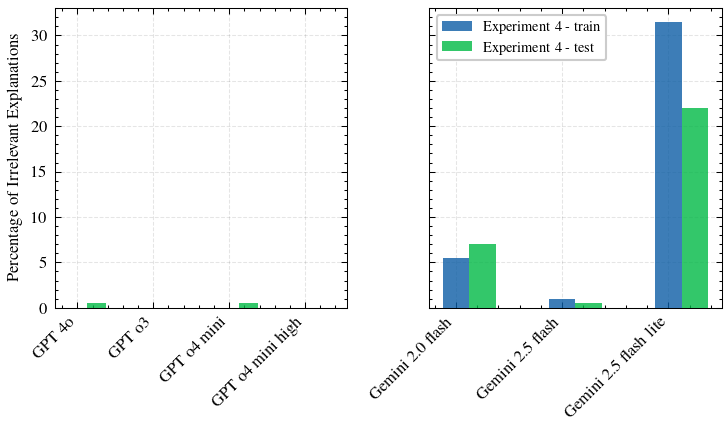

In [122]:
# Calcular porcentaje de respuestas irrelevantes (Relevance == 0) por modelo
gpt_exp_4 = exp_4_df[exp_4_df['Model'].str.contains('GPT')].copy()
gpt_exp_4_test = gpt_exp_4[gpt_exp_4['Split']=="test"]
gpt_exp_4_train = gpt_exp_4[gpt_exp_4['Split']=="train"]

gemini_exp_4 = exp_4_df[exp_4_df['Model'].str.contains('Gemini')].copy()
gemini_exp_4_test = gemini_exp_4[gemini_exp_4['Split']=="test"]
gemini_exp_4_train = gemini_exp_4[gemini_exp_4['Split']=="train"]


rlv_gpt_exp_4_test = (
    gpt_exp_4_test.groupby("Model")["Relevance"]
      .apply(lambda x: (x == 0).mean() * 100)
      .reset_index(name="Irrelevant (%)")
)

rlv_gpt_exp_4_train = (
    gpt_exp_4_train.groupby("Model")["Relevance"]
      .apply(lambda x: (x == 0).mean() * 100)
      .reset_index(name="Irrelevant (%)")
)


rlv_gemini_exp_4_test = (
    gemini_exp_4_test.groupby("Model")["Relevance"]
      .apply(lambda x: (x == 0).mean() * 100)
      .reset_index(name="Irrelevant (%)")
)

rlv_gemini_exp_4_train = (
    gemini_exp_4_train.groupby("Model")["Relevance"]
      .apply(lambda x: (x == 0).mean() * 100)
      .reset_index(name="Irrelevant (%)")
)


# Apply formatting to model names
rlv_gpt_exp_4_test['Model'] = rlv_gpt_exp_4_test['Model'].apply(format_model_name)
rlv_gpt_exp_4_train['Model'] = rlv_gpt_exp_4_train['Model'].apply(format_model_name)

rlv_gemini_exp_4_test['Model'] = rlv_gemini_exp_4_test['Model'].apply(format_model_name)
rlv_gemini_exp_4_train['Model'] = rlv_gemini_exp_4_train['Model'].apply(format_model_name)


bar_width = 0.25
gpt_models = rlv_gpt_exp_4_test['Model'].unique()
gemini_models = rlv_gemini_exp_4_test['Model'].unique()
models = np.append(gpt_models, gemini_models)

x_gpt = np.arange(len(gpt_models))
x_gemini = np.arange(len(gemini_models))

# Graficar
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(5, 3))

axes[0].bar(x_gpt, rlv_gpt_exp_4_train["Irrelevant (%)"], bar_width, label="Train", zorder=3, alpha=0.8)
axes[0].bar(x_gpt + bar_width, rlv_gpt_exp_4_test["Irrelevant (%)"], bar_width, label="Test", zorder=3, alpha=0.8)#, color="#1f77b4")#, color="#ff7f0e")

#axes[0].set_xlabel('GPT')
axes[0].set_ylabel("Percentage of Irrelevant Explanations")
# Removed individual subplot title: axes[0].set_title('Experiment 1 - GPT Models\n2-item AMTS')
axes[0].set_xticks(x_gpt)
axes[0].set_xticklabels(gpt_models, rotation=45, ha='right')
#axes[0].legend(fontsize=7)

axes[1].bar(x_gemini, rlv_gemini_exp_4_train["Irrelevant (%)"], bar_width, label="Experiment 4 - train", zorder=3, alpha=0.8)
axes[1].bar(x_gemini + bar_width, rlv_gemini_exp_4_test["Irrelevant (%)"], bar_width, label="Experiment 4 - test", zorder=3, alpha=0.8)#, color="#1f77b4")#, color="#ff7f0e")
axes[1].set_xticks(x_gemini)
axes[1].set_xticklabels(gemini_models, rotation=45, ha='right')
axes[1].legend(fontsize=7)

plt.tight_layout()

#plt.savefig(plot_save_path+"Perc_irrelevant_exp_4.png")
plt.show()

## Proportions - training

In [185]:
# Asumimos que tu dataframe se llama 'exp_1_df'
# Hacemos una copia para no alterar el original accidentalmente
df = exp_4_df[exp_4_df['Split'] == 'train'].copy()

# --- LÓGICA PARA CREAR LAS INSTANCIAS ---
# Agrupamos por 'Model' y 'Set'. Esto aísla los datos de cada grupo.
# 'cumcount()' cuenta las filas: 0, 1, 2... 9, 10, 11... dentro de cada grupo.
# Al dividir por 10 (división entera //), obtenemos: 0, 0... 1, 1...
# Sumamos 1 para que las instancias empiecen en 1 y no en 0.

#df['Instance_ID'] = df.groupby(['Model', 'Set']).cumcount() // 10 + 1

# VERIFICACIÓN (Opcional pero recomendada)
# Comprobamos que el modelo especial 'GPT_o4_mini' tenga sus instancias bien creadas
# y que un modelo normal también.
print("Verificación de instancias generadas:")
print(df[['Model', 'Set', 'Instance']].head(130)) # Ver el inicio (Modelo normal)
print(df[df['Model'] == 'GPT_o4_mini'][['Model', 'Set', 'Instance']].tail(30)) # Ver el especial

Verificación de instancias generadas:
      Model Set  Instance
0    GPT_4o   A         1
1    GPT_4o   A         1
2    GPT_4o   A         1
3    GPT_4o   A         1
4    GPT_4o   A         1
..      ...  ..       ...
245  GPT_o3   A         3
246  GPT_o3   A         3
247  GPT_o3   A         3
248  GPT_o3   A         3
249  GPT_o3   A         3

[130 rows x 3 columns]
            Model Set  Instance
2740  GPT_o4_mini   B         8
2741  GPT_o4_mini   B         8
2742  GPT_o4_mini   B         8
2743  GPT_o4_mini   B         8
2744  GPT_o4_mini   B         8
2745  GPT_o4_mini   B         8
2746  GPT_o4_mini   B         8
2747  GPT_o4_mini   B         8
2748  GPT_o4_mini   B         8
2749  GPT_o4_mini   B         8
2760  GPT_o4_mini   B         9
2761  GPT_o4_mini   B         9
2762  GPT_o4_mini   B         9
2763  GPT_o4_mini   B         9
2764  GPT_o4_mini   B         9
2765  GPT_o4_mini   B         9
2766  GPT_o4_mini   B         9
2767  GPT_o4_mini   B         9
2768  GPT_o4_mini 

               Modelo Promedio A Promedio B            IC 95% A            IC 95% B
               GPT_4o    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
               GPT_o3    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
          GPT_o4_mini    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
     GPT_o4_mini_high    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
     Gemini_2_0_flash    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
     Gemini_2_5_flash    100.00%    100.00% [100.00% - 100.00%] [100.00% - 100.00%]
Gemini_2_5_flash_lite     82.00%     80.00%   [69.03% - 94.97%]   [67.84% - 92.16%]


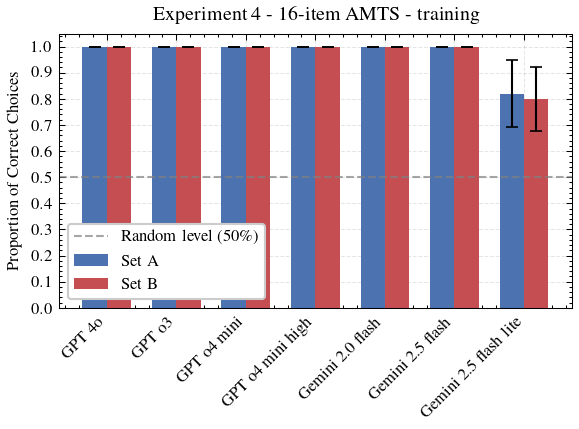

In [186]:
# ---------------------------------------------------------
# 1. PREPARACIÓN Y AGRUPACIÓN DE DATOS
# ---------------------------------------------------------
# 'df' es tu dataframe original de los experimentos 1 y 2
# Convertimos las columnas a string por seguridad al comparar

df['Result'] = (df['Answer'].astype(str) == df['Correct'].astype(str)).astype(int)

# Calculamos el promedio de aciertos por Instancia (10 notas por modelo y set)
df_agrupado = df.groupby(['Model', 'Set', 'Instance'])['Result'].mean().reset_index()
df_agrupado.rename(columns={'Result': 'Score_Instancia'}, inplace=True)

resultados_mw = []

# Listas para guardar los datos para el gráfico
modelos = []
means_a = []
means_b = []
err_lower_a = []
err_upper_a = []
err_lower_b = []
err_upper_b = []

# Nivel de confianza para el intervalo (95%)
confidence = 0.95

# ---------------------------------------------------------
# 2. CÁLCULO ESTADÍSTICO POR MODELO
# ---------------------------------------------------------
for modelo in df_agrupado['Model'].unique():
    datos_modelo = df_agrupado[df_agrupado['Model'] == modelo]
    
    scores_a = datos_modelo[datos_modelo['Set'] == 'A']['Score_Instancia'].values
    scores_b = datos_modelo[datos_modelo['Set'] == 'B']['Score_Instancia'].values
    
    if len(scores_a) > 0 and len(scores_b) > 0:
        # Prueba de Mann-Whitney
        #stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
        
        # Promedios
        mean_a = scores_a.mean()
        mean_b = scores_b.mean()
        
        # Cálculo del Margen de Error (Intervalo de Confianza 95%)
        # Usamos la distribución t de Student porque n=10 es una muestra pequeña
        n_a, n_b = len(scores_a), len(scores_b)
        
        # Margen de error A
        std_err_a = sem(scores_a) if n_a > 1 else 0
        margin_a = std_err_a * t.ppf((1 + confidence) / 2., n_a - 1) if std_err_a > 0 else 0
        
        # Margen de error B
        std_err_b = sem(scores_b) if n_b > 1 else 0
        margin_b = std_err_b * t.ppf((1 + confidence) / 2., n_b - 1) if std_err_b > 0 else 0
        
        # Recortar (Clip) los intervalos para que no pasen de 1.0 (100%) ni bajen de 0.0 (0%)
        # Matplotlib requiere la *distancia* desde la media, no los valores absolutos
        lower_err_a = mean_a - max(0.0, mean_a - margin_a)
        upper_err_a = min(1.0, mean_a + margin_a) - mean_a
        
        lower_err_b = mean_b - max(0.0, mean_b - margin_b)
        upper_err_b = min(1.0, mean_b + margin_b) - mean_b
        
        # Guardar para el dataframe
        resultados_mw.append({
            'Modelo': modelo,
            'Promedio A': f"{mean_a:.2%}",
            'Promedio B': f"{mean_b:.2%}",
            'IC 95% A': f"[{mean_a-lower_err_a:.2%} - {mean_a+upper_err_a:.2%}]",
            'IC 95% B': f"[{mean_b-lower_err_b:.2%} - {mean_b+upper_err_b:.2%}]",
            #'Valor p (MW)': round(p_valor, 4),
            #'Significativo': 'SÍ' if p_valor < 0.05 else 'NO'
        })
        
        # Guardar para el gráfico
        modelos.append(format_model_name(modelo))
        means_a.append(mean_a)# * 100) # Convertimos a % para el gráfico
        means_b.append(mean_b)# * 100)
        err_lower_a.append(lower_err_a)# * 100)
        err_upper_a.append(upper_err_a)# * 100)
        err_lower_b.append(lower_err_b)# * 100)
        err_upper_b.append(upper_err_b)# * 100)

# Mostrar la tabla final
df_final = pd.DataFrame(resultados_mw)
print(df_final.to_string(index=False))


# ---------------------------------------------------------
# 3. GENERACIÓN DEL GRÁFICO DE BARRAS AGRUPADAS
# ---------------------------------------------------------
# Configuración del estilo general
plt.figure(figsize=(4, 3))
x = np.arange(len(modelos))  # Posiciones en el eje X
width = 0.35  # Ancho de las barras

# Crear los arrays de error asimétrico para matplotlib (forma: [errores_inferiores, errores_superiores])
yerr_a = [err_lower_a, err_upper_a]
yerr_b = [err_lower_b, err_upper_b]

# Dibujar las barras
bars1 = plt.bar(x - width/2, means_a, width, label='Set A', color='#4C72B0', 
                yerr=yerr_a, capsize=3)#, error_kw={'elinewidth':1.5, 'capthick':1.5})
bars2 = plt.bar(x + width/2, means_b, width, label='Set B', color='#C44E52', 
                yerr=yerr_b, capsize=3)#, error_kw={'elinewidth':1.5, 'capthick':1.5})

# Personalización del gráfico
plt.ylabel('Proportion of Correct Choices')#, fontsize=12)
plt.title('Experiment 4 - 16-item AMTS - training')#, fontsize=14, pad=15)
plt.xticks(x, modelos, rotation=45, ha='right') #fontsize=11)
plt.ylim(0, 1.05) # Límite en 105 para que la barra de error del 100% se vea bien
plt.yticks(np.arange(0, 1.01, .1))

# Línea horizontal tenue en el 50% (nivel de azar)
plt.axhline(y=.5, color='gray', linestyle='--', alpha=0.7, label=R'Random level (50\%)')

plt.legend()#loc='upper right')#, fontsize=11)
plt.tight_layout() # Ajusta los márgenes para que no se corten los nombres largos


# Guardar la imagen (ideal para el paper)
#plt.savefig('proportions_exp_1.pdf', dpi=300, bbox_inches='tight')
#print("\nGráfico guardado como 'grafico_desempeno_modelos.png'")

Boxplot guardado exitosamente como 'boxplot_precision_modelos.png'


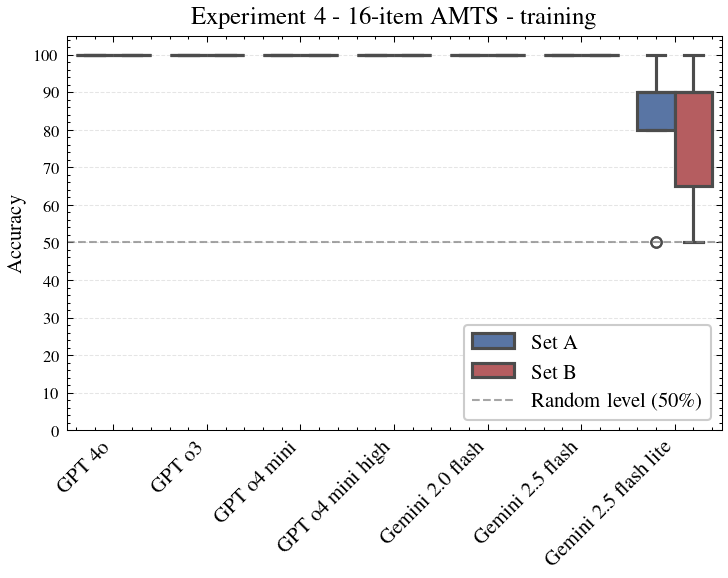

In [187]:
import seaborn as sns

# 1. Preparar los datos: Calcular si la respuesta fue correcta
# Convertimos a string por seguridad (para evitar problemas entre 'a' y 'A' o espacios)
df['Result'] = (df['Answer'].astype(str).str.strip().str.lower() == 
                df['Correct'].astype(str).str.strip().str.lower()).astype(int)

# 2. Calcular la precisión por cada instancia
# Agrupamos por Modelo, Set y la Instancia que creaste para sacar el promedio (0.0 a 1.0)
df_scores = df.groupby(['Model', 'Set', 'Instance'])['Result'].mean().reset_index()

# Multiplicamos por 100 para que el gráfico muestre porcentajes legibles (0 a 100)
df_scores['Accuracy'] = df_scores['Result'] * 100

df_scores['Model'] = df_scores['Model'].apply(format_model_name)

# 2. Renombrar las categorías del Set para que la leyenda se genere sola correctamente
df_scores['Set'] = df_scores['Set'].replace({'A': 'Set A', 'B': 'Set B'})

# 3. Configurar la figura y el estilo
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid") # Fondo blanco con líneas guía tenues, ideal para papers

# 4. Crear el Boxplot
# x: Modelos, y: Precisión, hue: Set (para poner la caja de Set A junto a la de Set B)
ax = sns.boxplot(
    data=df_scores,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=['#4C72B0', '#C44E52'], # Azul y Rojo académico (mismos colores del barplot anterior)
    linewidth=1.5,
    fliersize=5 # Tamaño de los puntos atípicos (outliers)
)

# 5. Personalización del gráfico
#plt.title('Distribución de Precisión por Modelo e Instancia (Set A vs. Set B)', fontsize=16, pad=20, fontweight='bold')
#plt.xlabel('Modelo', fontsize=13, labelpad=10)
#plt.ylabel('Precisión por Instancia (%)', fontsize=13, labelpad=10)

# Limitar el eje Y estrictamente de 0 a 100 (con un pequeño margen visual)
plt.ylim(0, 105)
plt.yticks(range(0, 101, 10))

# Rotar nombres de modelos si son muy largos
plt.xticks(rotation=45, ha='right', fontsize=10)

# Línea de referencia del nivel de azar (50%)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label=r'Random level (50\%)')

# Ajustar la leyenda
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', loc='lower right', fontsize=10)

plt.xlabel("")
plt.title('Experiment 4 - 16-item AMTS - training', fontsize=12)
plt.ylabel("Accuracy", fontsize=10)
plt.tight_layout()

# Guardar la imagen
#plt.savefig('boxplot_exp_4.pdf', dpi=300, bbox_inches='tight')
print("Boxplot guardado exitosamente como 'boxplot_precision_modelos.png'")

Barplot successfully saved as 'barplot_precision_modelos.png'


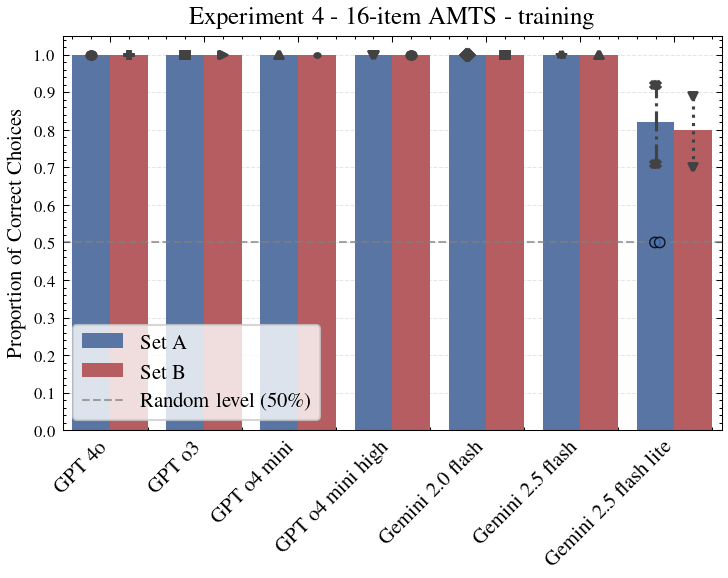

In [190]:
# 1. Prepare data: Calculate if the answer was correct
# Convert to string for safety (avoiding issues between 'a' and 'A' or spaces)
df['Result'] = (df['Answer'].astype(str).str.strip().str.lower() == 
                df['Correct'].astype(str).str.strip().str.lower()).astype(int)

# 2. Calculate accuracy per instance
# Group by Model, Set, and Instance_ID to get the mean (0.0 to 1.0)
df_scores = df.groupby(['Model', 'Set', 'Instance'])['Result'].mean().reset_index()

# Multiply by 100 so the plot shows readable percentages (0 to 100)
df_scores['Accuracy'] = df_scores['Result'] #* 100

df_scores['Model'] = df_scores['Model'].apply(format_model_name)

# Rename Set categories so the legend generates correctly
df_scores['Set'] = df_scores['Set'].replace({'A': 'Set A', 'B': 'Set B'})

# --- CALCULATE OUTLIERS EXPLICITLY ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

# Flag the outliers grouping by Model and Set
df_scores['Is_Outlier'] = df_scores.groupby(['Model', 'Set'])['Accuracy'].transform(check_outliers)

# Create a separate dataframe containing ONLY the outliers
df_outliers = df_scores[df_scores['Is_Outlier']].copy()
# -------------------------------------

# --- STRICT ORDERING DEFINITIONS ---
# Extract the exact list of models and sets to force Seaborn to keep the layout consistent
model_order = df_scores['Model'].unique().tolist()
set_order = ['Set A', 'Set B']
# -----------------------------------

# 3. Configure figure and style
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid") # White background with faint gridlines, ideal for papers

palette = ['#4C72B0', '#C44E52'] # Academic Blue and Red

# 4. Create the Barplot
# x: Models, y: Accuracy, hue: Set
ax = sns.barplot(
    data=df_scores,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=palette,
    
    # *** CRITICAL FIX FOR COLOR/POSITION ALIGNMENT ***
    order=model_order,
    hue_order=set_order,
    # *************************************************
    
    errorbar=('ci', 95),    # Standard Error
    capsize=0.05,     # Horizontal caps on the error bars
    err_kws={'linewidth': 1.5},
    #alpha=0.9
)

# Overlay ONLY the colored outliers
sns.stripplot(
    data=df_outliers,
    x='Model',
    y='Accuracy',
    hue='Set',
    palette=palette,
    
    # *** FORCING ALIGNMENT WITH BARPLOT ***
    order=model_order,
    hue_order=set_order,
    # **************************************
    
    dodge=True,       
    jitter=True, 
    size=5, 
    linewidth=0.7,    
    edgecolor='black',
    alpha=0.8,
    ax=ax
)

# 5. Chart customization
# Limit Y axis strictly from 0 to 100 (with a small visual margin)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, .1))

# Rotate X labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Random level reference line (50%)
plt.axhline(y=.5, color='gray', linestyle='--', alpha=0.7, label=r'Random level (50\%)')

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
# The barplot adds 2 handles, the stripplot adds 2, and axhline adds 1 (Total: 5)
# We only want the first 2 (bars) and the last 1 (horizontal line)
final_handles = handles[:2] + [handles[-1]]
final_labels = labels[:2] + [labels[-1]]
plt.legend(handles=final_handles, labels=final_labels, title='', loc='lower left', fontsize=10, framealpha=.8)

plt.xlabel("")
plt.ylabel("Proportion of Correct Choices", fontsize=10)
plt.title('Experiment 4 - 16-item AMTS - training', fontsize=12)
plt.tight_layout()

# Save image
plt.savefig('props_exp_4.pdf', dpi=300, bbox_inches='tight')
print("Barplot successfully saved as 'barplot_precision_modelos.png'")

In [48]:
#df = exp_1_df.copy()

# 1. Preparación de variables (Igual que antes)
df['is_correct'] = (df['Answer'].astype(str) == df['Correct'].astype(str)).astype(int)
df['Cluster_ID'] = df['Model'] + "_" + df['Set'] + "_" + df['Instance'].astype(str)
df['Set_Binario'] = df['Set'].apply(lambda x: 1 if x == 'B' else 0)

resultados_finales = []

print("Calculando estadística robusta por modelo...")

for modelo in df['Model'].unique():
    data_modelo = df[df['Model'] == modelo].copy()
    
    # Verificamos si hay varianza CERO en alguno de los dos sets
    # (Ej: Set A tiene todo 100% bueno)
    var_por_set = data_modelo.groupby('Set')['is_correct'].var()
    tiene_varianza_cero = (var_por_set == 0).any()
    
    # --- CAMINO A: SI HAY DATOS PERFECTOS (Usar Mann-Whitney) ---
    if tiene_varianza_cero:
        # Agrupamos por instancia para obtener las 10 notas por set
        instancias = data_modelo.groupby(['Set', 'Instance'])['is_correct'].mean().reset_index()
        scores_a = instancias[instancias['Set'] == 'A']['is_correct'].values
        scores_b = instancias[instancias['Set'] == 'B']['is_correct'].values
        
        # Prueba U de Mann-Whitney (No paramétrica, ideal para este caso)
        # Nota: Si todos son idénticos (100% vs 100%), p-value será 1.0
        try:
            stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
        except ValueError:
            p_valor = 1.0 # Caso donde A y B son idénticos perfectos
            
        resultados_finales.append({
            'Modelo': modelo,
            'Metodo': 'Mann-Whitney (Por Instancia)',
            'P-Value': round(p_valor, 4),
            'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
            'Comentario': 'Usado por separación perfecta en datos'
        })

    # --- CAMINO B: SI HAY VARIANZA NORMAL (Usar GEE) ---
    else:
        try:
            gee_model = smf.gee("is_correct ~ Set_Binario", 
                                data=data_modelo, 
                                groups=data_modelo["Cluster_ID"],
                                family=sm.families.Binomial()).fit()
            
            p_valor = gee_model.pvalues['Set_Binario']
            
            resultados_finales.append({
                'Modelo': modelo,
                'Metodo': 'GEE (Modelo Mixto)',
                'P-Value': round(p_valor, 4),
                'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
                'Comentario': 'Análisis estándar'
            })
        except:
            # Fallback a Mann-Whitney si GEE falla por otra razón técnica
            instancias = data_modelo.groupby(['Set', 'Instance'])['is_correct'].mean().reset_index()
            scores_a = instancias[instancias['Set'] == 'A']['is_correct'].values
            scores_b = instancias[instancias['Set'] == 'B']['is_correct'].values
            stat, p_valor = mannwhitneyu(scores_a, scores_b, alternative='two-sided')
            
            resultados_finales.append({
                'Modelo': modelo,
                'Metodo': 'Mann-Whitney (Fallback)',
                'P-Value': round(p_valor, 4),
                'Significativo': 'SÍ' if p_valor < 0.05 else 'NO',
                'Comentario': 'GEE falló convergencia'
            })

# Mostrar tabla final
df_final = pd.DataFrame(resultados_finales)
print(df_final[['Modelo', 'Metodo', 'P-Value', 'Significativo', 'Comentario']].to_string(index=False))

Calculando estadística robusta por modelo...
               Modelo                       Metodo  P-Value Significativo                             Comentario
               GPT_4o Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
               GPT_o3 Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
     GPT_o4_mini_high Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
     Gemini_2_0_flash Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
Gemini_2_5_flash_lite           GEE (Modelo Mixto)   0.7895            NO                      Análisis estándar
     Gemini_2_5_flash Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos
          GPT_o4_mini Mann-Whitney (Por Instancia)   1.0000            NO Usado por separación perfecta en datos


# Comparisons

### Exps 1, 2 and 4

--- PERCENTAGE OF IRRELEVANT EXPLANATIONS ---
  Experiment                 Model  Mean Irrelevance (%)  Standard Error (%)
Experiment 1                GPT 4o                  12.0                3.74
Experiment 1                GPT o3                   1.5                0.82
Experiment 1           GPT o4 mini                   6.5                5.04
Experiment 1      GPT o4 mini high                   0.0                0.00
Experiment 1      Gemini 2.0 flash                  60.5               10.30
Experiment 1      Gemini 2.5 flash                   9.0                6.24
Experiment 1 Gemini 2.5 flash lite                  70.5                6.09
Experiment 2                GPT 4o                   2.5                2.50
Experiment 2                GPT o3                   0.0                0.00
Experiment 2           GPT o4 mini                   0.0                0.00
Experiment 2      GPT o4 mini high                   0.0                0.00
Experiment 2      Gemini 2.0 f

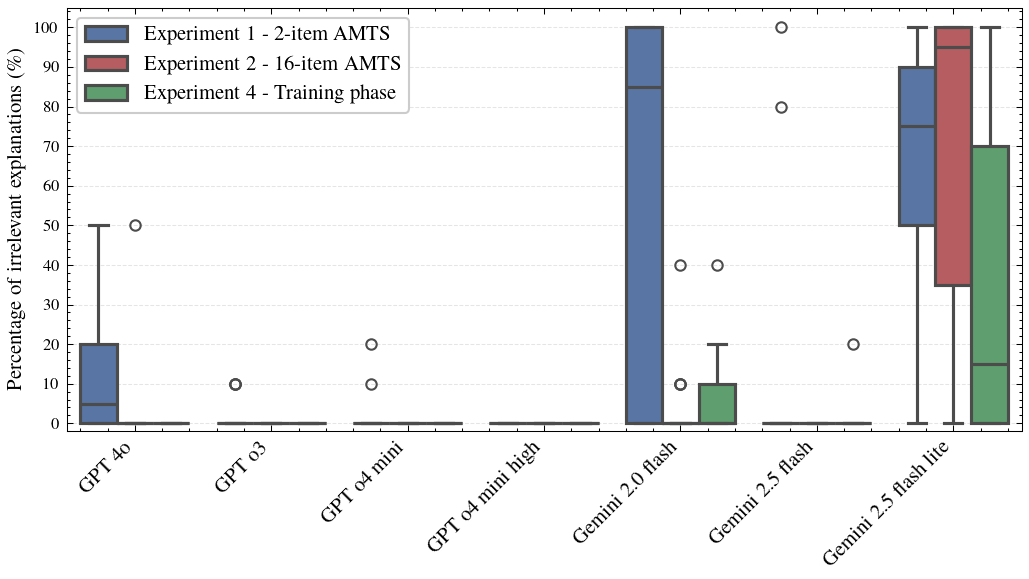

In [16]:
# Helper function to standardize column names across experiments
# Ensuring all dataframes use 'Instance_ID' instead of 'Realization'
def standardize_columns(df):
    df_clean = df.copy()
    if 'Instance' in df_clean.columns:
        df_clean = df_clean.rename(columns={'Instance': 'Instance_ID'})
    # We only keep the columns we actually need to avoid concatenation issues
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Relevance']
    return df_clean[cols_to_keep]

# 1. Prepare and filter dataframes individually
# Experiment 1
df1 = standardize_columns(df_exp1)
df1['Experiment'] = 'Experiment 1'

# Experiment 2 
df2 = standardize_columns(df_exp2) 
df2['Experiment'] = 'Experiment 2'

# Experiment 4
# We must filter by 'Split' == 'training' BEFORE standardizing, 
# because standardize_columns removes the 'Split' column.
df4_raw = df_exp4[df_exp4['Split'] == 'train'].copy()
df4 = standardize_columns(df4_raw)
df4['Experiment'] = 'Experiment 4'

# 2. Combine all dataframes
df_combined = pd.concat([df1, df2, df4], ignore_index=True)

# 3. Calculate Irrelevance
# If Relevance is 1 (relevant) or 0 (irrelevant), we flag the 0s
df_combined['Is_Irrelevant'] = (df_combined['Relevance'] == 0).astype(int)

# 4. Group by instance to get the percentage of irrelevant answers per instance
df_inst = df_combined.groupby(['Experiment', 'Model', 'Set', 'Instance_ID'])['Is_Irrelevant'].mean().reset_index()

# Convert proportion to percentage (0 to 100)
df_inst['Irrelevant_Pct'] = df_inst['Is_Irrelevant'] * 100

# Apply formatting to model names
# (Assuming format_model_name is already defined in your environment)
df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- NUMERICAL SUMMARY ---
summary_rel = df_inst.groupby(['Experiment', 'Model'])['Irrelevant_Pct'].agg(['mean', sem]).reset_index()
summary_rel.rename(columns={'mean': 'Mean Irrelevance (%)', 'sem': 'Standard Error (%)'}, inplace=True)

print("--- PERCENTAGE OF IRRELEVANT EXPLANATIONS ---")
print(summary_rel.round(2).to_string(index=False))
print("\n")

# --- PLOTTING ---

# 5. Configure the figure and style 
# Figure size (7, 4) to comfortably fit 3 boxes per model
plt.figure(figsize=(7, 4))
#sns.set_theme(style="whitegrid")

# 6. Create the Boxplot
ax = sns.boxplot(
    data=df_inst,
    x='Model',
    y='Irrelevant_Pct',
    hue='Experiment',
    palette=['#4C72B0', '#C44E52', '#55A868'], # Blue, Red, Green
    linewidth=1.5,
    fliersize=5
)

# 7. Chart Customization
# Limits from -2 to 105 to clearly see boxes that are exactly at 0%
plt.ylim(-2, 105)
plt.yticks(range(0, 101, 10))

# Rotate X labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Adjust the legend (Placed outside to prevent covering data)
handles, labels = ax.get_legend_handles_labels()
labels[0] = "Experiment 1 - 2-item AMTS" 
labels[1] = "Experiment 2 - 16-item AMTS" 
labels[-1] = "Experiment 4 - Training phase" 
plt.legend(handles=handles, labels=labels, title='', fontsize=10)

# Labels and title
plt.xlabel("")
plt.ylabel(r"Percentage of irrelevant explanations (\%)", fontsize=10)
#plt.title('Irrelevant Explanations Across Experiments', fontsize=12)

plt.tight_layout()
#plt.savefig('irrelevant_explanations_boxplot.pdf', bbox_inches='tight')
plt.show()

--- PERCENTAGE OF IRRELEVANT EXPLANATIONS ---
  Experiment                 Model  Mean Irrelevance (%)  Standard Error (%)
Experiment 1                GPT 4o                  12.0                3.74
Experiment 1                GPT o3                   1.5                0.82
Experiment 1           GPT o4 mini                   6.5                5.04
Experiment 1      GPT o4 mini high                   0.0                0.00
Experiment 1      Gemini 2.0 flash                  60.5               10.30
Experiment 1      Gemini 2.5 flash                   9.0                6.24
Experiment 1 Gemini 2.5 flash lite                  70.5                6.09
Experiment 2                GPT 4o                   2.5                2.50
Experiment 2                GPT o3                   0.0                0.00
Experiment 2           GPT o4 mini                   0.0                0.00
Experiment 2      GPT o4 mini high                   0.0                0.00
Experiment 2      Gemini 2.0 f

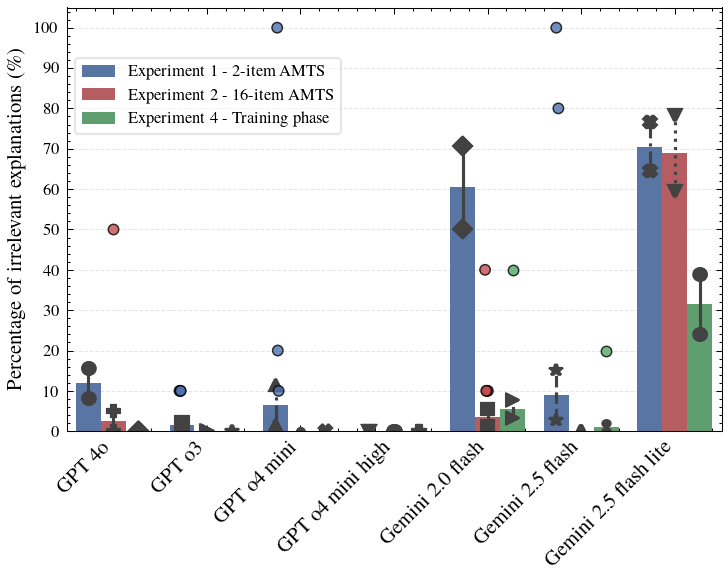

In [17]:
# Helper function to standardize column names across experiments
# Ensuring all dataframes use 'Instance_ID' instead of 'Realization'
def standardize_columns(df):
    df_clean = df.copy()
    if 'Instance' in df_clean.columns:
        df_clean = df_clean.rename(columns={'Instance': 'Instance_ID'})
    # We only keep the columns we actually need to avoid concatenation issues
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Relevance']
    return df_clean[cols_to_keep]

# 1. Prepare and filter dataframes individually
# Experiment 1
df1 = standardize_columns(df_exp1)
df1['Experiment'] = 'Experiment 1'

# Experiment 2 
df2 = standardize_columns(df_exp2) 
df2['Experiment'] = 'Experiment 2'

# Experiment 4
# We must filter by 'Split' == 'train' BEFORE standardizing, 
# because standardize_columns removes the 'Split' column.
df4_raw = df_exp4[df_exp4['Split'] == 'train'].copy()
df4 = standardize_columns(df4_raw)
df4['Experiment'] = 'Experiment 4'

# 2. Combine all dataframes
df_combined = pd.concat([df1, df2, df4], ignore_index=True)

# 3. Calculate Irrelevance
# If Relevance is 1 (relevant) or 0 (irrelevant), we flag the 0s
df_combined['Is_Irrelevant'] = (df_combined['Relevance'] == 0).astype(int)

# 4. Group by instance to get the percentage of irrelevant answers per instance
df_inst = df_combined.groupby(['Experiment', 'Model', 'Set', 'Instance_ID'])['Is_Irrelevant'].mean().reset_index()

# Convert proportion to percentage (0 to 100)
df_inst['Irrelevant_Pct'] = df_inst['Is_Irrelevant'] * 100

# Apply formatting to model names
# (Assuming format_model_name is already defined in your environment)
df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- CALCULATE OUTLIERS EXPLICITLY ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

df_inst['Is_Outlier'] = df_inst.groupby(['Experiment', 'Model'])['Irrelevant_Pct'].transform(check_outliers)
df_outliers = df_inst[df_inst['Is_Outlier']].copy()

model_order = df_inst['Model'].unique().tolist()
experiment_order = ['Experiment 1', 'Experiment 2', 'Experiment 4']
# -------------------------------------

# --- NUMERICAL SUMMARY ---
summary_rel = df_inst.groupby(['Experiment', 'Model'])['Irrelevant_Pct'].agg(['mean', sem]).reset_index()
summary_rel.rename(columns={'mean': 'Mean Irrelevance (%)', 'sem': 'Standard Error (%)'}, inplace=True)

print("--- PERCENTAGE OF IRRELEVANT EXPLANATIONS ---")
print(summary_rel.round(2).to_string(index=False))
print("\n")

# --- PLOTTING ---

# --- PLOTTING (BARPLOT WITH ERROR BARS AND RAW DATA) ---

# --- PLOTTING (BARPLOT WITH ERROR BARS AND ONLY OUTLIERS) ---

# 5. Configure the figure and style 
plt.figure(figsize=(5, 4))

# 6. Create the Barplot
# errorbar='se' plots the Standard Error of the Mean (SEM)
ax = sns.barplot(
    data=df_inst,
    x='Model',
    y='Irrelevant_Pct',
    hue='Experiment',
    palette=['#4C72B0', '#C44E52', '#55A868'], 
    order=model_order,
    hue_order=experiment_order,
    errorbar='se',    # Standard Error
    capsize=0.05,     # The horizontal caps on the error bars
    err_kws={'linewidth': 1.5}, # Thickness of the error line
    #alpha=0.9         # Almost solid bars
)

# 7. Overlay ONLY the true outliers
# We pass df_outliers here instead of df_inst
sns.stripplot(
    data=df_outliers,
    x='Model',
    y='Irrelevant_Pct',
    hue='Experiment',
    palette=['#4C72B0', '#C44E52', '#55A868'],
    order=model_order,
    hue_order=experiment_order,
    dodge=True,       # Aligns the dots with their corresponding bars
    jitter=True,      # Spreads them slightly so they don't overlap completely
    size=5,           # Noticeable point size
    linewidth=0.7,    # Black border for contrast
    edgecolor='black',
    alpha=0.8,
    ax=ax
)

# 8. Chart Customization
plt.ylim(0, 105)
plt.yticks(range(0, 101, 10))

# Rotate X labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
# Keep only the first 3 items (the bars) to avoid stripplot duplicates
handles = handles[:3] 
labels = labels[:3]
labels[0] = "Experiment 1 - 2-item AMTS" 
labels[1] = "Experiment 2 - 16-item AMTS" 
labels[2] = "Experiment 4 - Training phase" 
plt.legend(handles=handles, labels=labels, title='', fontsize=8, framealpha=.5, loc='upper left', bbox_to_anchor=(0, 0.9))

# Labels and title
plt.xlabel("")
plt.ylabel(r"Percentage of irrelevant explanations (\%)", fontsize=10)

plt.tight_layout()
plt.savefig('irrelevant_explanations_barplot_clean.pdf', bbox_inches='tight')
plt.show()

### Same and different

--- PERCENTAGE OF CONCEPTUAL ACCURACY (RELEVANT EXPLANATIONS ONLY) ---
  Experiment                 Model  Mean Conceptual Accuracy (%)  Standard Error (%)
Experiment 1                GPT 4o                         90.56                3.41
Experiment 1                GPT o3                        100.00                0.00
Experiment 1           GPT o4 mini                         98.95                0.72
Experiment 1      GPT o4 mini high                         95.50                2.56
Experiment 1      Gemini 2.0 flash                         85.00               10.25
Experiment 1      Gemini 2.5 flash                        100.00                0.00
Experiment 1 Gemini 2.5 flash lite                         65.42               11.61
Experiment 2                GPT 4o                         95.00                5.00
Experiment 2                GPT o3                         98.00                1.17
Experiment 2           GPT o4 mini                         98.50               

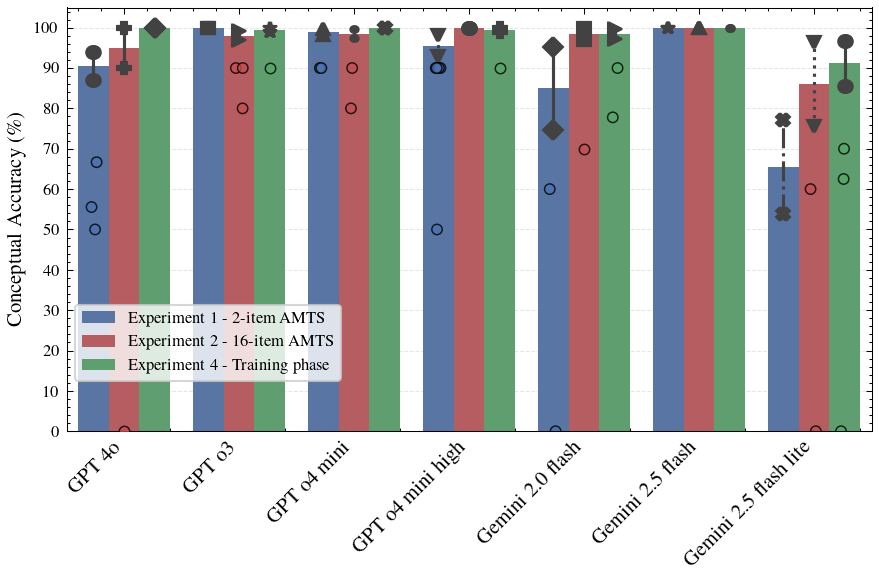

In [80]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem

# --- 1. DICCIONARIOS Y EXPRESIONES REGULARES ---
same_keywords = ['same', 'identical', 'similar', 'uniform', 'repeat', 'repeated', 'repeating', 'repetitive', 'all same', 'matching', 'match', 'twice', 'shared', 'single icon', 'single symbol']
diff_keywords = ['different', 'distinct', 'varied', 'varied-icon', 'diverse', 'mix', 'mixture', 'variety', 'various', 'all different', 'unique', 'types', 'mixed-icon', 'unrelated', 'individual']
negation_keywords = ['not', 'no', "n't", 'none', 'without', 'rather than', 'instead of', 'non-repeating', 'not repeated']
ignore_phrases = ['similar to card', 'like card', 'like those on card', 'like sample', 'as card', 'just like card', 'matching card', 'with card', 'same as card', 'identical to card', 'pattern of card', 'fitting the description of card', 'matching the varied pattern of', 'matching the uniform pattern of', 'matching the repetitive pattern of', "matching card a's", "matching card b's", 'variety pattern', 'varied-icon pattern', 'mixed-icon pattern']

# Compilamos los patrones (El patrón ignore elimina la frase y cualquier mención a la carta A o B que le siga)
ignore_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, ignore_phrases)) + r')\b.*?(?:a|b|"a"|"b"|\'a\'|\'b\')?', re.IGNORECASE)
same_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, same_keywords)) + r')\b', re.IGNORECASE)
diff_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, diff_keywords)) + r')\b', re.IGNORECASE)
neg_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, negation_keywords)) + r')\b', re.IGNORECASE)

def evaluar_precision_conceptual(row):
    texto = str(row['Explanation'])
    verdad_visual = str(row['Decision']).strip().lower() 
    experimento = str(row['Experiment']) # Capturamos de qué experimento viene
    
    # PARCHE: Invertir la verdad visual SOLO para el Experimento 2
    if 'Experiment 2' in experimento:
        if 'same' in verdad_visual:
            verdad_visual = 'all different'
        elif 'different' in verdad_visual or 'diff' in verdad_visual:
            verdad_visual = 'all same'

    # 1. Recortar frases de comparación irrelevantes
    clean_text = ignore_pattern.sub('', texto)
    
    # 2. Buscar presencia de conceptos
    has_same = bool(same_pattern.search(clean_text))
    has_diff = bool(diff_pattern.search(clean_text))
    has_neg = bool(neg_pattern.search(clean_text))
    
    # 3. Lógica permisiva basada en lenguaje natural real
    if has_same and has_diff:
        return 1
        
    if 'same' in verdad_visual:
        if has_same and not has_neg: return 1
        if has_diff and has_neg: return 1
        return 0
        
    elif 'different' in verdad_visual or 'diff' in verdad_visual:
        if has_diff and not has_neg: return 1
        if has_same and has_neg: return 1
        return 0
        
    return np.nan

# --- 2. PREPARACIÓN Y FILTRADO DE DATAFRAMES ---
def standardize_columns_concept(df):
    df_clean = df.copy()
    if 'Instance' in df_clean.columns:
        df_clean = df_clean.rename(columns={'Instance': 'Instance_ID'})
    # Ahora traemos también Explanation y Decision (o Ground Truth)
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Relevance', 'Explanation', 'Decision']
    cols_to_keep = [c for c in cols_to_keep if c in df_clean.columns]
    return df_clean[cols_to_keep]

df1 = standardize_columns_concept(df_exp1)
df1['Experiment'] = 'Experiment 1'

df2 = standardize_columns_concept(df_exp2) 
df2['Experiment'] = 'Experiment 2'

df4_raw = df_exp4[df_exp4['Split'] == 'train'].copy()
df4 = standardize_columns_concept(df4_raw)
df4['Experiment'] = 'Experiment 4'

df_combined = pd.concat([df1, df2, df4], ignore_index=True)

# --- 3. CÁLCULO DE PRECISIÓN CONCEPTUAL (SOLO EN RELEVANTES) ---
df_relevantes = df_combined[df_combined['Relevance'] == 1].copy()

# Aplicar la función lingüística
df_relevantes['Is_Concept_Correct'] = df_relevantes.apply(evaluar_precision_conceptual, axis=1)
df_relevantes = df_relevantes.dropna(subset=['Is_Concept_Correct']) # Limpiar posibles nulos

# Agrupar por instancia
df_inst = df_relevantes.groupby(['Experiment', 'Model', 'Set', 'Instance_ID'])['Is_Concept_Correct'].mean().reset_index()

# Convertir proporción a porcentaje (0 a 100)
df_inst['Accuracy_Pct'] = df_inst['Is_Concept_Correct'] * 100

# Aplicar formato a nombres de modelos (asumiendo función format_model_name previa)
if 'format_model_name' in globals():
    df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- 4. CÁLCULO DE OUTLIERS ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

df_inst['Is_Outlier'] = df_inst.groupby(['Experiment', 'Model'])['Accuracy_Pct'].transform(check_outliers)
df_outliers = df_inst[df_inst['Is_Outlier']].copy()

model_order = df_inst['Model'].unique().tolist()
experiment_order = ['Experiment 1', 'Experiment 2', 'Experiment 4']

# --- 5. RESUMEN NUMÉRICO ---
summary_acc = df_inst.groupby(['Experiment', 'Model'])['Accuracy_Pct'].agg(['mean', sem]).reset_index()
summary_acc.rename(columns={'mean': 'Mean Conceptual Accuracy (%)', 'sem': 'Standard Error (%)'}, inplace=True)

print("--- PERCENTAGE OF CONCEPTUAL ACCURACY (RELEVANT EXPLANATIONS ONLY) ---")
print(summary_acc.round(2).to_string(index=False))
print("\n")

# --- 6. VISUALIZACIÓN (BARPLOT CON OUTLIERS) ---
plt.figure(figsize=(6, 4))

# Barplot principal
ax = sns.barplot(
    data=df_inst,
    x='Model',
    y='Accuracy_Pct',
    hue='Experiment',
    palette=['#4C72B0', '#C44E52', '#55A868'], 
    order=model_order,
    hue_order=experiment_order,
    errorbar='se',    
    capsize=0.05,     
    err_kws={'linewidth': 1.5}
)

# Superponer los outliers reales
sns.stripplot(
    data=df_outliers,
    x='Model',
    y='Accuracy_Pct',
    hue='Experiment',
    palette=['#4C72B0', '#C44E52', '#55A868'],
    order=model_order,
    hue_order=experiment_order,
    dodge=True,       
    jitter=True,      
    size=5,           
    linewidth=0.7,    
    edgecolor='black',
    alpha=0.8,
    ax=ax
)

# Ajustes de diseño de la gráfica
plt.ylim(0, 105)
plt.yticks(range(0, 101, 10))
plt.xticks(rotation=45, ha='right', fontsize=10)

# Limpiar leyenda duplicada del stripplot
handles, labels = ax.get_legend_handles_labels()
handles = handles[:3] 
labels = labels[:3]
labels[0] = "Experiment 1 - 2-item AMTS" 
labels[1] = "Experiment 2 - 16-item AMTS" 
labels[2] = "Experiment 4 - Training phase" 
plt.legend(handles=handles, labels=labels, title='', fontsize=8, framealpha=.8, loc='lower left', bbox_to_anchor=(0, 0.1))

# Etiquetas
plt.xlabel("")
plt.ylabel(r"Conceptual Accuracy (\%)", fontsize=10)

plt.tight_layout()
#plt.savefig('conceptual_accuracy_barplot.pdf', bbox_inches='tight')
plt.show()

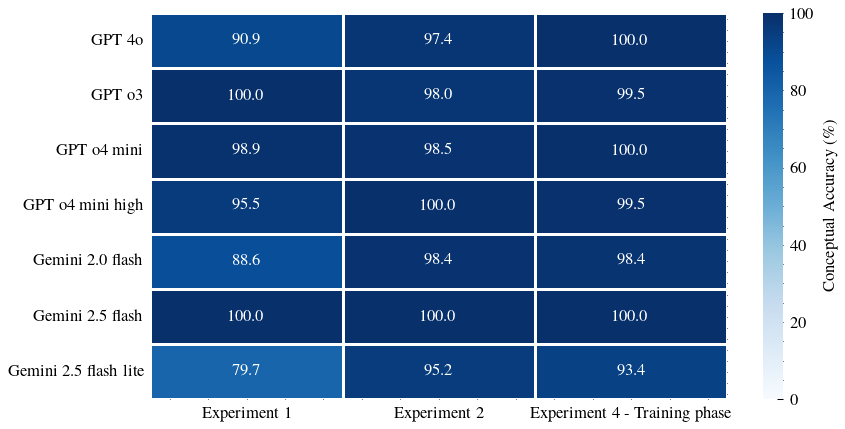

In [91]:
# --- 1. DICCIONARIOS Y EXPRESIONES REGULARES ---
same_keywords = ['same', 'identical', 'similar', 'uniform', 'repeat', 'repeated', 'repeating', 'repetitive', 'all same', 'matching', 'match', 'twice', 'shared', 'single icon', 'single symbol']
diff_keywords = ['different', 'distinct', 'varied', 'varied-icon', 'diverse', 'mix', 'mixture', 'variety', 'various', 'all different', 'unique', 'types', 'mixed-icon', 'unrelated', 'individual']
negation_keywords = ['not', 'no', "n't", 'none', 'without', 'rather than', 'instead of', 'non-repeating', 'not repeated']
ignore_phrases = ['similar to card', 'like card', 'like those on card', 'like sample', 'as card', 'just like card', 'matching card', 'with card', 'same as card', 'identical to card', 'pattern of card', 'fitting the description of card', 'matching the varied pattern of', 'matching the uniform pattern of', 'matching the repetitive pattern of', "matching card a's", "matching card b's", 'variety pattern', 'varied-icon pattern', 'mixed-icon pattern']

# Compilamos los patrones (El patrón ignore elimina la frase y cualquier mención a la carta A o B que le siga)
ignore_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, ignore_phrases)) + r')\b.*?(?:a|b|"a"|"b"|\'a\'|\'b\')?', re.IGNORECASE)
same_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, same_keywords)) + r')\b', re.IGNORECASE)
diff_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, diff_keywords)) + r')\b', re.IGNORECASE)
neg_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, negation_keywords)) + r')\b', re.IGNORECASE)

def evaluar_precision_conceptual(row):
    texto = str(row['Explanation'])
    verdad_visual = str(row['Decision']).strip().lower() 
    experimento = str(row['Experiment']) # Capturamos de qué experimento viene
    
    # PARCHE: Invertir la verdad visual SOLO para el Experimento 2
    if 'Experiment 2' in experimento:
        if 'same' in verdad_visual:
            verdad_visual = 'all different'
        elif 'different' in verdad_visual or 'diff' in verdad_visual:
            verdad_visual = 'all same'

    # 1. Recortar frases de comparación irrelevantes
    clean_text = ignore_pattern.sub('', texto)
    
    # 2. Buscar presencia de conceptos
    has_same = bool(same_pattern.search(clean_text))
    has_diff = bool(diff_pattern.search(clean_text))
    has_neg = bool(neg_pattern.search(clean_text))
    
    # 3. Lógica permisiva basada en lenguaje natural real
    if has_same and has_diff:
        return 1
        
    if 'same' in verdad_visual:
        if has_same and not has_neg: return 1
        if has_diff and has_neg: return 1
        return 0
        
    elif 'different' in verdad_visual or 'diff' in verdad_visual:
        if has_diff and not has_neg: return 1
        if has_same and has_neg: return 1
        return 0
        
    return np.nan

# --- 2. PREPARACIÓN Y FILTRADO ---
def standardize_columns_concept(df):
    df_clean = df.copy()
    if 'Instance' in df_clean.columns:
        df_clean = df_clean.rename(columns={'Instance': 'Instance_ID'})
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Relevance', 'Explanation', 'Decision']
    cols_to_keep = [c for c in cols_to_keep if c in df_clean.columns]
    return df_clean[cols_to_keep]

df1 = standardize_columns_concept(df_exp1)
df1['Experiment'] = 'Experiment 1'

df2 = standardize_columns_concept(df_exp2) 
df2['Experiment'] = 'Experiment 2'

df4_raw = df_exp4[df_exp4['Split'] == 'train'].copy()
df4 = standardize_columns_concept(df4_raw)
df4['Experiment'] = 'Experiment 4 - Training phase'

df_combined = pd.concat([df1, df2, df4], ignore_index=True)

# --- 3. CÁLCULO DE MÉTRICAS ---
df_relevantes = df_combined[df_combined['Relevance'] == 1].copy()
df_relevantes['Is_Concept_Correct'] = df_relevantes.apply(evaluar_precision_conceptual, axis=1)
df_relevantes = df_relevantes.dropna(subset=['Is_Concept_Correct'])

# Agrupamos por Modelo y Experimento para obtener el promedio directo
df_pivot = df_relevantes.groupby(['Model', 'Experiment'])['Is_Concept_Correct'].mean().reset_index()
df_pivot['Accuracy_Pct'] = df_pivot['Is_Concept_Correct'] * 100

if 'format_model_name' in globals():
    df_pivot['Model'] = df_pivot['Model'].apply(format_model_name)

# Pivotar para el Heatmap: Filas=Modelos, Columnas=Experimentos
heatmap_data = df_pivot.pivot(index='Model', columns='Experiment', values='Accuracy_Pct')

# Asegurar el orden de las columnas
experiment_order = ['Experiment 1', 'Experiment 2', 'Experiment 4 - Training phase']
heatmap_data = heatmap_data.reindex(columns=experiment_order)

# --- 4. VISUALIZACIÓN (HEATMAP) ---
plt.figure(figsize=(6, 3))
cmap = sns.color_palette("Blues", as_cmap=True)

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1f", 
    cmap=cmap, 
    vmin=0, vmax=100,
    linewidths=.5,
    cbar_kws={'label': r'Conceptual Accuracy (\%)'}
)

#plt.title('Conceptual Accuracy in Training and Baseline Experiments', fontsize=12, pad=15)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0) # Los nombres de experimentos son cortos, no hace falta rotarlos mucho
plt.tight_layout()

plt.savefig('conceptual_accuracy_heatmap_1_2_4.pdf', bbox_inches='tight')
plt.show()

## Exp 3 and 4

In [142]:
# --- 1. DATA PREPARATION FUNCTIONS ---

def clean_and_format_data(df, experiment_name, instance_col_name):
    """
    Extracts relevant columns, standardizes the instance ID name, 
    and forces strict numeric types to avoid hidden pandas grouping bugs.
    """
    df_clean = df.copy()
    
    # Rename the specific instance column to a standard 'Instance_ID'
    df_clean = df_clean.rename(columns={instance_col_name: 'Instance_ID'})
    
    # Force numeric types (coercing errors to NaN to drop them if necessary)
    df_clean['Entropy'] = pd.to_numeric(df_clean['Entropy'], errors='coerce')
    df_clean['Relevance'] = pd.to_numeric(df_clean['Relevance'], errors='coerce')
    
    # Keep only the strictly necessary columns
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Entropy', 'Relevance']
    df_clean = df_clean[cols_to_keep]
    
    # Add experiment label
    df_clean['Experiment'] = experiment_name
    
    return df_clean

# --- 2. PROCESS EXPERIMENT 3 AND 4 ---

# Process Experiment 3 (Instance column is 'Instance')
df3 = clean_and_format_data(df_exp3, 'Experiment 3', 'Realization')

# Process Experiment 4 (Instance column is 'Realization', must filter 'test' split first)
df4_raw = df_exp4[df_exp4['Split'] == 'test'].copy()
df4 = clean_and_format_data(df4_raw, 'Experiment 4', 'Instance')

# Combine both cleaned datasets
df_combined = pd.concat([df3, df4], ignore_index=True)

# Drop any rows where Relevance or Entropy became NaN due to formatting issues
df_combined = df_combined.dropna(subset=['Relevance', 'Entropy'])

# --- 3. CALCULATE METRICS ---

# Relevance is 1 (relevant) or 0 (irrelevant). We want the percentage of 0s.
df_combined['Is_Irrelevant'] = (df_combined['Relevance'] == 0).astype(int)

# Map numeric Entropy to ordered categorical labels
entropy_map = {
    0: 'All Same',
    4: '4 Different',
    8: '8 Different',
    12: '12 Different',
    16: 'All Different'
}
df_combined['Entropy_Label'] = df_combined['Entropy'].map(entropy_map)
df_combined['Entropy_Label'] = pd.Categorical(
    df_combined['Entropy_Label'], 
    categories=['All Same', '4 Different', '8 Different', '12 Different', 'All Different'], 
    ordered=True
)

# --- 4. AGGREGATE BY INSTANCE ---
# This is the core logic: Calculate the mean irrelevance PER INSTANCE.
# Since an instance is 10 consecutive trials, this gives us the % of failed explanations for that specific run.
df_inst = df_combined.groupby(['Experiment', 'Model', 'Instance_ID', 'Entropy_Label'])['Is_Irrelevant'].mean().reset_index()

# Convert from 0.0-1.0 to 0-100%
df_inst['Irrelevant_Pct'] = df_inst['Is_Irrelevant'] * 100

# Apply formatting to model names (assuming format_model_name is available)
df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- 5. NUMERICAL SUMMARY (TO VERIFY DATA) ---
summary_rel = df_inst.groupby(['Experiment', 'Model', 'Entropy_Label'])['Irrelevant_Pct'].agg(['mean', sem]).reset_index()
summary_rel.rename(columns={'mean': 'Mean Irrelevance (%)', 'sem': 'Standard Error (%)'}, inplace=True)

print("--- PERCENTAGE OF IRRELEVANT EXPLANATIONS BY ENTROPY (MEAN PER MODEL) ---")
print(summary_rel.round(2).to_string(index=False))
print("\n")

--- PERCENTAGE OF IRRELEVANT EXPLANATIONS BY ENTROPY (MEAN PER MODEL) ---
  Experiment                 Model Entropy_Label  Mean Irrelevance (%)  Standard Error (%)
Experiment 3                GPT 4o      All Same                   5.0                5.00
Experiment 3                GPT 4o   4 Different                  10.0                5.53
Experiment 3                GPT 4o   8 Different                   5.0                5.00
Experiment 3                GPT 4o  12 Different                   2.5                2.50
Experiment 3                GPT 4o All Different                   5.0                5.00
Experiment 3                GPT o3      All Same                   0.0                0.00
Experiment 3                GPT o3   4 Different                   0.0                0.00
Experiment 3                GPT o3   8 Different                   0.0                0.00
Experiment 3                GPT o3  12 Different                   0.0                0.00
Experiment 3    

/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/1960016437.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_inst = df_combined.groupby(['Experiment', 'Model', 'Instance_ID', 'Entropy_Label'])['Is_Irrelevant'].mean().reset_index()
/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/1960016437.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_rel = df_inst.groupby(['Experiment', 'Model', 'Entropy_Label'])['Irrelevant_Pct'].agg(['mean', sem]).reset_index()


/var/folders/41/vskcwr5532bfb2q1wpk9q40h0000gn/T/ipykernel_25391/3130962618.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_inst['Is_Outlier'] = df_inst.groupby(['Experiment', 'Model', 'Entropy_Label'])['Irrelevant_Pct'].transform(check_outliers)


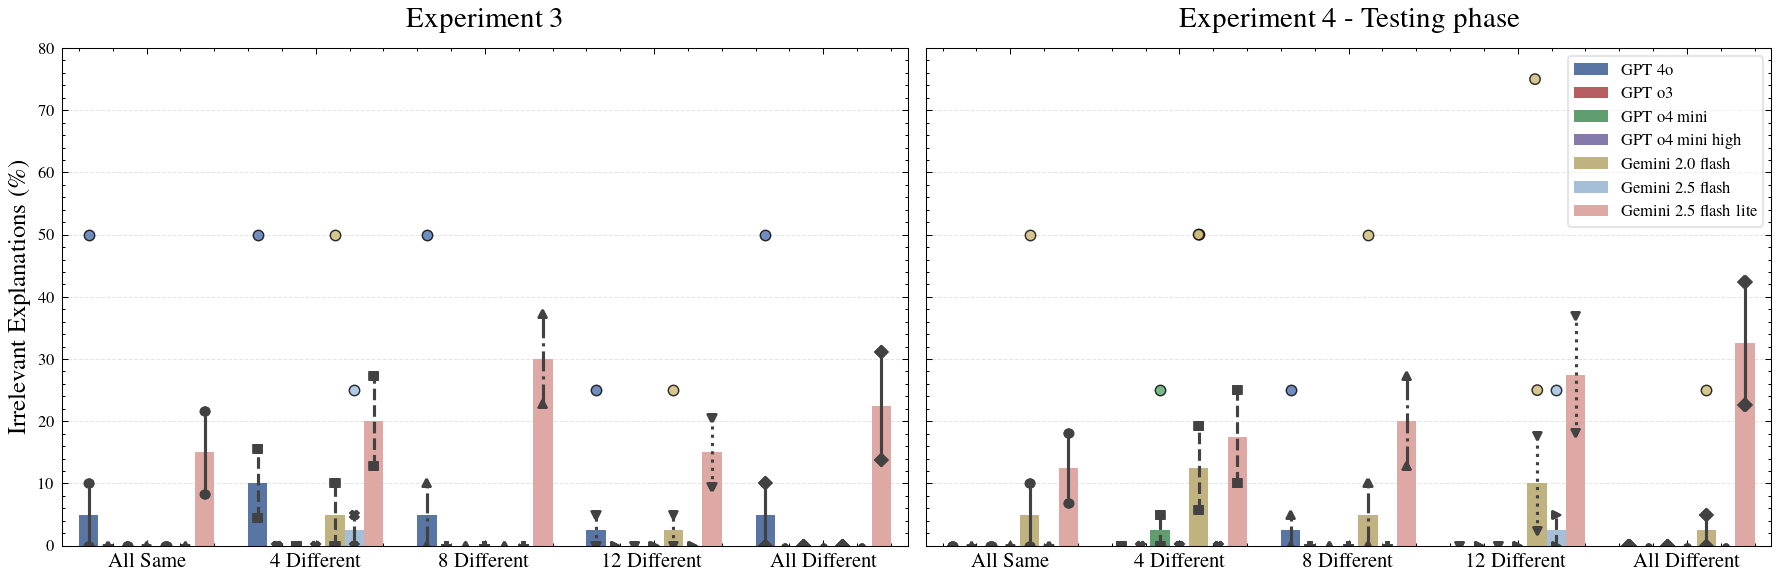

In [147]:
# --- 6. PLOTTING ---
# --- CALCULATE OUTLIERS EXPLICITLY ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    # Lower bound is theoretically below 0 here, but included for completeness
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

# Flag the outliers grouping by Experiment, Model, and Entropy
df_inst['Is_Outlier'] = df_inst.groupby(['Experiment', 'Model', 'Entropy_Label'])['Irrelevant_Pct'].transform(check_outliers)

# Create a separate dataframe containing ONLY the outliers
df_outliers = df_inst[df_inst['Is_Outlier']].copy()
# -------------------------------------

# --- STRICT ORDERING DEFINITIONS ---
# Extract the exact list of models to force Seaborn to keep the layout consistent
model_order = df_inst['Model'].unique().tolist()

# Define the exact X-axis order
entropy_order = ['All Same', '4 Different', '8 Different', '12 Different', 'All Different']
# -----------------------------------

# Set up the figure with 2 subplots (1 row, 2 columns) sharing the Y axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Define academic pastel colors
colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B3', '#CCB974', '#9BBFE0', '#E8A09A']
palette = colors[:len(df_inst['Model'].unique())]

# Dictionary to pass unified styling to both barplots
barplot_kwargs = dict(
    x='Entropy_Label', 
    y='Irrelevant_Pct', 
    hue='Model',
    palette=palette,
    
    # *** CRITICAL FIX FOR COLOR/POSITION ALIGNMENT ***
    order=entropy_order,
    hue_order=model_order,
    # *************************************************
    
    errorbar='se',
    capsize=0.05,
    err_kws={'linewidth': 1.5},
    #alpha=0.9
)

# Plot Panel 1: Experiment 3
sns.barplot(
    data=df_inst[df_inst['Experiment'] == 'Experiment 3'],
    ax=axes[0],
    **barplot_kwargs
)

# Overlay ONLY the colored outliers for Experiment 3
sns.stripplot(
    data=df_outliers[df_outliers['Experiment'] == 'Experiment 3'],
    x='Entropy_Label', 
    y='Irrelevant_Pct', 
    hue='Model',
    palette=palette,
    
    # *** FORCING ALIGNMENT WITH BARPLOT ***
    order=entropy_order,
    hue_order=model_order,
    # **************************************
    
    dodge=True,        
    jitter=True, 
    size=5, 
    linewidth=0.7,    
    edgecolor='black',
    alpha=0.8,
    ax=axes[0]
)

# Plot Panel 2: Experiment 4
sns.barplot(
    data=df_inst[df_inst['Experiment'] == 'Experiment 4'],
    ax=axes[1],
    **barplot_kwargs
)

# Overlay ONLY the colored outliers for Experiment 4
sns.stripplot(
    data=df_outliers[df_outliers['Experiment'] == 'Experiment 4'],
    x='Entropy_Label', 
    y='Irrelevant_Pct', 
    hue='Model',
    palette=palette,
    
    # *** FORCING ALIGNMENT WITH BARPLOT ***
    order=entropy_order,
    hue_order=model_order,
    # **************************************
    
    dodge=True,        
    jitter=True, 
    size=5, 
    linewidth=0.7,    
    edgecolor='black',
    alpha=0.8,
    ax=axes[1]
)

# --- 7. CHART CUSTOMIZATION & ZOOM ---

# Calculate dynamic zoom based on actual data
max_val = df_inst['Irrelevant_Pct'].max()
y_upper_limit = max(10, max_val + 5) 

# Apply limits to the first axis (which propagates to the second due to sharey=True)
# Changed lower limit to 0 since it's a barplot
#axes[0].set_ylim(0, 80) #y_upper_limit)
#axes[0].set_yticks(np.arange(0, y_upper_limit + 1, 10))
axes[0].set_ylim(0, 80)
axes[0].set_yticks(np.arange(0, 81, 10))

# Customize Titles and Labels
axes[0].set_title('Experiment 3', fontsize=14, pad=10)
axes[1].set_title('Experiment 4 - Testing phase', fontsize=14, pad=10)

axes[0].set_ylabel(r"Irrelevant Explanations (\%)", fontsize=12)
axes[1].set_ylabel("") 
axes[0].set_xlabel("")
axes[1].set_xlabel("")

# Rotate X-axis labels
for ax in axes:
    ax.tick_params(axis='x', labelsize=10)#, rotation=45)

# Fix Legend: Remove from first plot, clean duplicates in the second
axes[0].get_legend().remove()
handles, labels = axes[1].get_legend_handles_labels()
num_models = len(df_inst['Model'].unique())
axes[1].legend(handles=handles[:num_models], labels=labels[:num_models], title='', framealpha=0.5, fontsize=8)#, loc='upper left', bbox_to_anchor=(1.02, 1))

#plt.suptitle('Irrelevant Explanations by Visual Disorder (Entropy)\n(Triangles represent the Mean; Horizontal lines represent the Median)', fontsize=13, y=1.08)

plt.tight_layout()
plt.savefig('irrelevant_explanations_exp_3_4.pdf', bbox_inches='tight')
plt.show()

### Same and different

--- PERCENTAGE OF CONCEPTUAL ACCURACY BY ENTROPY (RELEVANT EXPLANATIONS ONLY) ---
  Experiment                 Model Entropy_Label  Mean Accuracy (%)  Standard Error (%)
Experiment 3                GPT 4o      All Same             100.00                0.00
Experiment 3                GPT 4o   4 Different             100.00                0.00
Experiment 3                GPT 4o   8 Different             100.00                0.00
Experiment 3                GPT 4o  12 Different              96.67                3.33
Experiment 3                GPT 4o All Different             100.00                0.00
Experiment 3                GPT o3      All Same             100.00                0.00
Experiment 3                GPT o3   4 Different             100.00                0.00
Experiment 3                GPT o3   8 Different             100.00                0.00
Experiment 3                GPT o3  12 Different             100.00                0.00
Experiment 3                GPT o3 All

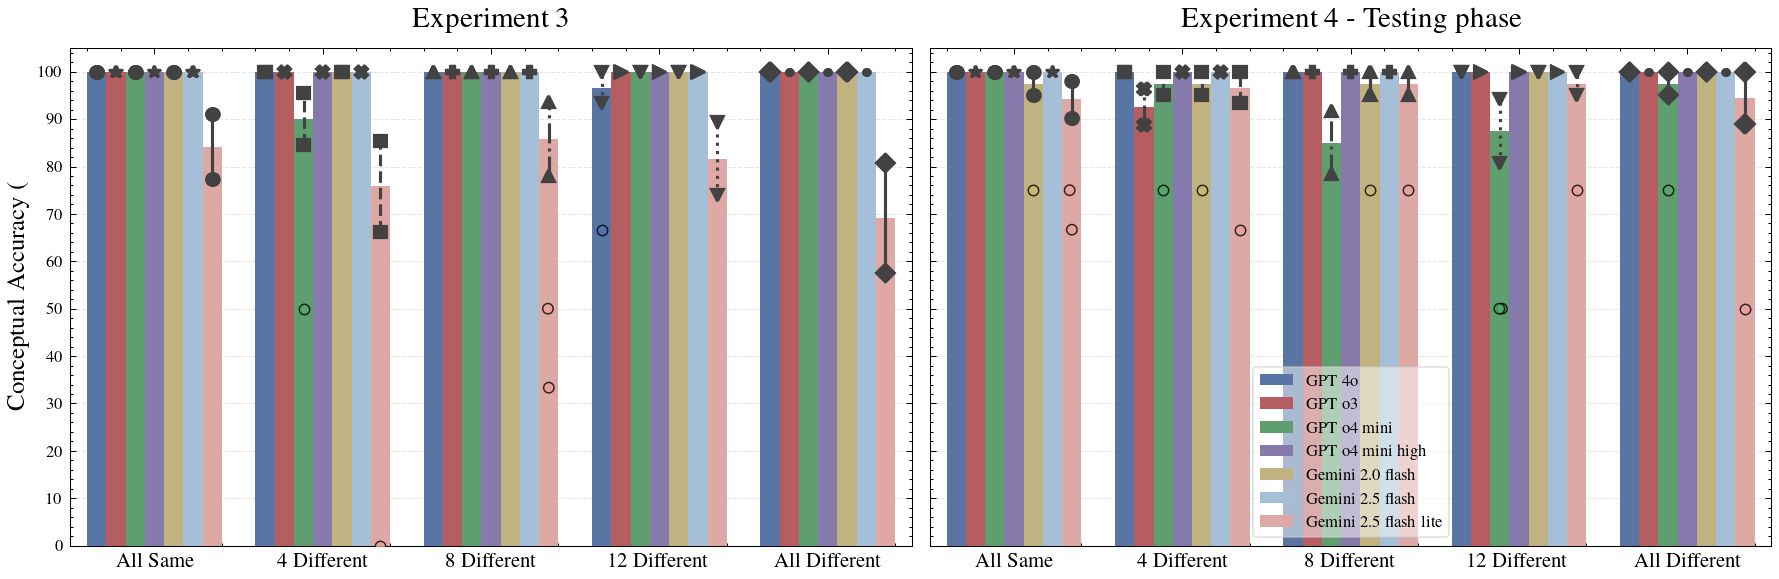

In [46]:
# --- 1. DICCIONARIOS Y EXPRESIONES REGULARES ACTUALIZADOS ---
same_keywords = ['same', 'identical', 'similar', 'uniform', 'repeat', 'repeated', 'repeating', 'repetitive', 'repeats', 'all same', 'matching', 'match', 'twice', 'shared', 'single icon', 'single symbol', 'one icon', 'single element']
diff_keywords = ['different', 'distinct', 'varied', 'varied-icon', 'varied-icons', 'diverse', 'mix', 'mixture', 'variety', 'various', 'all different', 'unique', 'types', 'mixed-icon', 'mixed-icons', 'unrelated', 'individual', 'mixed set', 'mixed']
negation_keywords = ['not', 'no', "n't", 'none', 'without', 'rather than', 'instead of', 'non-repeating', 'not repeated']
ignore_phrases = ['similar to card', 'like card', 'like those on card', 'like sample', 'as card', 'just like card', 'matching card', 'with card', 'same as card', 'identical to card', 'pattern of card', 'fitting the description of card', 'matching the varied pattern of', 'matching the uniform pattern of', 'matching the repetitive pattern of', "matching card a's", "matching card b's", 'variety pattern', 'varied-icon pattern', 'mixed-icon pattern', 'matches card', 'fitting card', 'fitting the varied-icons pattern of', 'fitting the “repeats” pattern of']

# Patrones compilados (Soporte para apóstrofes tipográficos como a’s)
ignore_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, ignore_phrases)) + r')\b.*?(?:a|b|"a"|"b"|\'a\'|\'b\'|“a”|“b”|”a”|”b”|a’s|b’s)?', re.IGNORECASE)
same_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, same_keywords)) + r')\b', re.IGNORECASE)
diff_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, diff_keywords)) + r')\b', re.IGNORECASE)
neg_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, negation_keywords)) + r')\b', re.IGNORECASE)

def evaluar_precision_conceptual(row):
    texto = str(row['Explanation']).lower()
    verdad_visual = str(row['Decision']).strip().lower() 
    
    # Pre-limpieza: Estandarizar guiones largos a normales
    texto = texto.replace('‐', '-').replace('−', '-')
    
    # Cortar cualquier texto comparativo posterior a "whereas card..."
    texto = re.sub(r'whereas card.*', '', texto)
    
    # Recortar frases de asociación directa con las cartas muestra
    clean_text = ignore_pattern.sub('', texto)
    
    has_same = bool(same_pattern.search(clean_text))
    has_diff = bool(diff_pattern.search(clean_text))
    has_neg = bool(neg_pattern.search(clean_text))
    
    # Lógica de coherencia interna
    if has_same and has_diff:
        return 1
        
    if 'same' in verdad_visual:
        if has_same and not has_neg: return 1
        if has_diff and has_neg: return 1
        return 0
    elif 'different' in verdad_visual or 'diff' in verdad_visual:
        if has_diff and not has_neg: return 1
        if has_same and has_neg: return 1
        return 0
        
    return np.nan 

# --- 2. PREPARACIÓN DE DATOS ---
def clean_and_format_concept_data(df, experiment_name, instance_col_name):
    df_clean = df.copy()
    df_clean = df_clean.rename(columns={instance_col_name: 'Instance_ID'})
    
    df_clean['Entropy'] = pd.to_numeric(df_clean['Entropy'], errors='coerce')
    df_clean['Relevance'] = pd.to_numeric(df_clean['Relevance'], errors='coerce')
    
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Entropy', 'Relevance', 'Explanation', 'Decision']
    cols_to_keep = [c for c in cols_to_keep if c in df_clean.columns]
    df_clean = df_clean[cols_to_keep]
    df_clean['Experiment'] = experiment_name
    
    return df_clean

# Asume que tus dataframes originales se llaman df_exp3 y df_exp4
df3 = clean_and_format_concept_data(df_exp3, 'Experiment 3', 'Realization')

df4_raw = df_exp4[df_exp4['Split'] == 'test'].copy()
df4 = clean_and_format_concept_data(df4_raw, 'Experiment 4', 'Instance')

df_combined = pd.concat([df3, df4], ignore_index=True)
df_combined = df_combined.dropna(subset=['Relevance', 'Entropy'])

# --- 3. CÁLCULO DE MÉTRICAS (SOLO RELEVANTES) ---
df_relevantes = df_combined[df_combined['Relevance'] == 1].copy()

# Aplicar análisis léxico
df_relevantes['Is_Concept_Correct'] = df_relevantes.apply(evaluar_precision_conceptual, axis=1)
df_relevantes = df_relevantes.dropna(subset=['Is_Concept_Correct'])

# Mapear entropía
entropy_map = {0: 'All Same', 4: '4 Different', 8: '8 Different', 12: '12 Different', 16: 'All Different'}
df_relevantes['Entropy_Label'] = df_relevantes['Entropy'].map(entropy_map)
df_relevantes['Entropy_Label'] = pd.Categorical(
    df_relevantes['Entropy_Label'], 
    categories=['All Same', '4 Different', '8 Different', '12 Different', 'All Different'], 
    ordered=True
)

# Agrupar por instancia
df_inst = df_relevantes.groupby(['Experiment', 'Model', 'Instance_ID', 'Entropy_Label'])['Is_Concept_Correct'].mean().reset_index()

# Convertir a porcentaje
df_inst['Accuracy_Pct'] = df_inst['Is_Concept_Correct'] * 100

# Aplicar formato a nombres de modelos si existe la función
if 'format_model_name' in globals():
    df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- 4. RESUMEN NUMÉRICO ---
summary_acc = df_inst.groupby(['Experiment', 'Model', 'Entropy_Label'])['Accuracy_Pct'].agg(['mean', sem]).reset_index()
summary_acc.rename(columns={'mean': 'Mean Accuracy (%)', 'sem': 'Standard Error (%)'}, inplace=True)

print("--- PERCENTAGE OF CONCEPTUAL ACCURACY BY ENTROPY (RELEVANT EXPLANATIONS ONLY) ---")
print(summary_acc.round(2).to_string(index=False))
print("\n")

# --- 5. CÁLCULO DE OUTLIERS ---
def check_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return (group > upper_bound) | (group < lower_bound)

df_inst['Is_Outlier'] = df_inst.groupby(['Experiment', 'Model', 'Entropy_Label'])['Accuracy_Pct'].transform(check_outliers)
df_outliers = df_inst[df_inst['Is_Outlier']].copy()

# --- 6. GRAFICACIÓN ---
model_order = df_inst['Model'].unique().tolist()
entropy_order = ['All Same', '4 Different', '8 Different', '12 Different', 'All Different']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Colores ajustados a tu paleta
colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B3', '#CCB974', '#9BBFE0', '#E8A09A']
palette = colors[:len(model_order)]

barplot_kwargs = dict(
    x='Entropy_Label', 
    y='Accuracy_Pct', 
    hue='Model',
    palette=palette,
    order=entropy_order,
    hue_order=model_order,
    errorbar='se',
    capsize=0.05,
    err_kws={'linewidth': 1.5}
)

# Panel 1: Experiment 3
sns.barplot(data=df_inst[df_inst['Experiment'] == 'Experiment 3'], ax=axes[0], **barplot_kwargs)
sns.stripplot(
    data=df_outliers[df_outliers['Experiment'] == 'Experiment 3'],
    x='Entropy_Label', y='Accuracy_Pct', hue='Model', palette=palette,
    order=entropy_order, hue_order=model_order,
    dodge=True, jitter=True, size=5, linewidth=0.7, edgecolor='black', alpha=0.8, ax=axes[0]
)

# Panel 2: Experiment 4
sns.barplot(data=df_inst[df_inst['Experiment'] == 'Experiment 4'], ax=axes[1], **barplot_kwargs)
sns.stripplot(
    data=df_outliers[df_outliers['Experiment'] == 'Experiment 4'],
    x='Entropy_Label', y='Accuracy_Pct', hue='Model', palette=palette,
    order=entropy_order, hue_order=model_order,
    dodge=True, jitter=True, size=5, linewidth=0.7, edgecolor='black', alpha=0.8, ax=axes[1]
)

# Ajustes de diseño
axes[0].set_ylim(0, 105) 
axes[0].set_yticks(np.arange(0, 101, 10))

axes[0].set_title('Experiment 3', fontsize=14, pad=10)
axes[1].set_title('Experiment 4 - Testing phase', fontsize=14, pad=10)

axes[0].set_ylabel(r"Conceptual Accuracy (%)", fontsize=12)
axes[1].set_ylabel("") 
axes[0].set_xlabel("")
axes[1].set_xlabel("")

for ax in axes:
    ax.tick_params(axis='x', labelsize=10)

# Leyenda
axes[0].get_legend().remove()
handles, labels = axes[1].get_legend_handles_labels()
num_models = len(model_order)
axes[1].legend(handles=handles[:num_models], labels=labels[:num_models], title='', framealpha=0.5, fontsize=8)

plt.tight_layout()
#plt.savefig('conceptual_accuracy_exp_3_4.pdf', bbox_inches='tight')
plt.show()

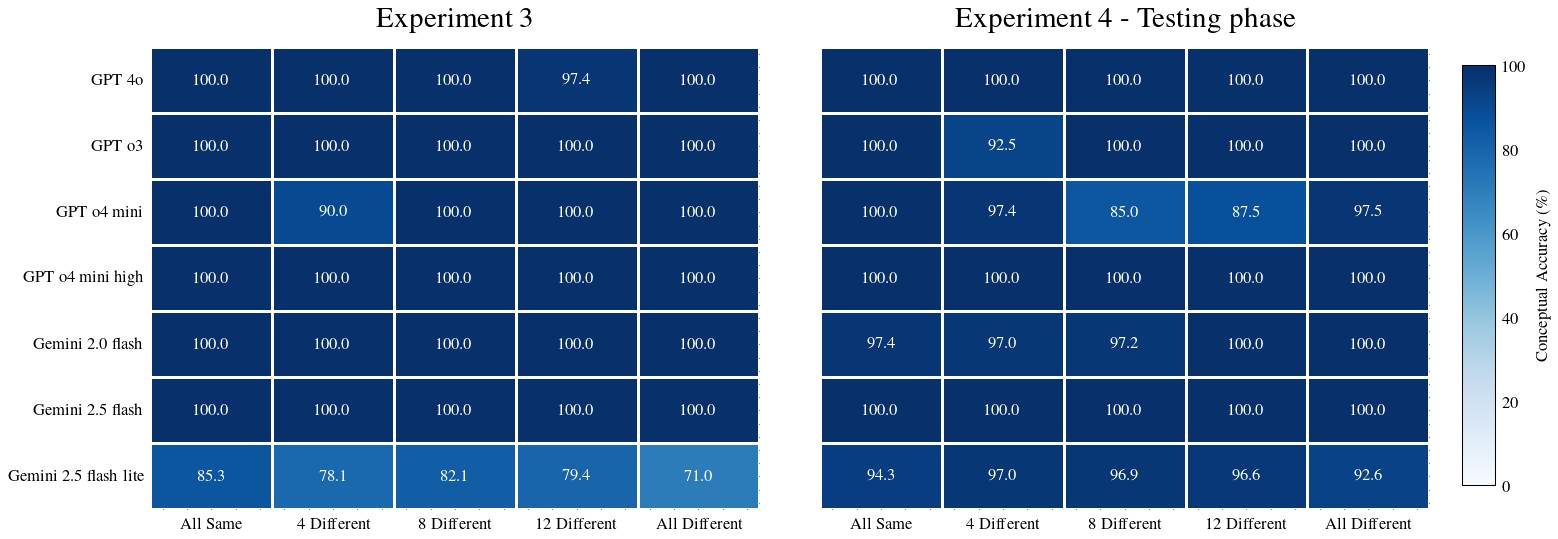

In [55]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DICCIONARIOS Y EXPRESIONES REGULARES ---
same_keywords = ['same', 'identical', 'similar', 'uniform', 'repeat', 'repeated', 'repeating', 'repetitive', 'repeats', 'all same', 'matching', 'match', 'twice', 'shared', 'single icon', 'single symbol', 'one icon', 'single element']
diff_keywords = ['different', 'distinct', 'varied', 'varied-icon', 'varied-icons', 'diverse', 'mix', 'mixture', 'variety', 'various', 'all different', 'unique', 'types', 'mixed-icon', 'mixed-icons', 'unrelated', 'individual', 'mixed set', 'mixed']
negation_keywords = ['not', 'no', "n't", 'none', 'without', 'rather than', 'instead of', 'non-repeating', 'not repeated']
ignore_phrases = ['similar to card', 'like card', 'like those on card', 'like sample', 'as card', 'just like card', 'matching card', 'with card', 'same as card', 'identical to card', 'pattern of card', 'fitting the description of card', 'matching the varied pattern of', 'matching the uniform pattern of', 'matching the repetitive pattern of', "matching card a's", "matching card b's", 'variety pattern', 'varied-icon pattern', 'mixed-icon pattern', 'matches card', 'fitting card', 'fitting the varied-icons pattern of', 'fitting the “repeats” pattern of']

ignore_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, ignore_phrases)) + r')\b.*?(?:a|b|"a"|"b"|\'a\'|\'b\'|“a”|“b”|”a”|”b”|a’s|b’s)?', re.IGNORECASE)
same_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, same_keywords)) + r')\b', re.IGNORECASE)
diff_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, diff_keywords)) + r')\b', re.IGNORECASE)
neg_pattern = re.compile(r'\b(' + '|'.join(map(re.escape, negation_keywords)) + r')\b', re.IGNORECASE)

def evaluar_precision_conceptual(row):
    texto = str(row['Explanation']).lower()
    verdad_visual = str(row['Decision']).strip().lower() 
    
    texto = texto.replace('‐', '-').replace('−', '-')
    texto = re.sub(r'whereas card.*', '', texto)
    clean_text = ignore_pattern.sub('', texto)
    
    has_same = bool(same_pattern.search(clean_text))
    has_diff = bool(diff_pattern.search(clean_text))
    has_neg = bool(neg_pattern.search(clean_text))
    
    if has_same and has_diff:
        return 1
    if 'same' in verdad_visual:
        if has_same and not has_neg: return 1
        if has_diff and has_neg: return 1
        return 0
    elif 'different' in verdad_visual or 'diff' in verdad_visual:
        if has_diff and not has_neg: return 1
        if has_same and has_neg: return 1
        return 0
    return np.nan 

# --- 2. PREPARACIÓN DE DATOS ---
def clean_and_format_concept_data(df, experiment_name, instance_col_name):
    df_clean = df.copy()
    df_clean = df_clean.rename(columns={instance_col_name: 'Instance_ID'})
    df_clean['Entropy'] = pd.to_numeric(df_clean['Entropy'], errors='coerce')
    df_clean['Relevance'] = pd.to_numeric(df_clean['Relevance'], errors='coerce')
    cols_to_keep = ['Model', 'Set', 'Instance_ID', 'Entropy', 'Relevance', 'Explanation', 'Decision']
    cols_to_keep = [c for c in cols_to_keep if c in df_clean.columns]
    df_clean = df_clean[cols_to_keep]
    df_clean['Experiment'] = experiment_name
    return df_clean

# Reemplaza con tus variables reales
df3 = clean_and_format_concept_data(df_exp3, 'Experiment 3', 'Realization')
df4_raw = df_exp4[df_exp4['Split'] == 'test'].copy()
df4 = clean_and_format_concept_data(df4_raw, 'Experiment 4', 'Instance')

df_combined = pd.concat([df3, df4], ignore_index=True)
df_combined = df_combined.dropna(subset=['Relevance', 'Entropy'])

# --- 3. CÁLCULO DE MÉTRICAS ---
df_relevantes = df_combined[df_combined['Relevance'] == 1].copy()
df_relevantes['Is_Concept_Correct'] = df_relevantes.apply(evaluar_precision_conceptual, axis=1)
df_relevantes = df_relevantes.dropna(subset=['Is_Concept_Correct'])

# ETIQUETAS ORIGINALES RESTAURADAS
entropy_map = {0: 'All Same', 4: '4 Different', 8: '8 Different', 12: '12 Different', 16: 'All Different'}
df_relevantes['Entropy_Label'] = df_relevantes['Entropy'].map(entropy_map)
df_relevantes['Entropy_Label'] = pd.Categorical(
    df_relevantes['Entropy_Label'], 
    categories=['All Same', '4 Different', '8 Different', '12 Different', 'All Different'], 
    ordered=True
)

# Promedio general por modelo y entropía
df_heatmap = df_relevantes.groupby(['Experiment', 'Model', 'Entropy_Label'])['Is_Concept_Correct'].mean().reset_index()
df_heatmap['Accuracy_Pct'] = df_heatmap['Is_Concept_Correct'] * 100

if 'format_model_name' in globals():
    df_heatmap['Model'] = df_heatmap['Model'].apply(format_model_name)

# Pivotar datos para Heatmap
pivot_exp3 = df_heatmap[df_heatmap['Experiment'] == 'Experiment 3'].pivot(index='Model', columns='Entropy_Label', values='Accuracy_Pct')
pivot_exp4 = df_heatmap[df_heatmap['Experiment'] == 'Experiment 4'].pivot(index='Model', columns='Entropy_Label', values='Accuracy_Pct')

# Alinear orden de modelos
model_order = df_heatmap['Model'].unique().tolist()
pivot_exp3 = pivot_exp3.reindex(model_order)
pivot_exp4 = pivot_exp4.reindex(model_order)

# --- 4. GRAFICACIÓN DE HEATMAP ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

cmap = sns.color_palette("Blues", as_cmap=True)

heatmap_kwargs = dict(
    cmap=cmap,
    vmin=0, vmax=100,
    annot=True,          
    fmt=".1f",           
    linewidths=.5,       
    cbar=False           
)

sns.heatmap(pivot_exp3, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('Experiment 3', fontsize=14, pad=10)
axes[0].set_ylabel('')
axes[0].set_xlabel('', fontsize=11, labelpad=10)
# Rotación a 45 grados para que los textos largos no se amontonen
axes[0].tick_params(axis='x')#, rotation=45)

sns.heatmap(pivot_exp4, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('Experiment 4 - Testing phase', fontsize=14, pad=10)
axes[1].set_ylabel('')
axes[1].set_xlabel('', fontsize=11, labelpad=10)
axes[1].tick_params(axis='x')#, rotation=45)

# Crear una única barra de color general
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label=r'Conceptual Accuracy (\%)')

plt.subplots_adjust(wspace=0.1, right=0.9)
plt.savefig('conceptual_accuracy_heatmap_exp_3_4.pdf', bbox_inches='tight')
plt.show()

## Performance

In [53]:
# Asumimos que tienes dos dataframes crudos: df_exp1 y df_exp2
# Ambos deben tener las columnas: 'Model', 'Set', 'Instance_ID', 'Result'

# 1. Calcular los scores por instancia para AMBOS experimentos
scores_exp1 = df_exp1.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()
scores_exp2 = df_exp2.groupby(['Model', 'Set', 'Instance_ID'])['Result'].mean().reset_index()

resultados_modelo = []

# 2. Iterar por cada modelo individualmente
modelos_unicos = scores_exp1['Model'].unique()

for modelo in modelos_unicos:
    # Extraemos las ~20 notas del modelo en el Exp 1 y las ~20 en el Exp 2
    notas_m1 = scores_exp1[scores_exp1['Model'] == modelo]['Result'].values
    notas_m2 = scores_exp2[scores_exp2['Model'] == modelo]['Result'].values
    
    # Verificamos que el modelo exista en ambos experimentos
    if len(notas_m1) > 0 and len(notas_m2) > 0:
        media_1 = notas_m1.mean()
        media_2 = notas_m2.mean()
        delta = media_2 - media_1
        
        # 3. Aplicar prueba estadística (Mann-Whitney U)
        # alternative='two-sided' nos permite ver si cambió (ya sea para mejor o para peor)
        stat, p_valor = mannwhitneyu(notas_m1, notas_m2, alternative='two-sided')
        
        resultados_modelo.append({
            'Modelo': modelo,
            'Precisión Exp 1': f"{media_1:.2%}",
            'Precisión Exp 2': f"{media_2:.2%}",
            'Mejora': f"{delta:+.2%}", # El '+' fuerza a mostrar el signo (+ o -)
            'P-value': round(p_valor, 4),
            'Significativo': 'SÍ' if p_valor < 0.05 else 'NO'
        })

# 4. Crear y mostrar la tabla final
df_comparacion_modelos = pd.DataFrame(resultados_modelo)

# Ordenar de los que más mejoraron a los que menos
df_comparacion_modelos = df_comparacion_modelos.sort_values(by='Mejora', ascending=False)

print("--- COMPARACIÓN DE DESEMPEÑO: EXP 1 vs EXP 2 (POR MODELO) ---")
print(df_comparacion_modelos.to_string(index=False))

--- COMPARACIÓN DE DESEMPEÑO: EXP 1 vs EXP 2 (POR MODELO) ---
               Modelo Precisión Exp 1 Precisión Exp 2  Mejora  P-value Significativo
Gemini_2_5_flash_lite          84.00%          39.00% -45.00%   0.0000            SÍ
     Gemini_2_5_flash          96.50%         100.00%  +3.50%   0.1626            NO
          GPT_o4_mini          96.50%          99.50%  +3.00%   0.1573            NO
     GPT_o4_mini_high          97.00%          99.50%  +2.50%   0.0809            NO
     Gemini_2_0_flash          85.00%         100.00% +15.00%   0.0001            SÍ
               GPT_4o          85.50%         100.00% +14.50%   0.0000            SÍ
               GPT_o3         100.00%         100.00%  +0.00%   1.0000            NO


## Reasoning time

--- MEAN REASONING TIME PER QUERY ---
                   Experiment            Model  Mean Time (s)  Standard Error (s)
   Experiment 1 - 2-item AMTS           GPT o3           4.78                0.26
   Experiment 1 - 2-item AMTS      GPT o4 mini           3.19                0.17
   Experiment 1 - 2-item AMTS GPT o4 mini high           3.55                0.15
  Experiment 2 - 16-item AMTS           GPT o3           2.10                0.21
  Experiment 2 - 16-item AMTS      GPT o4 mini           2.89                0.14
  Experiment 2 - 16-item AMTS GPT o4 mini high           3.19                0.20
Experiment 4 - Training phase           GPT o3           2.28                0.15
Experiment 4 - Training phase      GPT o4 mini           2.53                0.13
Experiment 4 - Training phase GPT o4 mini high           2.64                0.08




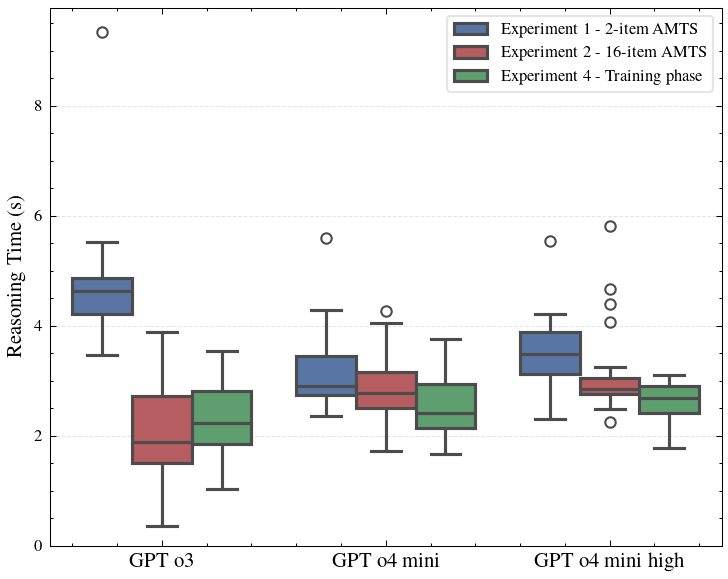

In [37]:
# 1. Combine both experiments into a single DataFrame
df1 = df_exp1.copy()
df1['Experiment'] = 'Experiment 1 - 2-item AMTS'

df2 = df_exp2.copy()
df2['Experiment'] = 'Experiment 2 - 16-item AMTS'

df4 = df_exp4[df_exp4["Split"]=="train"].copy()
df4['Experiment'] = 'Experiment 4 - Training phase'
df4["Instance_ID"] = df4["Instance"]

df_combined = pd.concat([df1, df2, df4], ignore_index=True)

# 2. Filter only the reasoning models
reasoning_models = ['GPT_o3', 'GPT_o4_mini', 'GPT_o4_mini_high']
df_time = df_combined[df_combined['Model'].isin(reasoning_models)].copy()

# 3. Convert reasoning time from milliseconds to seconds
df_time['Reasoning_Time_sec'] = df_time['Razon time'] / 1000

# 4. Calculate mean reasoning time per instance
# Grouping by Model, Set, Instance_ID, and Experiment to get the average time per query
df_inst = df_time.groupby(['Experiment', 'Model', 'Set', 'Instance_ID'])['Reasoning_Time_sec'].mean().reset_index()

# Apply your custom formatting function to the model names
# (Assuming format_model_name is already defined in your environment)
df_inst['Model'] = df_inst['Model'].apply(format_model_name)

# --- NUMERICAL SUMMARY (MEAN AND ERROR) ---
# Calculate the overall mean and standard error for the paper's text
summary_time = df_inst.groupby(['Experiment', 'Model'])['Reasoning_Time_sec'].agg(['mean', sem]).reset_index()
summary_time.rename(columns={'mean': 'Mean Time (s)', 'sem': 'Standard Error (s)'}, inplace=True)

print("--- MEAN REASONING TIME PER QUERY ---")
print(summary_time.round(2).to_string(index=False))
print("\n")

# --- PLOTTING ---

# 5. Configure the figure and style
plt.figure(figsize=(5, 4))
#sns.set_theme(style="whitegrid")

# 6. Create the Boxplot
# x: Models, y: Reasoning Time, hue: Experiment
ax = sns.boxplot(
    data=df_inst,
    x='Model',
    y='Reasoning_Time_sec',
    hue='Experiment',
    palette=['#4C72B0', '#C44E52', '#55A868'], # Academic Blue and Red
    linewidth=1.5,
    fliersize=5 # Size of outlier points
)

# 7. Chart Customization
# We don't set a hard upper limit like 100 here since time can vary greatly, 
# but we force the bottom to start at 0.
plt.ylim(bottom=0)

# Rotate model names if they are too long
plt.xticks(fontsize=10)#rotation=45, ha='right')

# Adjust the legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', loc='upper right', framealpha=.5)

# Clear the X label and set the custom titles
plt.xlabel("")
plt.ylabel("Reasoning Time (s)", fontsize=10)
#plt.title('Reasoning time - 2-item AMTS', fontsize=12)

plt.tight_layout()
plt.savefig('reasoning_time_boxplot_exp_1_2_4.pdf', bbox_inches='tight')
plt.show()